<h2 style="color:#0B5394;">Data Mining Project - Group 42 </h2>

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 1. Customers Dataset
    

    
</div>

<a class="anchor" id="1st-bullet">

## Importing, Exploring and Pre-processing   
</a>

<a class="anchor" id="2nd-bullet">

### 1.1. Import the needed libraries    
</a>

In [295]:
# Importing the needed libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil
from sklearn.preprocessing import MinMaxScaler

<a class="anchor" id="3rd-bullet">

### 1.2. Import the dataset
    
</a>

In [296]:
customers = pd.read_csv('DM_AIAI_CustomerDB.csv')

<a class="anchor" id="3rd-bullet">

### 1.3. Exploratory Data Analysis 
    
</a>

In this section, we will explore the structure, quality, and distribution of the data in the ***customers dataset***.

We will use descriptive statistics and visualizations to better understand patterns and potential relationships between variables.

In [297]:
pd.set_option('display.max_columns', None)
customers.head() 

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [298]:
customers.shape

(16921, 21)

The costumers dataset consists of 16921 observations and 21 variables.

In [299]:
origianl_customers_len =  len (customers)

Created a variable with the original lenght that will be later used for statistics

In [300]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [301]:
# Checking the type and non-null values (not missing values) of each variable
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

- Here, besides checking the type of each variable, we can already check how many missing values each variable has.
- The only variables who seem to have ***missing values*** are "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's) - We will treat this missing values later

In [302]:
# Checking only the type of each variable
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object


- We can already conclude that the variables "EnrollmentDateOpening" and "CancellationDate" should be ***datetime***, so we are going to need to convert them later.

In [303]:
customers.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,4884.775439,0.0,4210.0,8440.0,12670.0,16900.0
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Stacey,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Ypina,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578


- After this we will check these statistics for specific variables, so it's easier to see, but, from this we can conclude that the variable ***"Unnamed:0" will be dropped*** - This variable has no analytical meaning, it simply represents the row number (index) and doesn’t provide any useful information about customers or their behavior.

In [304]:
# Filtering numeric variables so we can easier see their statistics
# We are only doing this for the variables that are more relevant 
# (it doesn't make sense to do this for the variables "Unnamed" and "Loyalty", for example, and cordinates aren't meaningful for this analysis )

customers[['Income', 'Customer Lifetime Value', 'Latitude', 'Longitude']].describe()

,Income,Customer Lifetime Value,Latitude,Longitude
count,16901.000000,16901.000000,16921.000000,16921.000000
mean,37758.038400,7990.460188,47.174500,-91.814768
std,30368.992499,6863.173093,3.307971,22.242429
min,0.000000,1898.010000,42.984924,-135.056840
25%,0.000000,3979.720000,44.231171,-120.237660
50%,34161.000000,5780.180000,46.087818,-79.383186
75%,62396.000000,8945.690000,49.282730,-74.596184
max,99981.000000,83325.380000,60.721188,-52.712578


The table shows basic statistics for Income, Customer Lifetime Value, Latitude, and Longitude.

- Income: The average income is around 37,758, but 25% of the values are 0, which probably means missing data. There are also some very high values, so it may contain outliers and a right-skewed distribution.

- Customer Lifetime Value: The values range from about 1,900 to 83,000. This large range shows some outliers, but overall the data looks reasonable.

- Latitude and Longitude: All values are within the limits of Canada, so these variables seem correct.

In [305]:
# Basic statistics for categorical variabels

customers.describe(include="object")

,First Name,Last Name,Customer Name,Country,Province or State,City,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,EnrollmentType
count,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,16921,2310,16921
unique,4941,15404,16921,1,11,29,75,2,5,3,3,3,2449,1260,2
top,Stacey,Ypina,Emma Martin,Canada,Ontario,Toronto,V6E 3D9,female,Bachelor,Suburban,Married,Star,4/3/2015,7/7/2020,Standard
freq,13,4,1,16921,5468,3390,917,8497,10586,5716,9842,7761,34,8,15773


- We can already conclude that the variable ***"Country" will be dropped*** (since the customers seem to be all from Canada: unique=1)
- The variables ***"First Name", "Last Name" and "Customer Name" might also be dropped*** (they aren't really relevant since we have the variable "Loyalty#" to identify each customer)

<a class="anchor" id="3rd-bullet">

### 1.3.1. Checking for Missing Values
    
</a>

Here we are only going to check if there are any missing values in the Customers Dataset, we are not going to treat them yet.

In [306]:
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

- As we have checked before (in .info), we only have missing values in the variables "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's).

- "CancellationDate": We know that the total number of rows is 16921. Since the number of missing values in this variable is 14611, we can conclude that ***2310 people left the program.***

In [307]:
# Check if the rows with missing values in "Income" are the same rows with missing values in "Customer Lifetime Value"
missing_values_income = customers['Income'].isna()
missing_values_clv = customers['Customer Lifetime Value'].isna()

# Compare the two boolean masks
(missing_values_income == missing_values_clv).all()


np.True_

Since the output is "True", we can assume that "Income" and "Customer Lifetime Value" have the same missing values.

This might mean that when income information is missing, the company also doesn’t have data to estimate the customer’s lifetime value — suggesting that both variables may come from the same data source or depend on each other.

In [308]:
# Checking the rows where both Income and Customer Lifetime Value are NaN
customers[customers['Income'].isna() & customers['Customer Lifetime Value'].isna()]


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,0,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,1,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,2,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,3,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,4,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,5,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,P6D 6N2,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,6,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,W6H 0Z7,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,7,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,B2F 3E1,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard
16909,8,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.471557,-75.704868,B3A 2R0,female,College,Suburban,NaN,Married,Star,3/2/2020,3/2/2020,NaN,Standard
16910,9,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.690489,-79.436758,B4W 4M6,female,Bachelor,Suburban,NaN,Single,Star,9/14/2018,9/14/2018,NaN,Standard


<a class="anchor" id="3rd-bullet">

### 1.3.2. Checking for Duplicated Values
    
</a>

In [309]:
customers.duplicated().sum()

np.int64(0)

- We can conclude that in the Customers Dataset there aren't any rows that are duplicated.

- But, even though we don't have rows that are completly equal to other rows, we might still have some duplication errors.

- Since Loyalty# should be a unique customer identifier it is important to check if the ***same Loyalty# appears with different customer names.***


In [310]:
# Checking for duplicated Loyalty# with different names
duplicates = customers.groupby('Loyalty#')['Customer Name'].nunique()
duplicates[duplicates > 1]


Loyalty#
101902    2
106001    2
106509    2
112142    2
114414    2
         ..
981508    2
988392    2
989528    2
990512    2
992168    2
Name: Customer Name, Length: 163, dtype: int64

Before deciding whether to remove the duplicated Loyalty# values, we need to check if the duplicated rows are exactly the same or if they have different information.
If they only differ by the customer name, they are probably the same customer entered twice.
If other columns (like country, income, or CLV) are also different, they are probably different customers who accidentally received the same Loyalty#.

In [311]:
# Checking if the duplicated #Loyalty refer different customers or not
# If for example rows with same ID have live in different countries, or have different income, etc,
# then we can assume that these are different customers

duplicates_ids = customers[customers.duplicated(subset='Loyalty#', keep=False)]
duplicates_ids.sort_values(['Loyalty#', 'Customer Name']).head(20)


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
1646,1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,1/7/2020,NaN,6265.34,Standard
2668,2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,3/19/2020,NaN,8609.16,Standard
700,700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,1/11/2016,NaN,4914.04,Standard
15988,15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,7/16/2015,NaN,12168.74,Standard
9413,9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,4/25/2020,10/7/2021,16727.77,Standard
13053,13053,106509,Stacy,Schwebke,Stacy Schwebke,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Suburban,0.0,Single,Star,6/12/2021,NaN,4661.98,Standard
3678,3678,112142,Arnold,Cantoran,Arnold Cantoran,Canada,Ontario,Thunder Bay,48.380894,-89.247681,K8T 5M5,male,Bachelor,Urban,83589.0,Single,Aurora,7/26/2018,NaN,16272.74,Standard
9604,9604,112142,Marty,Kijak,Marty Kijak,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,female,College,Suburban,0.0,Married,Nova,2/21/2020,4/22/2021,21578.86,Standard
5253,5253,114414,Kala,Bachor,Kala Bachor,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Rural,0.0,Married,Nova,11/6/2015,NaN,3591.07,Standard
11411,11411,114414,Temple,Resper,Temple Resper,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,High School or Below,Urban,14151.0,Single,Star,12/18/2015,NaN,2617.70,Standard


The results show that all 163 duplicated Loyalty# values have differences in other variables. This means they belong to different customers, not just name duplicates. Since this represents only about 1% of the dataset, and creating new IDs would break the merge with the flights data, we decided to keep only the first record for each Loyalty# and drop the others to maintain consistency.

This shows that the name, gender, income, etc is different for the customers with the same Loyalty#, which means that the error happening error isn't just a copy of the same customer, but it is an error in only the ID (the system gave the same ID to different customers).

**VOLTAR A ISTO MAIS TARDE, NÃO SEI SE É SUPOSTO TRATAR JÁ**

In [312]:
# Removing duplicated Loyalty# entries (keeping only the first occurrence) 
print("Initial dataset shape:", customers.shape)

customers = customers.drop_duplicates(subset='Loyalty#', keep='first')

print("Dataset shape after removing duplicated Loyalty#:", customers.shape)


Initial dataset shape: (16921, 21)
Dataset shape after removing duplicated Loyalty#: (16757, 21)


<a class="anchor" id="3rd-bullet">

### 1.4. Initial Data Preparation
    
</a>

Here, we are only going to ***deal with some of the initial inconsistencies***, like deleting variables that aren't relevant for our analysis (and for the models) and also converting variables to their correct data type.

<a class="anchor" id="3rd-bullet">

### 1.4.1. Deleting variables that aren't relevant
    
</a>

- We decided to drop the variable "Unnamed:0", as we wrote before, because it has no analytical meaning. It only represents the row number and doesn’t provide any useful information about customers or their behavior. Keeping it would only add noise and take up unnecessary space in the dataset.
- We also decided to drop the variables 'First Name', 'Last Name' and 'Customer Name', since we already have a variable that identifies each customer ('#Loyalty').
- Finally, we decided to drop the variable 'Country', because we checked that all the rows in this column are equal, all the customers are from Canada.

In [313]:
customers = customers.drop(['Unnamed: 0', 'First Name', 'Last Name', 'Customer Name', 'Country'], axis=1)


In [314]:
# Shows the dataset after deleting the unrelevant variables
display(customers)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


<a class="anchor" id="3rd-bullet">

### 1.4.2. Converting variables to datetime
    
</a>

In the beginning of the exploratory data analysis we noticed that the variables "EnrollmentDateOpening" and "CancellationDate" were of the type object, and they should be datetime. So we are going to convert them now.

In [315]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'])
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')

In [316]:
# Checking if the type is now correct
customers[['EnrollmentDateOpening', 'CancellationDate']].info()


<class 'pandas.core.frame.DataFrame'>
Index: 16757 entries, 0 to 16920
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   EnrollmentDateOpening  16757 non-null  datetime64[ns]
 1   CancellationDate       2286 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 392.7 KB


<a class="anchor" id="3rd-bullet">

### 1.4.3.Checking for other inconsistencies
    
</a>

<a class="anchor" id="3rd-bullet">

#### Inconsistency of existing cancellation dates before the respective enrollment date
    
</a>

In [317]:
# Filter only rows where a cancellation date exists
cancelled = customers[customers['CancellationDate'].notna()]

# Find cases where the cancellation date is earlier than the enrollment date
invalid_dates = cancelled[cancelled['CancellationDate'] < cancelled['EnrollmentDateOpening']]

# Count invalid and total cancelled cases
num_invalid = invalid_dates.shape[0]
num_cancelled = cancelled.shape[0]

# Calculate percentage of invalid cancellations among those with a cancellation date
percentage_invalid_cancelled = (num_invalid / num_cancelled) * 100

# Percentagem de casos inválidos sobre o total de registos
percentage_invalid = (num_invalid / origianl_customers_len) * 100

print(f"Number of invalid cancellations: {num_invalid}")
print(f"Total number of customers with a cancellation date: {num_cancelled}")
print(f"Percentage of invalid cancellations among total: {percentage_invalid:.2f}%")
print(f"Percentage of invalid cancellations among cancelled customers: {percentage_invalid_cancelled:.2f}%")

Number of invalid cancellations: 201
Total number of customers with a cancellation date: 2286
Percentage of invalid cancellations among total: 1.19%
Percentage of invalid cancellations among cancelled customers: 8.79%


From a total of 2,286 customers who have a cancellation date, there are 201 cases (about 8.8%) where the cancellation happened before the enrollment date, which is not logically possible.

This means that 8.8% of the cancelled records have invalid dates, likely due to data entry errors or incorrect date formatting.
However, since these represent only 1.2% of all customers in the dataset, the issue is relatively small but still worth correcting or marking as invalid.

We can either:

- Replace these invalid dates with NaN, or

- Exclude them from later analyses involving time-based calculations (like churn duration or lifetime).

<a class="anchor" id="3rd-bullet">

### 1.5. Visual Exploration
    
</a>

In [318]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16757 entries, 0 to 16920
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Loyalty#                 16757 non-null  int64         
 1   Province or State        16757 non-null  object        
 2   City                     16757 non-null  object        
 3   Latitude                 16757 non-null  float64       
 4   Longitude                16757 non-null  float64       
 5   Postal code              16757 non-null  object        
 6   Gender                   16757 non-null  object        
 7   Education                16757 non-null  object        
 8   Location Code            16757 non-null  object        
 9   Income                   16737 non-null  float64       
 10  Marital Status           16757 non-null  object        
 11  LoyaltyStatus            16757 non-null  object        
 12  EnrollmentDateOpening    16757 non-nu

<a class="anchor" id="3rd-bullet">

### 1.5.1. Visualization of Numeric Variables
    
</a>

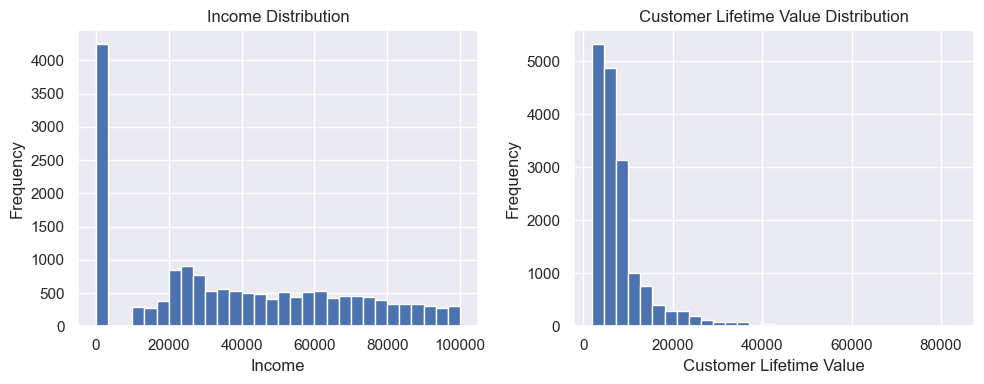

In [319]:
sns.set()

subplot_figsize = (10, 4)

fig, axes = plt.subplots(1, 2, figsize=subplot_figsize)

axes[0].hist(customers['Income'], bins=30)
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

axes[1].hist(customers['Customer Lifetime Value'], bins=30)
axes[1].set_title('Customer Lifetime Value Distribution')
axes[1].set_xlabel('Customer Lifetime Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The histograms show that most customers have low income and a low customer lifetime value, while only a few have very high values. This means the data is not evenly distributed — a small number of customers generate much more value than the rest. This kind of pattern is common in real customer data and shows why it’s important to identify and focus on the most valuable clients.

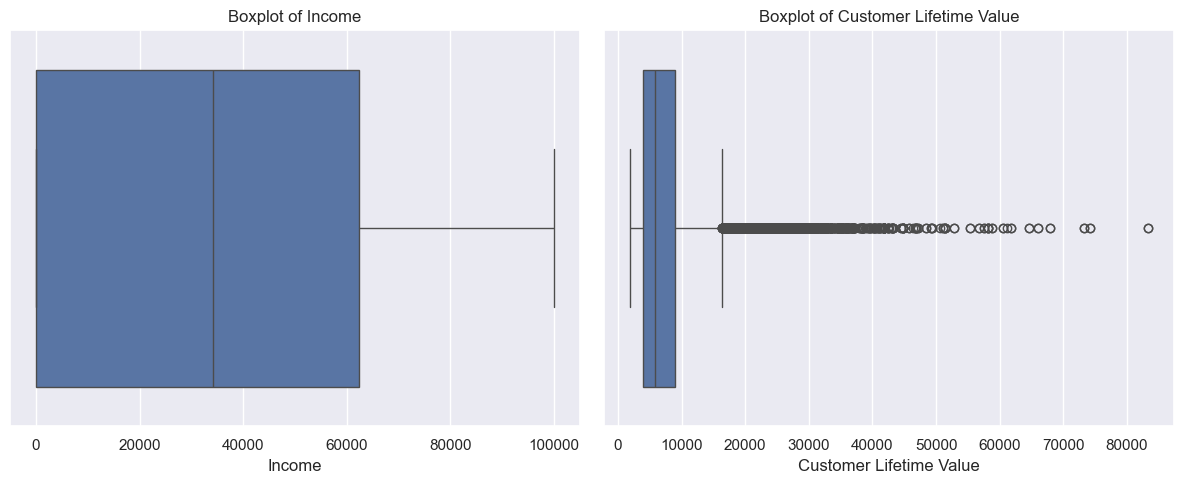

In [320]:
# Comparative boxplots (Income vs Customer Lifetime Value)
sns.set() 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

# Boxplot 1 - Income
sns.boxplot(x=customers["Income"], ax=axes[0])
axes[0].set_title("Boxplot of Income")

# Boxplot 2 - Customer Lifetime Value
sns.boxplot(x=customers["Customer Lifetime Value"], ax=axes[1])
axes[1].set_title("Boxplot of Customer Lifetime Value")

plt.show()


The boxplots show that both Income and Customer Lifetime Value are highly variable and contain several outliers. Most customers have values concentrated in the lower part of the distribution, while a few customers show much higher values. The boxplot of Customer Lifetime Value has a long right tail with many extreme points, confirming the presence of high-value customers identified in the histograms. This indicates that the data is not evenly distributed and that a small group of customers generates disproportionately higher value compared to the majority.

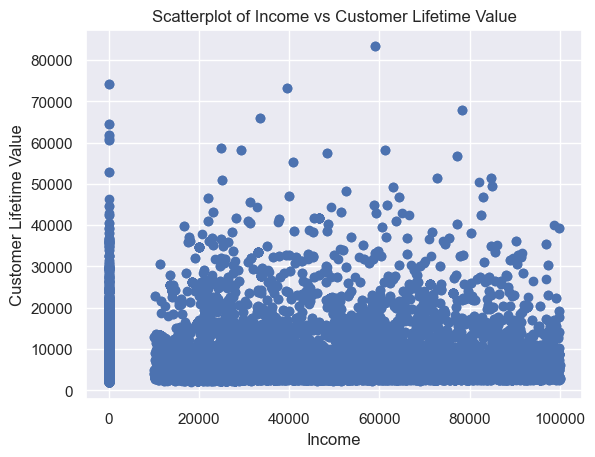

In [321]:
# Scatterplot entre Income e Customer Lifetime Value
plt.scatter(customers["Income"], customers["Customer Lifetime Value"])
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.title("Scatterplot of Income vs Customer Lifetime Value")
plt.show()


The scatterplot shows the relationship between Income and Customer Lifetime Value. Each point represents a customer. The plot reveals no strong linear relationship between the two variables — customers with higher income do not necessarily have a higher lifetime value. Most points are concentrated in the lower ranges of both variables, confirming that the majority of customers have modest income and generate relatively low value for the company. This suggests that other factors beyond income may explain customer value differences.

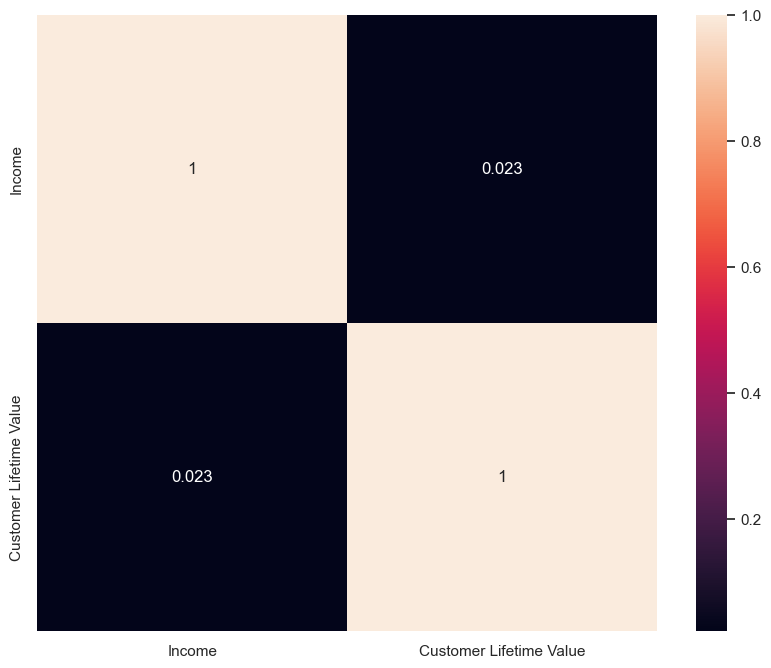

In [322]:
corr = customers[['Income', 'Customer Lifetime Value']].corr(method='pearson')
fig = plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, )
plt.show()

The correlation heatmap shows a very weak positive relationship (0.023) between Income and Customer Lifetime Value. This means that customers with higher income do not necessarily generate a higher lifetime value for the company. The almost zero correlation confirms what was seen in the scatterplot — the two variables are largely independent, suggesting that other factors, such as customer behavior or engagement with the program, play a more important role in determining the overall value of each customer.

<a class="anchor" id="3rd-bullet">

### 1.5.2. Visualization of Categorical Variables
    
</a>

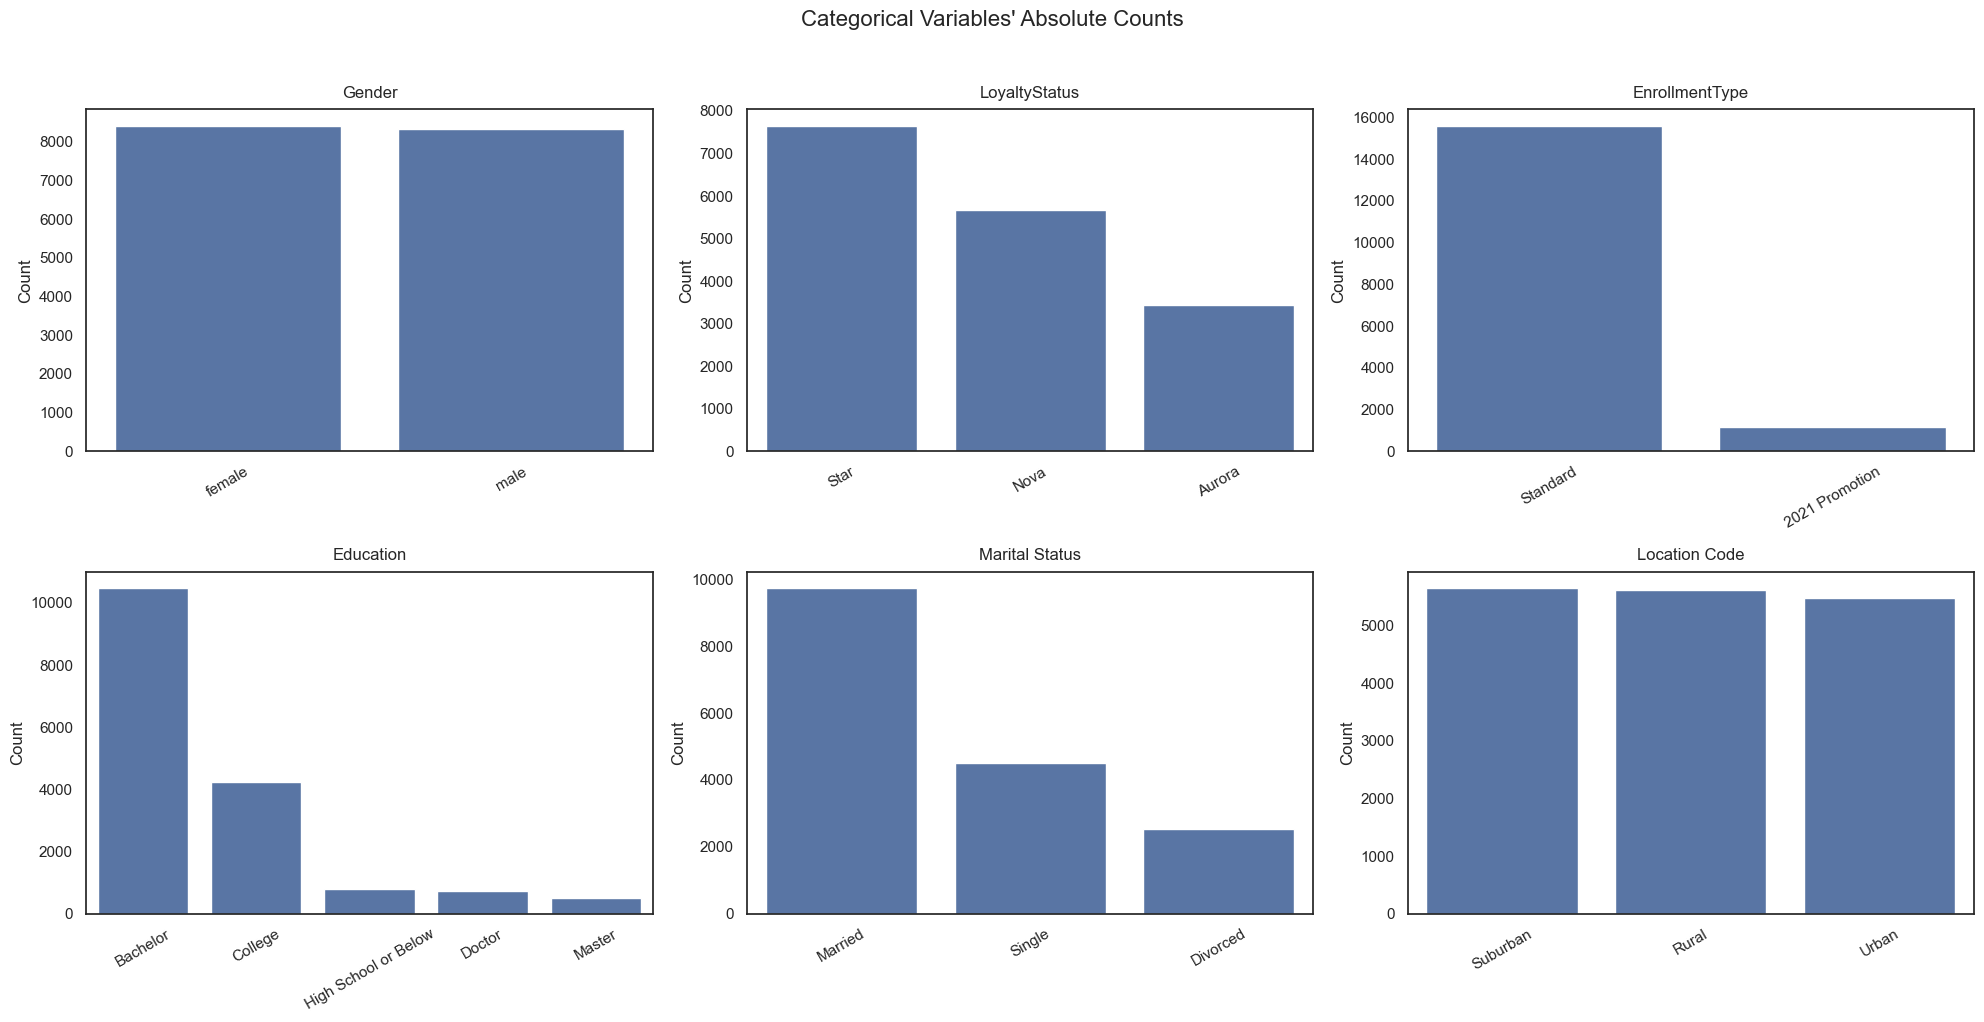

In [323]:
sns.set(style="white")

categorical_features = [
    'Gender',
    'LoyaltyStatus',
    'EnrollmentType',
    'Education',
    'Marital Status',
    'Location Code'
]

fig, axes = plt.subplots(
    2,
    ceil(len(categorical_features) / 2),
    figsize=(20, 10)
)


for ax, feat in zip(axes.flatten(), categorical_features):
    sns.countplot(
        x=customers[feat],
        ax=ax,
        order=customers[feat].value_counts().index,
    )
    ax.set_title(feat, fontsize=12, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)


plt.suptitle("Categorical Variables' Absolute Counts", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()


The bar charts show the distribution of the categorical variables in the dataset. The Gender variable is balanced, with a similar number of male and female customers. Most customers have a loyalty status of “Star” or “Nova”, while fewer belong to the “Aurora” group. In terms of Enrollment Type, the vast majority are part of the “Standard” program, with only a small share enrolled through the “2021 Promotion”.

Regarding Education, most customers hold a bachelor’s degree, followed by college-level education, and very few have a masters degree, only high school or lower or a doctors degree. The Marital Status variable shows that married customers represent the largest group, followed by singles and divorced individuals. Finally, the Location Code distribution is fairly balanced across suburban, rural, and urban areas, suggesting that the customer base is geographically diverse.

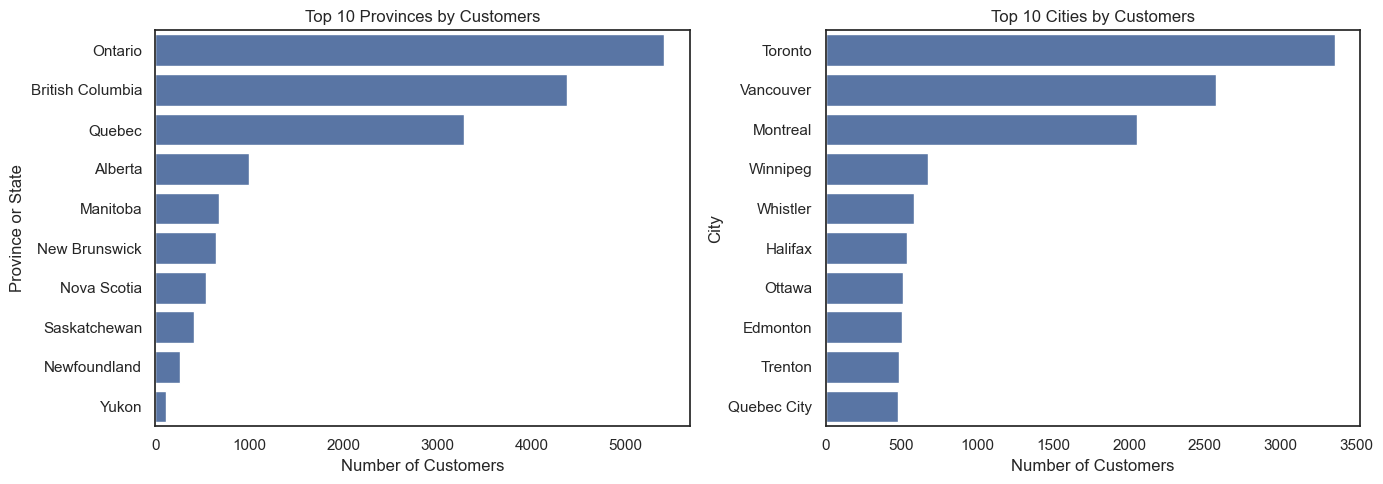

In [324]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Top 10 Provinces
top_prov = customers['Province or State'].value_counts().head(10)
sns.barplot(x=top_prov.values, y=top_prov.index, ax=axes[0])
axes[0].set_title('Top 10 Provinces by Customers')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Province or State')

# Top 10 Cities
top_city = customers['City'].value_counts().head(10)
sns.barplot(x=top_city.values, y=top_city.index, ax=axes[1])
axes[1].set_title('Top 10 Cities by Customers')
axes[1].set_xlabel('Number of Customers')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.show()



The bar charts show that most customers come from Ontario, British Columbia, and Quebec, which are the most populated provinces in Canada.
At the city level, Toronto, Vancouver, and Montreal have the largest number of customers, confirming that the customer base is mostly concentrated in large urban areas.

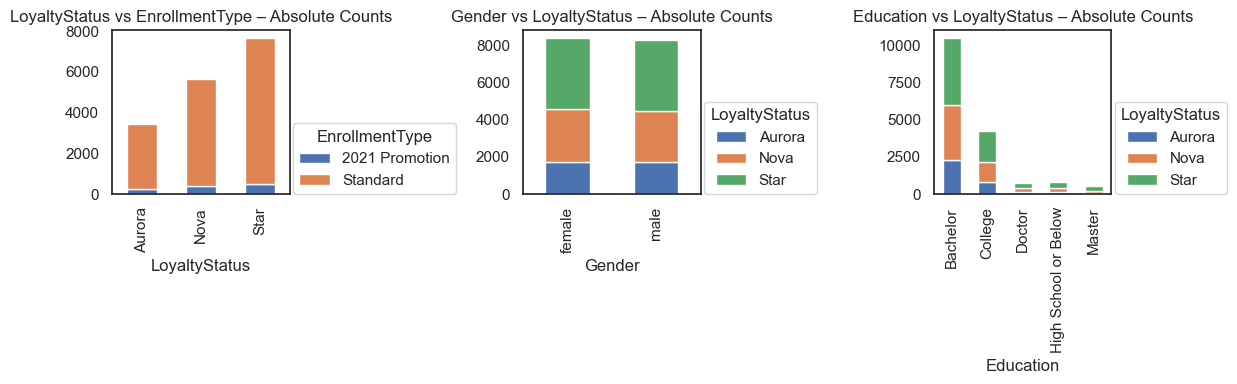

In [325]:
fig, axes = plt.subplots(1,3, figsize=(12,4))

pd.crosstab(customers['LoyaltyStatus'], customers['EnrollmentType']).plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('LoyaltyStatus vs EnrollmentType – Absolute Counts')
axes[0].legend(title='EnrollmentType', loc=(1.02,0))

pd.crosstab(customers['Gender'], customers['LoyaltyStatus']).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Gender vs LoyaltyStatus – Absolute Counts')
axes[1].legend(title='LoyaltyStatus', loc=(1.02,0))

pd.crosstab(customers['Education'], customers['LoyaltyStatus']).plot(kind='bar', stacked=True, ax=axes[2])
axes[2].set_title('Education vs LoyaltyStatus – Absolute Counts')
axes[2].legend(title='LoyaltyStatus', loc=(1.02,0))

plt.tight_layout()
plt.show()

The first chart (Loyalty Status vs Enrollment Type) shows that most customers in each loyalty category belong to the Standard enrollment type, while the 2021 Promotion group represents only a small share. The “Star” segment is the largest and most dominant across enrollment types, followed by “Nova” and then “Aurora.”

The second chart (Gender vs Loyalty Status) indicates that the distribution of loyalty status is very similar for male and female customers. Both genders show comparable proportions of “Star,” “Nova,” and “Aurora” members, suggesting that gender does not play a significant role in determining loyalty level within this dataset.

In the third chart within each education group, the distribution across loyalty statuses (Star, Nova, and Aurora) remains relatively similar, with Star members consistently forming the largest segment. This suggests that education level does not strongly influence customer loyalty status, although customers with higher education tend to be more represented overall in the program.

<a class="anchor" id="3rd-bullet">

### 1.5.3. Visualization of Relationships Between Variables
    
</a>

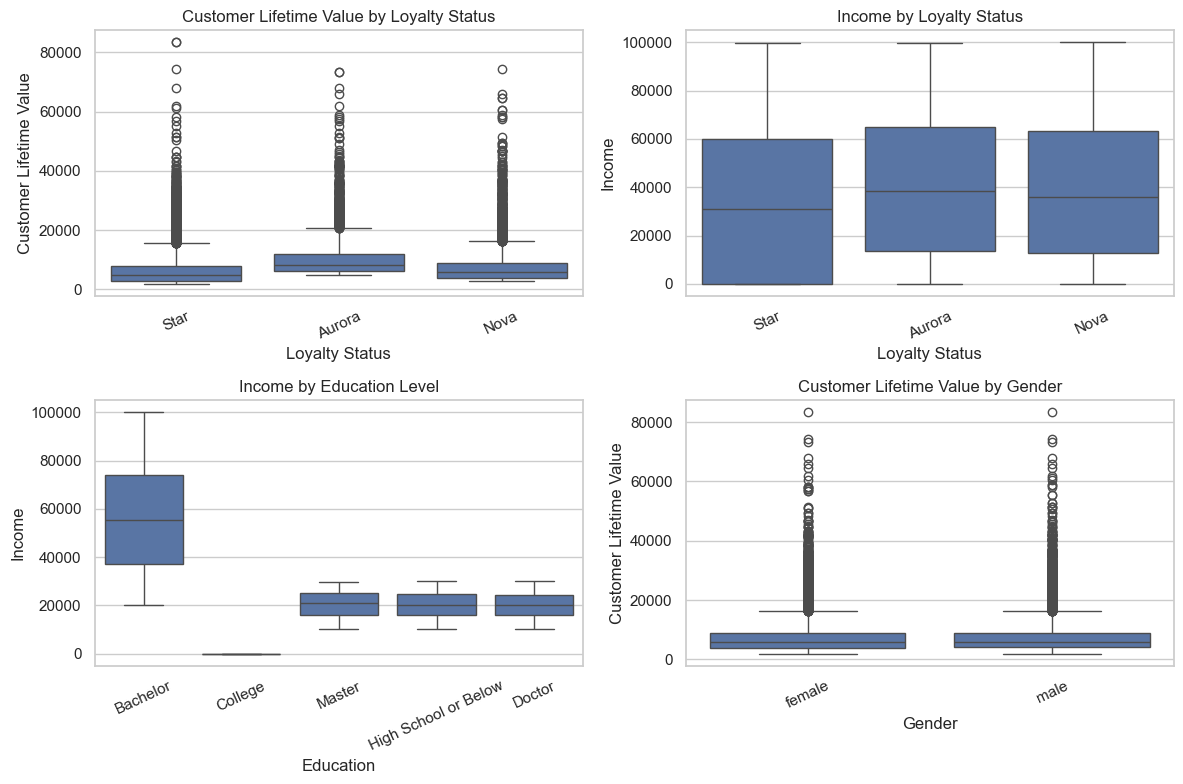

In [326]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#LoyaltyStatus × Customer Lifetime Value
sns.boxplot(
    data=customers,
    x='LoyaltyStatus',
    y='Customer Lifetime Value',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Customer Lifetime Value by Loyalty Status')
axes[0, 0].set_xlabel('Loyalty Status')
axes[0, 0].set_ylabel('Customer Lifetime Value')

#LoyaltyStatus x Income
sns.boxplot(
    data=customers,
    x='LoyaltyStatus',
    y='Income',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Income by Loyalty Status')
axes[0, 1].set_xlabel('Loyalty Status')
axes[0, 1].set_ylabel('Income')

#Education × Income
sns.boxplot(
    data=customers,
    x='Education',
    y='Income',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Income by Education Level')
axes[1, 0].set_xlabel('Education')
axes[1, 0].set_ylabel('Income')

#Gender × Customer Lifetime Value
sns.boxplot(
    data=customers,
    x='Gender',
    y='Customer Lifetime Value',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Customer Lifetime Value by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Customer Lifetime Value')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


The boxplots reveal how Income and Customer Lifetime Value (CLV) vary across different categorical variables.

In the first chart, Customer Lifetime Value by Loyalty Status, customers with a “Star” status tend to have slightly higher lifetime value than “Aurora” or “Nova” members, although there is significant variability and many outliers across all groups.

In Income by Loyalty Status, income levels appear similar among loyalty groups, suggesting that loyalty is not strongly related to customers’ income.

The Income by Education Level plot shows a clearer pattern: customers with a bachelor’s degree have higher and more variable income, while those with lower education levels (such as “High School or Below”) tend to earn less.

Finally, Customer Lifetime Value by Gender indicates no substantial difference between male and female customers — both groups show similar distributions and ranges of lifetime value.

Overall, these plots suggest that while education influences income, gender and loyalty status do not have a strong impact on customer lifetime value.

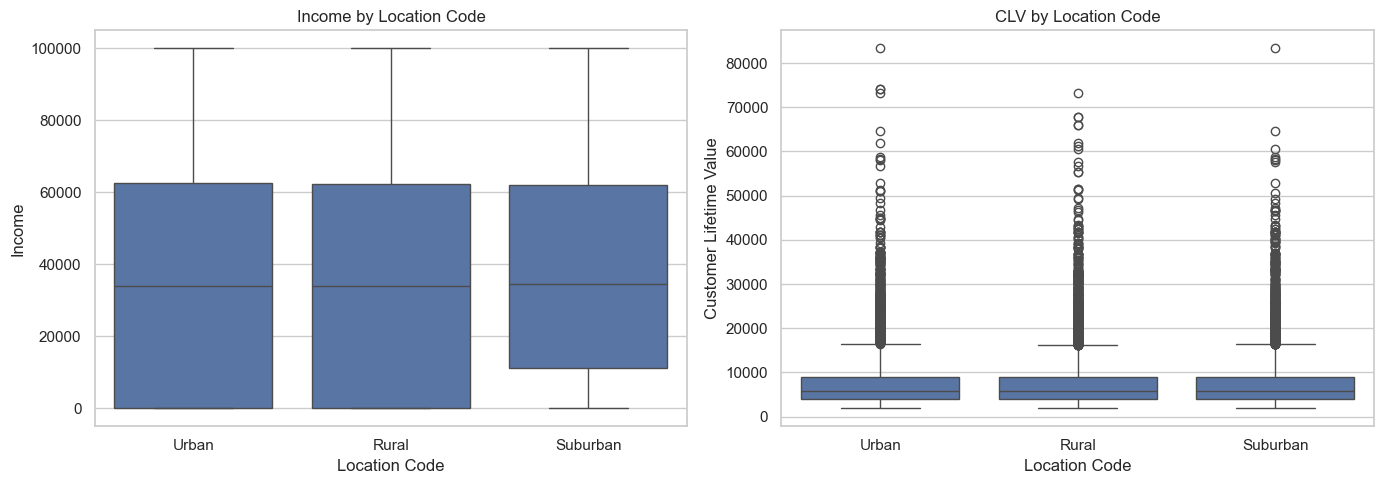

In [327]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=customers, x='Location Code', y='Income', ax=axes[0])
axes[0].set_title('Income by Location Code')
axes[0].set_xlabel('Location Code')
axes[0].set_ylabel('Income')

sns.boxplot(data=customers, x='Location Code', y='Customer Lifetime Value', ax=axes[1])
axes[1].set_title('CLV by Location Code')
axes[1].set_xlabel('Location Code')
axes[1].set_ylabel('Customer Lifetime Value')

plt.tight_layout()
plt.show()


The boxplots show no major differences in income or customer lifetime value among customers living in urban, rural, or suburban areas.
The median values are quite similar, and all three groups have a wide spread of data with many outliers, meaning that income and spending behavior are diverse across all locations.

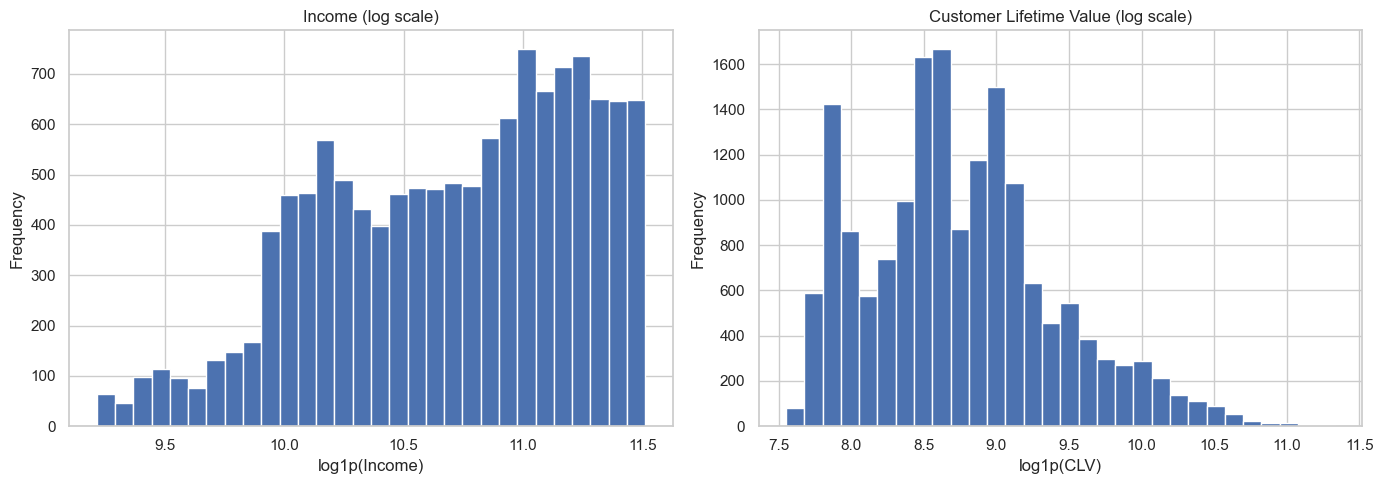

In [328]:
# Replace 0s before applying log1p
income_log = np.log1p(customers['Income'].replace(0, np.nan))
clv_log = np.log1p(customers['Customer Lifetime Value'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(income_log.dropna(), bins=30)
axes[0].set_title('Income (log scale)')
axes[0].set_xlabel('log1p(Income)')
axes[0].set_ylabel('Frequency')

axes[1].hist(clv_log.dropna(), bins=30)
axes[1].set_title('Customer Lifetime Value (log scale)')
axes[1].set_xlabel('log1p(CLV)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


After applying the logarithmic scale, both income and customer lifetime value show more normal-like distributions.
This confirms that the original variables were right-skewed (most customers have lower income and CLV, while a few have very high values).
The transformation makes the data easier to interpret and better suited for later modeling steps.

<a class="anchor" id="3rd-bullet">

### 1.6. Pre-Processing
    
</a>

<a class="anchor" id="3rd-bullet">

### 1.6.1. Filling Missing Values
    
</a>

- As we saw before, there are missing values in the variables "Income" (20 NaN's), "Customer Lifetime Value" (20 NaN's) and "CancellationDate" (14611 NaN's).

- We will start by treating the ***missing values in "Income" and "Customer Lifetime Value"***

In [329]:
# Check the number of missing values again
customers[['Income', 'Customer Lifetime Value']].isna().sum()

Income                     20
Customer Lifetime Value    20
dtype: int64

- We decided to use the ***median*** to fill the missing values of these two variables.

- Given the right-skewed distribution of both variables, median imputation was selected as the most appropriate method.

- The median is less sensitive to extreme values compared to the mean, ensuring that the imputed data reflects the central tendency of the distributions without introducing artificial bias.

- Also, we thought that using ***KNN*** could be unnecessary and possibly excessive, because we only have 20 missing values (≈0.12%), all in the same rows. Using KNN here might add noise rather than improve data quality, since it depends on distance calculations between variables that may not be properly scaled.

- This approach preserves all records, maintains dataset consistency, and minimizes potential distortion in subsequent clustering analysis.

In [330]:
# Compute median values
median_income = customers['Income'].median()
median_clv = customers['Customer Lifetime Value'].median()

# Fill missing values with the median
customers['Income'].fillna(median_income, inplace=True)
customers['Customer Lifetime Value'].fillna(median_clv, inplace=True)

# Confirm there are no missing values left
customers[['Income', 'Customer Lifetime Value']].isna().sum()


C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2050996778.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['Income'].fillna(median_income, inplace=True)
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2050996778.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Income                     0
Customer Lifetime Value    0
dtype: int64

- Now, we will treat the ***missing values in "CancellationDate".***

- This variables shows when a client left the program. If the value is NaN, it means that the client never left the program, so the client is still active.

- We decided to create a new variable, "Churn", that has this logic:

     - 1 if the client is still active (NaN in "CancellationDate")
     - 0 if client left the program (there is a date in "CancellationDate")

In [331]:
# Creation of variable Churn
customers['Churn'] = customers['CancellationDate'].notna().astype(int)

customers['Churn'].value_counts()


Churn
0    14471
1     2286
Name: count, dtype: int64

This means that 14471 customers left the program, and 2286 didn't.

- The variable "CancellationDate" contained 14611 missing values, corresponding to customers who remain active in the loyalty program.
Instead of treating these missing values as data quality issues, they were reinterpreted as meaningful information.

- A new binary variable, "Churn", was created to indicate whether a customer is currently active (1) or has canceled their membership (0).
This feature will be useful in subsequent analyses to identify behavioral differences between active and inactive customers and to support segmentation based on retention patterns.

<a class="anchor" id="3rd-bullet">

### 1.6.2. Feature Engineering
    
</a>

After creating the variable "Churn", there are a few more variables that we decided to create to enhance the analytical depth of the dataset.

These new variables were created to represent temporal, demographic, and behavioral dimensions that are not directly available in the raw data but are highly relevant for customer segmentation.

The variables **AccountDuration** and **YearsInProgram** are really important but in order to do that I think that we need to deal with the inconsistencies related to the Enrollment and Cancelation date first

**IncomeGroup**  

This variable segments customers into three income levels — Low, Medium, and High — based on the distribution of the Income variable divided into equal-sized groups (tertiles).
It allows for more granular analysis of customer profitability and loyalty patterns across income brackets.

In [332]:
customers['IncomeGroup'] = pd.qcut(customers['Income'], 3, labels=['Low','Medium','High'])



**MaritalGroup**  

- Simplifies the Marital Status variable (which originally had the categories "Married", Divorced" and "Single") into two broader categories: Married and Not Married. So, joining "Single" and "Divorced".

- This reduces noise and helps ensure more stable cluster formation, avoiding underrepresented categories.

In [333]:
customers['MaritalGroup'] = customers['Marital Status'].replace({
    'Married': 'Married',
    'Single': 'Not Married',
    'Divorced': 'Not Married'
})


**EnrollmentYear**  

- This variable extracts the year of enrollment from "EnrollmentDateOpening".

- For example, maybe many customers joined the program in 2020 because there was a specific campaign.

- It allows tracking customer acquisition trends over time and understanding whether older members differ from recent ones.

In [334]:
customers['EnrollmentYear'] = customers['EnrollmentDateOpening'].dt.year


**EducationLevelCode**  

- Encodes education levels as ordinal values (from lowest to highest).

- This transformation supports correlation analysis and machine learning models requiring numeric inputs.

In [335]:
education_order = {'High School or Below': 1, 'College': 2, 'Bachelor': 3, 'Master': 4, 'Doctor': 5}
customers['EducationLevelCode'] = customers['Education'].map(education_order)


**ProvinceActivity**  

- Represents the density of customers per province (counts the number of customers in the same province as the customer)

- It can reveal regional concentration patterns and help identify geographic differences in loyalty behavior. So, it can pretty much show if a certain customer belongs to a province that is more or less active.

In [336]:
province_counts = customers['Province or State'].value_counts()
customers['ProvinceActivity'] = customers['Province or State'].map(province_counts)


**PostalArea & PostalAreaActivity**  

These features extract the first three characters of each postal code (representing a regional area) and calculate the total number of customers within each area.
PostalAreaActivity captures regional density and helps identify geographic concentration of customers.

In [337]:
customers['PostalArea'] = customers['Postal code'].str[:3]
postal_counts = customers['PostalArea'].value_counts()
customers['PostalAreaActivity'] = customers['PostalArea'].map(postal_counts)


**LoyaltyScore**  

This ordinal variable converts loyalty program tiers (Aurora, Nova, Star) into numeric values (1, 2, 3).
It simplifies correlation analysis and supports quantitative modeling of loyalty intensity.

In [338]:
loyalty_order = {'Aurora': 1, 'Nova': 2, 'Star': 3}
customers['LoyaltyScore'] = customers['LoyaltyStatus'].map(loyalty_order)


**ValueToIncomeRatio**  



Represents the relationship between a customer’s lifetime value and their income.
This ratio provides insight into how much value a customer generates relative to their earning capacity, highlighting profitability efficiency.

In [339]:
customers['ValueToIncomeRatio'] = customers['Customer Lifetime Value'] / (customers['Income'] + 1)


**MarriedHighIncome**  


A binary feature that identifies customers who are both married and belong to the High income group.
Combining marital and income information helps reveal socio-economic segments with potentially stronger loyalty or purchasing power.

In [340]:
customers['MarriedHighIncome'] = (
    (customers['MaritalGroup'] == 'Married') &
    (customers['IncomeGroup'] == 'High')
).astype(int)


In [341]:
# Showing the dataset with the new variables
customers.head()

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,IncomeGroup,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity,PostalArea,PostalAreaActivity,LoyaltyScore,ValueToIncomeRatio,MarriedHighIncome
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,High,Married,2019,3,5410,M2Z,257,3,0.054730,1
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,Low,Not Married,2019,2,995,T3G,226,3,3839.610000,0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,Low,Not Married,2017,2,4379,V6E,1447,3,3839.750000,0
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,Low,Not Married,2016,2,5410,P1W,275,3,3839.750000,0
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,High,Married,2017,3,3280,J8Y,358,3,0.039279,1


In [342]:
customers.dtypes

Loyalty#                            int64
Province or State                  object
City                               object
Latitude                          float64
Longitude                         float64
Postal code                        object
Gender                             object
Education                          object
Location Code                      object
Income                            float64
Marital Status                     object
LoyaltyStatus                      object
EnrollmentDateOpening      datetime64[ns]
CancellationDate           datetime64[ns]
Customer Lifetime Value           float64
EnrollmentType                     object
Churn                               int64
IncomeGroup                      category
MaritalGroup                       object
EnrollmentYear                      int32
EducationLevelCode                  int64
ProvinceActivity                    int64
PostalArea                         object
PostalAreaActivity                

In [343]:
customers.nunique()

Loyalty#                   16757
Province or State             11
City                          29
Latitude                      49
Longitude                     49
Postal code                   75
Gender                         2
Education                      5
Location Code                  3
Income                      5688
Marital Status                 3
LoyaltyStatus                  3
EnrollmentDateOpening       2449
CancellationDate            1255
Customer Lifetime Value     7984
EnrollmentType                 2
Churn                          2
IncomeGroup                    3
MaritalGroup                   2
EnrollmentYear                 7
EducationLevelCode             5
ProvinceActivity              11
PostalArea                    71
PostalAreaActivity            50
LoyaltyScore                   3
ValueToIncomeRatio          8028
MarriedHighIncome              2
dtype: int64

<a class="anchor" id="3rd-bullet">

### 1.7. Visual Exploration Including The New Variables
    
</a>

<a class="anchor" id="3rd-bullet">

### 1.7.1. Visualing Numeric Features
    
</a>

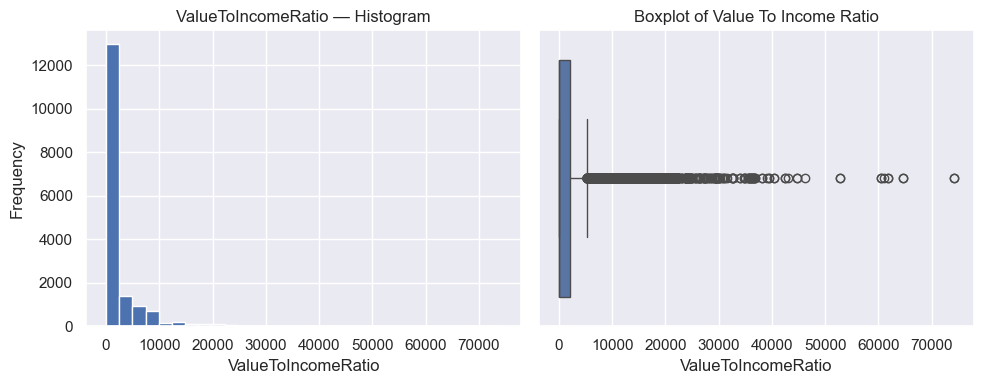

In [344]:
sns.set()

subplot_figsize = (10, 4)

fig, axes = plt.subplots(1, 2, figsize=subplot_figsize)

axes[0].hist(customers['ValueToIncomeRatio'], bins=30)
axes[0].set_title('ValueToIncomeRatio — Histogram')
axes[0].set_xlabel('ValueToIncomeRatio')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=customers["ValueToIncomeRatio"], ax=axes[1])
axes[1].set_title("Boxplot of Value To Income Ratio")

plt.tight_layout()
plt.show()


The ValueToIncomeRatio shows a highly right-skewed distribution. Most customers generate a relatively small lifetime value compared to their income, while a small group stands out with very high ratios. This indicates strong differences in profitability efficiency across the customer base — a few customers deliver much higher returns relative to their earning capacity. The variable contains many upper-end outliers and a low median, suggesting that most customers are low-value in relative terms. Because of its skewness, a log transformation is recommended before modeling, but it remains a useful indicator for identifying high-value, high-efficiency customer segments.

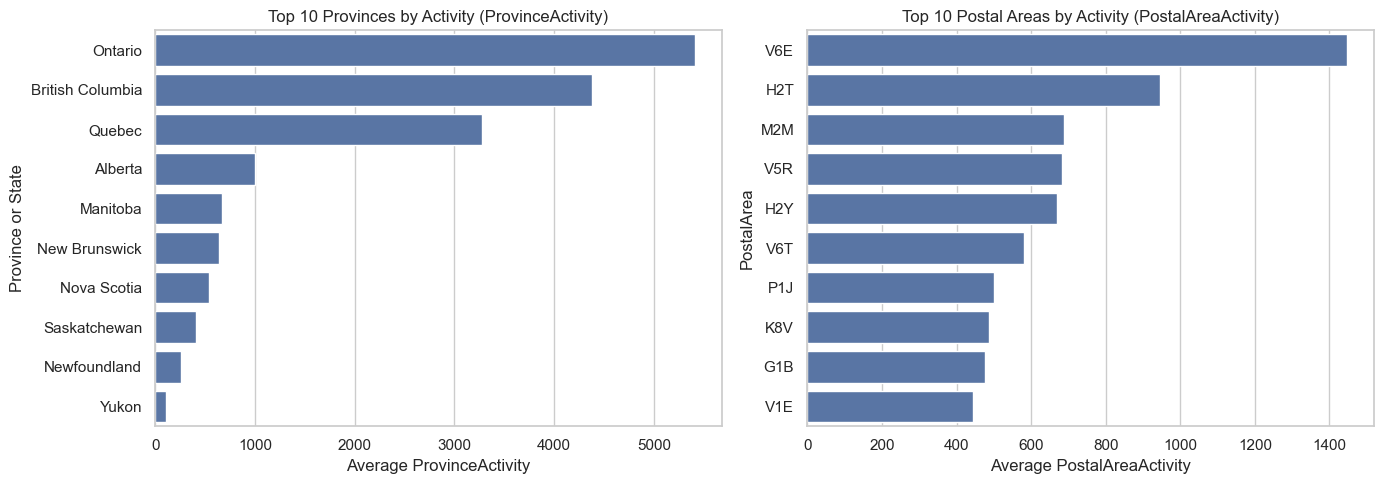

In [345]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Top 10 Provinces by activity
top_prov_activity = customers.groupby("Province or State")["ProvinceActivity"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_prov_activity.values, y=top_prov_activity.index, ax=axes[0])
axes[0].set_title("Top 10 Provinces by Activity (ProvinceActivity)")
axes[0].set_xlabel("Average ProvinceActivity")
axes[0].set_ylabel("Province or State")

# Top 10 Postal Areas by activity
top_postal_activity = customers.groupby("PostalArea")["PostalAreaActivity"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_postal_activity.values, y=top_postal_activity.index, ax=axes[1])
axes[1].set_title("Top 10 Postal Areas by Activity (PostalAreaActivity)")
axes[1].set_xlabel("Average PostalAreaActivity")
axes[1].set_ylabel("PostalArea")

plt.tight_layout()
plt.show()

The charts show clear regional concentration patterns. Provinces like Ontario, British Columbia, and Quebec have the highest customer density, indicating that most of the company’s clients are located in these major regions. At a finer level, postal areas such as V6E and H2T stand out as the most active, suggesting urban hubs with higher engagement or market penetration. Overall, the data reveal a strong geographic imbalance, where a few provinces and postal zones account for most customer activity.

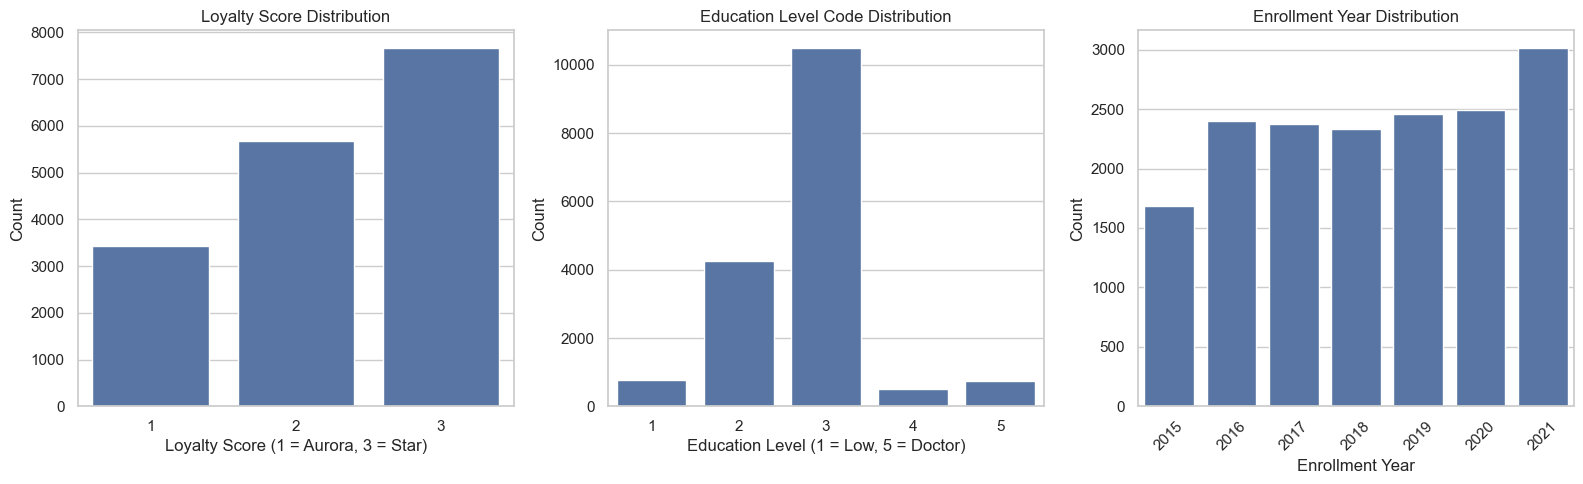

In [346]:


sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16,5))

# LoyaltyScore
sns.countplot(data=customers, x="LoyaltyScore", ax=axes[0],
              order=sorted(customers["LoyaltyScore"].dropna().unique()))
axes[0].set_title("Loyalty Score Distribution")
axes[0].set_xlabel("Loyalty Score (1 = Aurora, 3 = Star)")
axes[0].set_ylabel("Count")

# EducationLevelCode
sns.countplot(data=customers, x="EducationLevelCode", ax=axes[1],
              order=sorted(customers["EducationLevelCode"].dropna().unique()))
axes[1].set_title("Education Level Code Distribution")
axes[1].set_xlabel("Education Level (1 = Low, 5 = Doctor)")
axes[1].set_ylabel("Count")

# EnrollmentYear
sns.countplot(data=customers, x="EnrollmentYear", ax=axes[2],
              order=sorted(customers["EnrollmentYear"].dropna().unique()))
axes[2].set_title("Enrollment Year Distribution")
axes[2].set_xlabel("Enrollment Year")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


The first chart shows that most customers belong to the highest loyalty tier (Star), suggesting a strong base of engaged members, while the lower tiers (Aurora and Nova) are less represented.

The second chart indicates that the majority of customers have a Bachelor-level education (code 3), with relatively few holding postgraduate degrees (Master or Doctor). This points to a customer base with predominantly medium education levels.

Finally, the enrollment trend reveals a steady increase in new memberships, peaking in 2021, possibly linked to a specific promotional campaign or program expansion during that year. Overall, the patterns suggest a loyal, moderately educated customer base that has grown consistently over time.

<a class="anchor" id="3rd-bullet">

### 1.7.2. Visualing Categorical/ Features
    
</a>

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2542712381.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(["0 = Other", "1 = Married & High Income"])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2542712381.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3].set_xticklabels(["0 = Active", "1 = Left Program"])


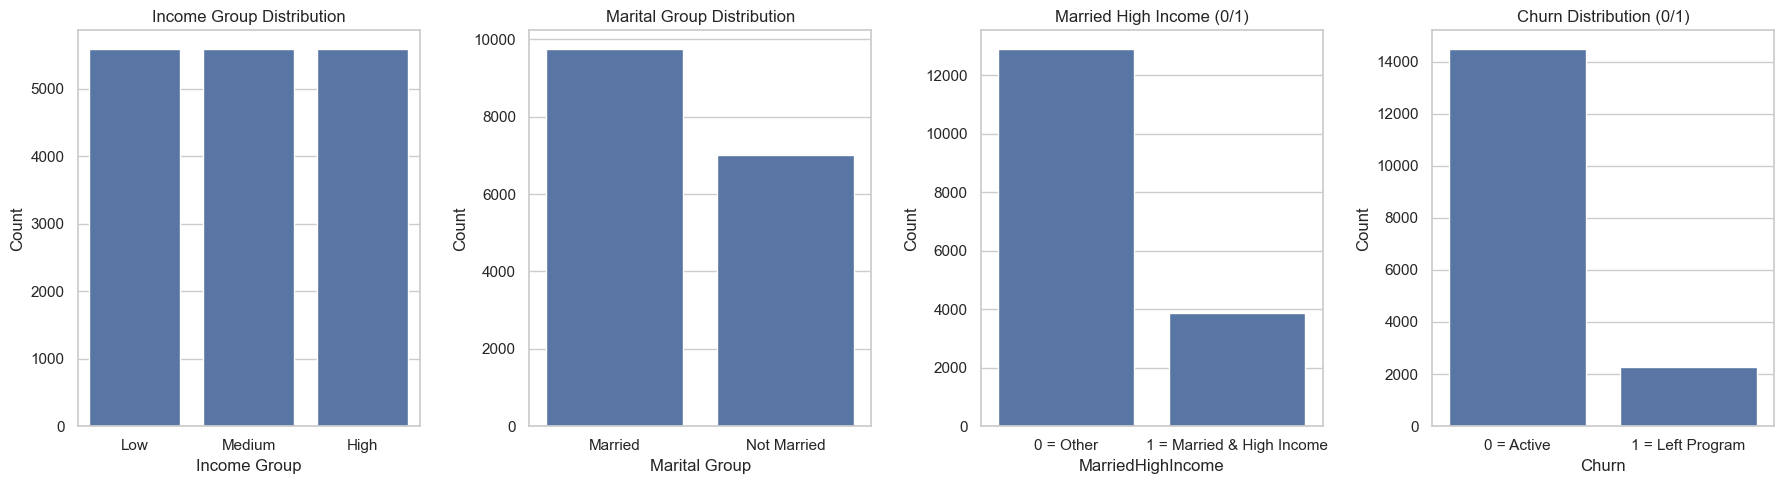

In [347]:

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(18,5))

# IncomeGroup
sns.countplot(data=customers, x="IncomeGroup", ax=axes[0],
              order=["Low", "Medium", "High"])
axes[0].set_title("Income Group Distribution")
axes[0].set_xlabel("Income Group")
axes[0].set_ylabel("Count")

# MaritalGroup
sns.countplot(data=customers, x="MaritalGroup", ax=axes[1],
              order=["Married", "Not Married"])
axes[1].set_title("Marital Group Distribution")
axes[1].set_xlabel("Marital Group")
axes[1].set_ylabel("Count")

# MarriedHighIncome
sns.countplot(data=customers, x="MarriedHighIncome", ax=axes[2])
axes[2].set_title("Married High Income (0/1)")
axes[2].set_xlabel("MarriedHighIncome")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels(["0 = Other", "1 = Married & High Income"])

# Churn
sns.countplot(data=customers, x="Churn", ax=axes[3])
axes[3].set_title("Churn Distribution (0/1)")
axes[3].set_xlabel("Churn")
axes[3].set_ylabel("Count")
axes[3].set_xticklabels(["0 = Active", "1 = Left Program"])

plt.tight_layout()
plt.show()


The IncomeGroup distribution is well balanced across Low, Medium, and High categories, confirming that the income tertiles were correctly formed and represent similar-sized segments.
Most customers are married, though a significant portion remains not married, ensuring diversity in marital status.
Only a small fraction of customers belong to the MarriedHighIncome segment, showing that high-income married individuals represent a niche but potentially valuable group.
Finally, the Churn distribution shows that the majority of customers are active (around 86%), while only a small share has left the program, indicating relatively strong overall retention.

<a class="anchor" id="3rd-bullet">

### 1.7.3. Relationships Between Engineered Features and Loyalty/Churn
    
</a>

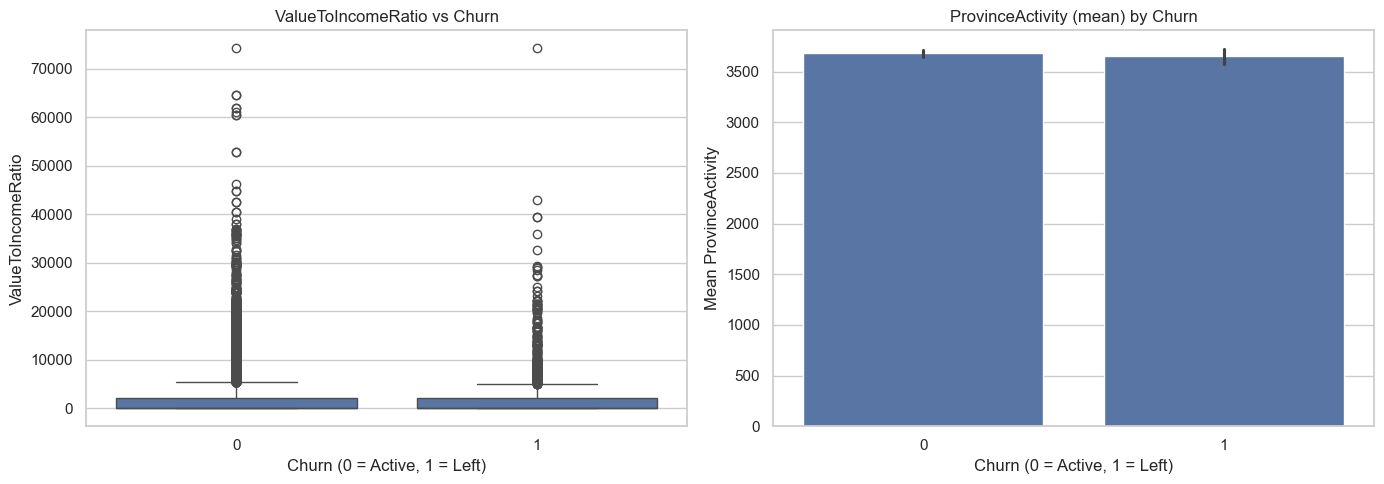

In [348]:
sns.set(style="whitegrid")

customers["Churn"] = pd.Categorical(customers["Churn"], categories=[0, 1], ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 1) ValueToIncomeRatio vs Churn (boxplot)
sns.boxplot(
    data=customers,
    x="Churn", y="ValueToIncomeRatio",
    ax=axes[0], whis=1.5
)
axes[0].set_title("ValueToIncomeRatio vs Churn")
axes[0].set_xlabel("Churn (0 = Active, 1 = Left)")
axes[0].set_ylabel("ValueToIncomeRatio")

# 2) ProvinceActivity vs Churn (mean barplot)
sns.barplot(
    data=customers,
    x="Churn", y="ProvinceActivity",
    estimator="mean", errorbar="ci", ax=axes[1]
)
axes[1].set_title("ProvinceActivity (mean) by Churn")
axes[1].set_xlabel("Churn (0 = Active, 1 = Left)")
axes[1].set_ylabel("Mean ProvinceActivity")

plt.tight_layout()
plt.show()

- The distribution of the Value-to-Income Ratio is highly skewed for both active and churned customers, with no visible distinction between groups. This suggests that customer profitability efficiency does not significantly impact the likelihood of leaving the program — churn behavior appears independent of individual value generation.
- The mean ProvinceActivity is nearly identical between active and churned customers, indicating that regional customer density has little to no influence on retention. Provinces with higher engagement levels do not necessarily retain customers better.

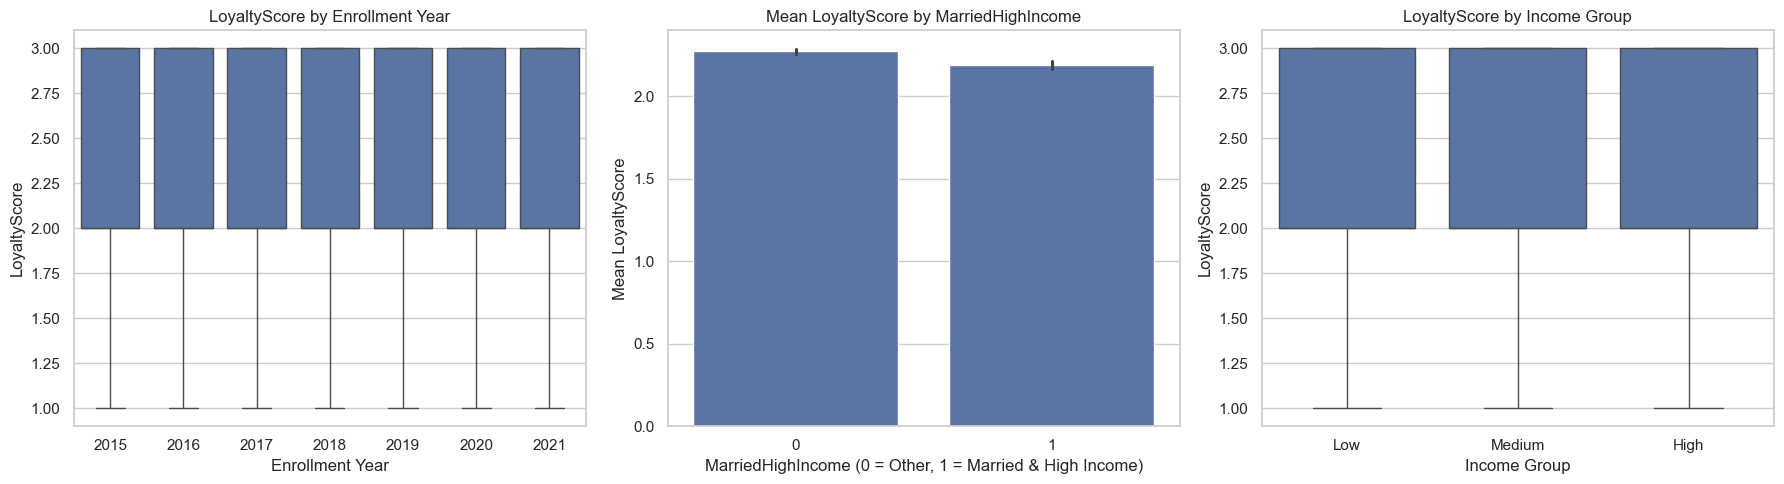

In [349]:
sns.set(style="whitegrid")

# Optional: set category orders
customers["IncomeGroup"] = pd.Categorical(customers["IncomeGroup"], categories=["Low","Medium","High"], ordered=True)
customers["MarriedHighIncome"] = pd.Categorical(customers["MarriedHighIncome"], categories=[0,1], ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1) EnrollmentYear vs LoyaltyScore (boxplot)
sns.boxplot(
    data=customers,
    x="EnrollmentYear", y="LoyaltyScore",
    ax=axes[0]
)
axes[0].set_title("LoyaltyScore by Enrollment Year")
axes[0].set_xlabel("Enrollment Year")
axes[0].set_ylabel("LoyaltyScore")

# 2) MarriedHighIncome vs LoyaltyScore (barplot of mean)
sns.barplot(
    data=customers,
    x="MarriedHighIncome", y="LoyaltyScore",
    estimator="mean", errorbar="ci", ax=axes[1]
)
axes[1].set_title("Mean LoyaltyScore by MarriedHighIncome")
axes[1].set_xlabel("MarriedHighIncome (0 = Other, 1 = Married & High Income)")
axes[1].set_ylabel("Mean LoyaltyScore")

# 3) IncomeGroup vs LoyaltyScore (boxplot)
sns.boxplot(
    data=customers,
    x="IncomeGroup", y="LoyaltyScore",
    order=["Low","Medium","High"], ax=axes[2]
)
axes[2].set_title("LoyaltyScore by Income Group")
axes[2].set_xlabel("Income Group")
axes[2].set_ylabel("LoyaltyScore")

plt.tight_layout()
plt.show()

- Loyalty levels have remained consistently high over time, with a strong presence of Star members across all enrollment years. This stability suggests that the program maintains a consistent appeal and engagement level, regardless of when customers joined.
- The Married & High-Income group shows a slightly lower mean loyalty score compared to others, though the difference is minimal. This indicates that higher income and marital status alone are not strong predictors of customer loyalty.
- Loyalty scores are similar across Low, Medium, and High income groups, implying that loyalty does not depend on financial standing. The program seems to attract and retain customers uniformly across income levels.

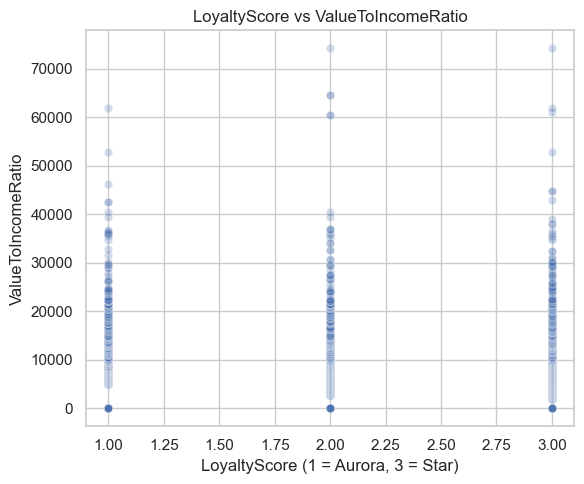

In [350]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=customers,
    x="LoyaltyScore", y="ValueToIncomeRatio",
    alpha=0.25
)
plt.title("LoyaltyScore vs ValueToIncomeRatio")
plt.xlabel("LoyaltyScore (1 = Aurora, 3 = Star)")
plt.ylabel("ValueToIncomeRatio")
plt.tight_layout()
plt.show()

The scatterplot shows a wide dispersion of Value-to-Income ratios within each loyalty tier, with no clear trend across loyalty levels. This reinforces that higher loyalty scores are not necessarily associated with customers generating proportionally higher value relative to income — loyalty and profitability appear to be distinct dimensions.

<a class="anchor" id="3rd-bullet">

### 1.7.4. Heatmap of numeric engineered features
    
</a>

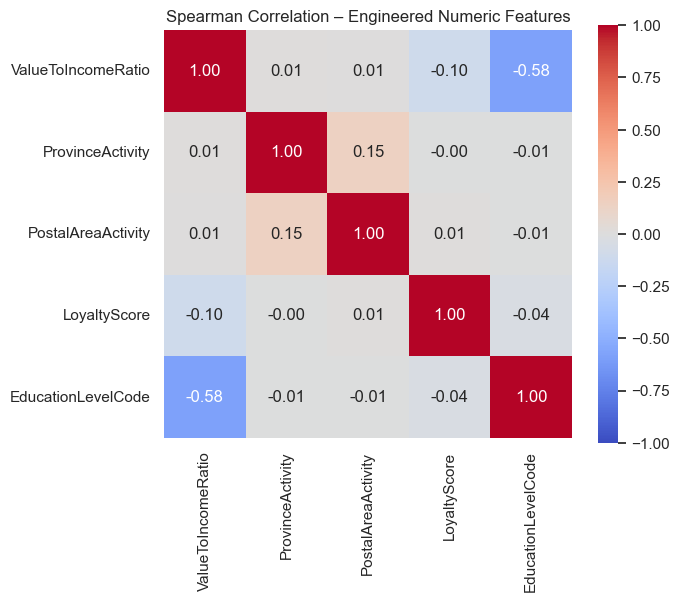

In [351]:
sns.set(style="whitegrid")

# Select relevant engineered numeric features
num_feats = ["ValueToIncomeRatio", "ProvinceActivity", "PostalAreaActivity",
             "LoyaltyScore", "EducationLevelCode"]

# Compute Spearman correlation (handles non-linear/ordinal data)
corr = customers[num_feats].corr(method="spearman")

# Plot heatmap
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, square=True)
plt.title("Spearman Correlation – Engineered Numeric Features")
plt.tight_layout()
plt.show()

The correlation heatmap shows that most engineered variables are largely independent from one another, which is positive for modeling — it means each feature likely adds unique information.
The only notable relationship is a moderate negative correlation (-0.58) between ValueToIncomeRatio and EducationLevelCode, suggesting that customers with higher education levels tend to generate lower value relative to their income. Other correlations are negligible, confirming limited redundancy between engineered features.

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 2. Flights Dataset
    

    
</div>

<a class="anchor" id="1st-bullet">

## Importing, Exploring and Pre-processing   
</a>

<a class="anchor" id="3rd-bullet">

### 2.1. Import the dataset
    
</a>

In [352]:
flights = pd.read_csv('DM_AIAI_FlightsDB.csv')

<a class="anchor" id="3rd-bullet">

### 2.2. Exploratory Data Analysis 
    
</a>

In [353]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [354]:
flights.shape

(608436, 10)

The flights dataset consists of 608436 observations and 10 variables.

In [355]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [356]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [357]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object


- The variable "YearMonthDate" should be datetime

In [358]:
flights[['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
         'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']].describe()


,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000
mean,3.908107,0.983944,7939.341419,793.777781,235.251678,2.324835
std,5.057889,2.003785,10260.421873,1025.918521,983.233374,9.725168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,856.400000,85.275000,0.000000,0.000000
75%,7.200000,0.900000,15338.175000,1533.712500,0.000000,0.000000
max,21.000000,11.000000,42040.000000,4204.000000,7496.000000,74.000000


#### Summary:

- Most customers don’t fly every month, but there is a small group of highly active travellers.

- Flight frequency and distance are heavily skewed, showing a mix of occasional and heavy users.

- Point accumulation exceeds redemption, suggesting latent loyalty value that the airline could leverage (e.g., campaigns to encourage point spending).

- Some customers travel long distances or frequently with companions, likely representing premium or family-oriented segments.

<a class="anchor" id="3rd-bullet">

### 2.2.3. Checking for Missing Values
    
</a>

In [359]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [360]:
# Making sure that there are really no missing values in this dataset
# Because sometimes instead of NAn, the rows have ""

# replace "" by nans
flights.replace("", np.nan, inplace=True)

# count of missing values
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

<a class="anchor" id="3rd-bullet">

### 2.2.4. Checking for Duplicated Values
    
</a>

In [361]:
# Checking for duplicated observations
flights.duplicated().sum()

np.int64(2903)

In [362]:
# Removing all duplicates (2903)
flights = flights.drop_duplicates()


In [363]:
flights.duplicated().sum()


np.int64(0)

In [364]:
# Checking for rows with the same client (loyalty#), year and month
# But the other columns don't need to be the same

flights[flights.duplicated(subset=['Loyalty#', 'Year', 'Month'], keep=False)]


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
27,279419,2021,12,12/1/2021,12.0,0.0,11849.0,1184.00,0.0,0.0
171,990512,2021,12,12/1/2021,5.0,2.0,31991.0,3199.00,0.0,0.0
248,322169,2021,12,12/1/2021,2.0,0.0,17125.0,1712.00,0.0,0.0
297,106001,2021,12,12/1/2021,7.0,0.0,26469.0,2646.00,0.0,0.0
678,402697,2021,12,12/1/2021,12.0,3.0,10721.0,1072.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
608222,988392,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608248,989528,2019,12,12/1/2019,11.7,0.9,28453.5,2845.35,0.0,0.0
608249,989528,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608298,992168,2019,12,12/1/2019,11.7,4.5,2987.1,298.71,0.0,0.0


In [365]:
# Checking how many cases of clients with multiple rows in the same year and month exist

flights.duplicated(subset=['Loyalty#', 'Year', 'Month']).sum()


np.int64(3001)

In [366]:
# Remove duplicated rows keeping only the first occurrence
flights = flights.drop_duplicates(subset=['Loyalty#', 'Year', 'Month'], keep='first')

# Confirm there are no more duplicates
flights.duplicated(subset=['Loyalty#', 'Year', 'Month']).sum()


np.int64(0)

In [367]:
flights.shape

(602532, 10)

After reviewing the duplicated entries, we confirmed that they represent multiple
records of the same customer within the same year and month. 

We decided to keep only the first occurrence and remove the remaining duplicates. 

This ensures that each customer has a single record per month while maintaining
data integrity.


<a class="anchor" id="3rd-bullet">

### 2.3. Initial Data Preparation
    
</a>

<a class="anchor" id="3rd-bullet">

### 2.3.1. Converting variables to datetime
    
</a>

In [368]:
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'])

In [369]:
flights[['YearMonthDate']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   YearMonthDate  602532 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 9.2 MB


<a class="anchor" id="3rd-bullet">

### 2.3.2. Converting variables to integer
    
</a>

In [370]:
#turn into int
flights['NumFlightsWithCompanions'] = flights['NumFlightsWithCompanions'].round().astype(int)

In [371]:
#turn into int
flights['NumFlights'] = flights['NumFlights'].round().astype(int)

In [372]:
flights[['NumFlights']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   NumFlights  602532 non-null  int64
dtypes: int64(1)
memory usage: 9.2 MB


In [373]:
flights[['NumFlightsWithCompanions']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 1 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   NumFlightsWithCompanions  602532 non-null  int64
dtypes: int64(1)
memory usage: 9.2 MB


<a class="anchor" id="3rd-bullet">

### 2.3.3. Checking for inconsistencies
    
</a>

In [374]:
invalid_rows = flights[(flights['NumFlights'] == 0) & 
        ((flights['DistanceKM'] > 0) | 
         (flights['PointsAccumulated'] > 0) |
         (flights['PointsRedeemed'] > 0) |
         (flights['DollarCostPointsRedeemed'] > 0) |
         (flights['NumFlightsWithCompanions'] > 0))]
print("Inconsistent rows:", len(invalid_rows))
print("Percentage of dataset:", round(len(invalid_rows) / len(flights) * 100, 2), "%")

Inconsistent rows: 5856
Percentage of dataset: 0.97 %


- Since it is less than 1% of the rows I think that we sould delete the rows

<a class="anchor" id="3rd-bullet">

### 2.4. Data Visualization
    
</a>

<a class="anchor" id="3rd-bullet">

### 2.4.1. Visualization of Numeric Variables (Univariate Analysis)
    
</a>

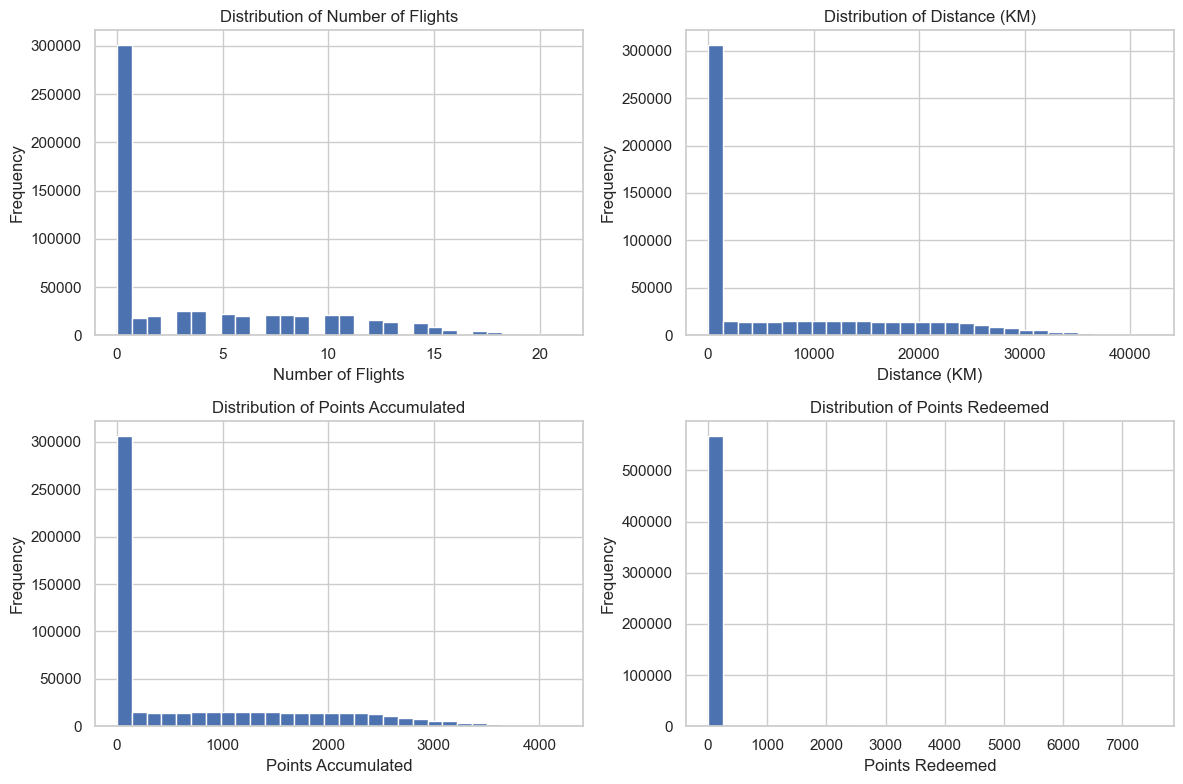

In [375]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(flights['NumFlights'], bins=30)
axes[0, 0].set_title('Distribution of Number of Flights')
axes[0, 0].set_xlabel('Number of Flights')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(flights['DistanceKM'], bins=30)
axes[0, 1].set_title('Distribution of Distance (KM)')
axes[0, 1].set_xlabel('Distance (KM)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(flights['PointsAccumulated'], bins=30)
axes[1, 0].set_title('Distribution of Points Accumulated')
axes[1, 0].set_xlabel('Points Accumulated')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(flights['PointsRedeemed'], bins=30)
axes[1, 1].set_title('Distribution of Points Redeemed')
axes[1, 1].set_xlabel('Points Redeemed')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The distributions of flight-related variables are highly right-skewed, showing that most customers have very limited flight activity. The majority of observations correspond to customers with few or no flights, short total travel distances, and low numbers of points accumulated or redeemed. Only a small group of frequent flyers shows much higher values, forming the long right tails visible in each plot. This pattern suggests that the program has a large base of low-activity members and a smaller segment of highly active travelers who contribute disproportionately to the total points and distance metrics.

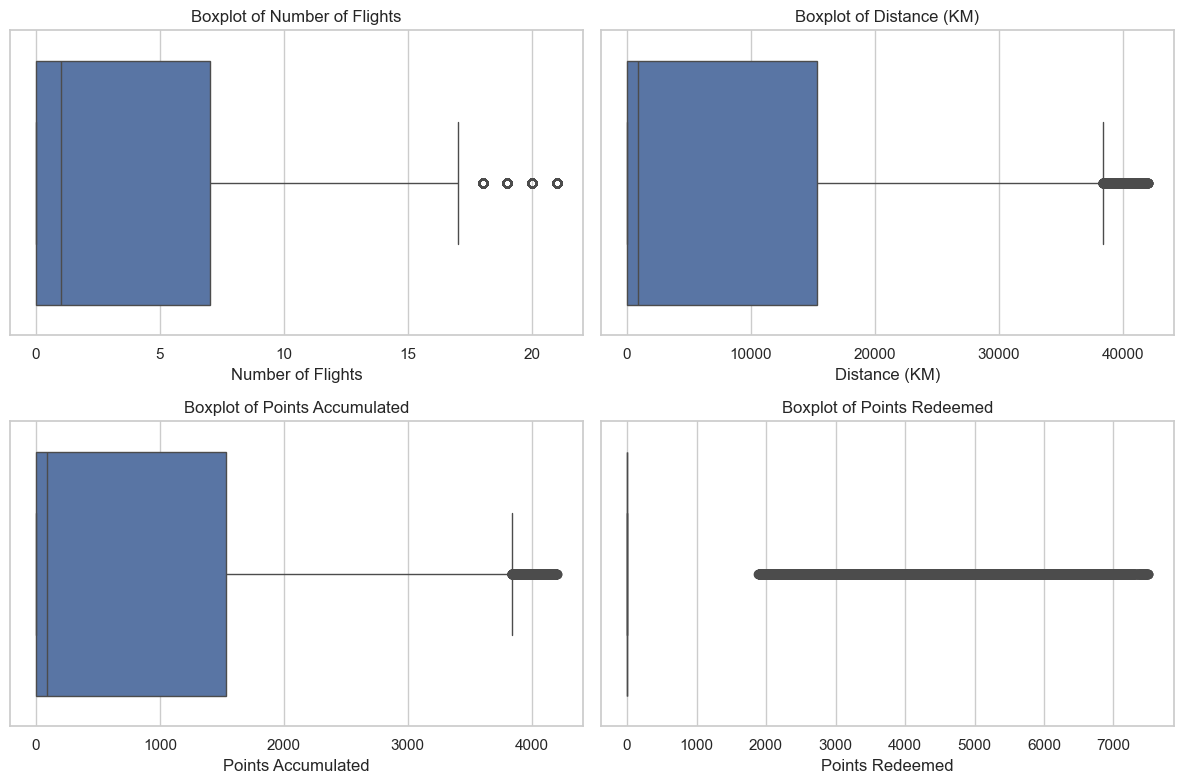

In [376]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=flights['NumFlights'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of Number of Flights')
axes[0, 0].set_xlabel('Number of Flights')

sns.boxplot(x=flights['DistanceKM'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Distance (KM)')
axes[0, 1].set_xlabel('Distance (KM)')

sns.boxplot(x=flights['PointsAccumulated'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Points Accumulated')
axes[1, 0].set_xlabel('Points Accumulated')

sns.boxplot(x=flights['PointsRedeemed'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Points Redeemed')
axes[1, 1].set_xlabel('Points Redeemed')


plt.tight_layout()
plt.show()


These boxplots illustrate the presence of significant variability and multiple outliers across all flight-related variables. For each metric — Number of Flights, Distance (KM), Points Accumulated, and Points Redeemed — most observations are concentrated near the lower end of the scale, while a small group of customers shows extremely high values. This confirms that the dataset is highly skewed, with a large majority of low-activity members and a few very active flyers who travel more frequently, cover longer distances, and accumulate or redeem substantially more points.

<a class="anchor" id="3rd-bullet">

### 2.4.2 Correlation Analysis (Bivariate Relationships)
    
</a>

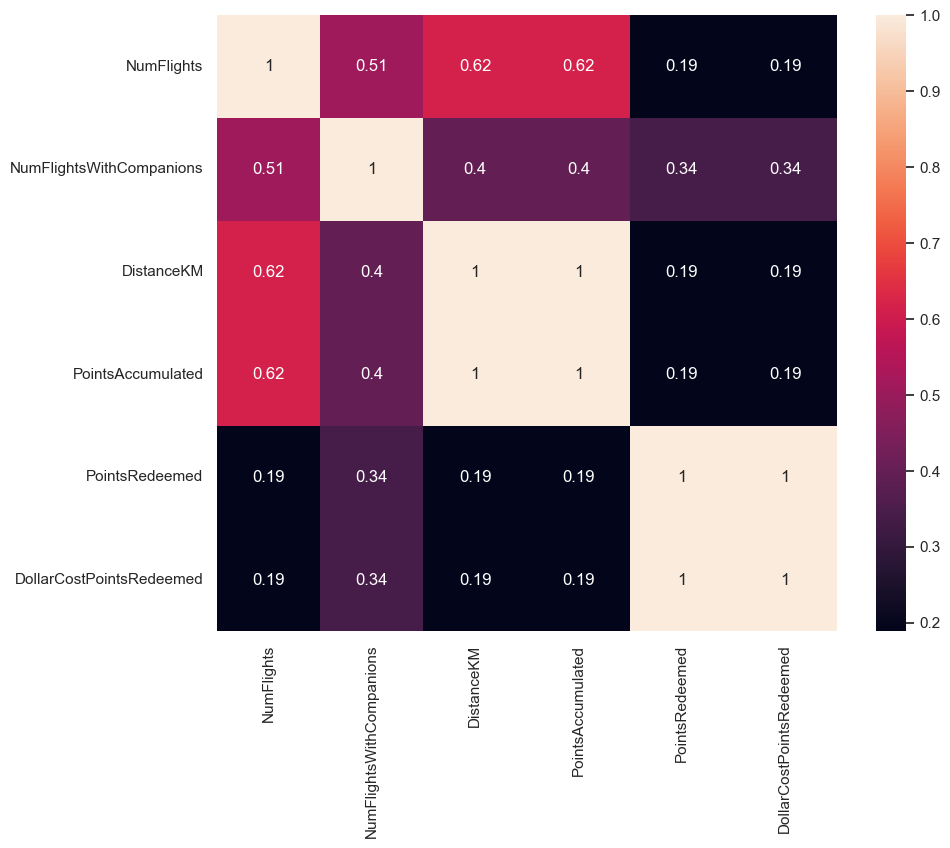

In [377]:
sns.set(style="white")

numeric_features = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed'
]

corr = flights[numeric_features].corr(method='pearson')

fig = plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, )
plt.show()

The correlation heatmap reveals moderate to strong positive relationships among the flight activity variables. Specifically, Number of Flights, Distance (KM), and Points Accumulated are strongly correlated (around 0.6), indicating that customers who fly more frequently also travel longer distances and earn more points — an expected pattern in a mileage-based loyalty program. The Number of Flights with Companions shows weaker correlations with these variables, suggesting that traveling with others is less tied to overall flight activity. In contrast, Points Redeemed and Dollar Cost of Points Redeemed exhibit only weak correlations with the other metrics, implying that redemption behavior is more independent from flight frequency and distance traveled.

Text(0.5, 1.0, 'Relationship between Number of Flights and Distance')

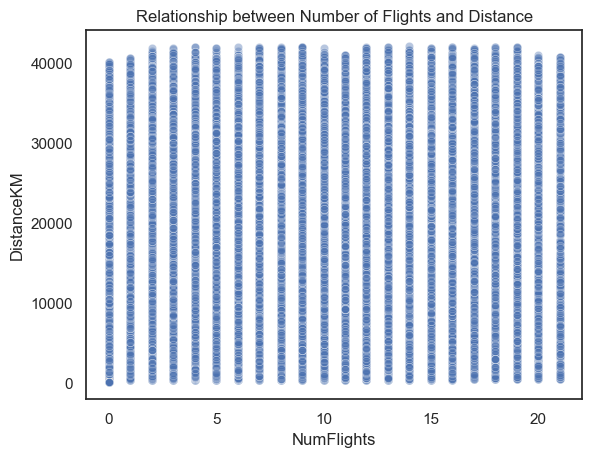

In [378]:
sns.scatterplot(data=flights, x='NumFlights', y='DistanceKM', alpha=0.4)
plt.title('Relationship between Number of Flights and Distance')

This scatterplot shows how the total flight distance varies with the number of flights per customer.
The points are vertically aligned because the number of flights is an integer, while distances are continuous.
Most customers fly few times, but those who travel more tend to cover larger total distances — as expected in a frequent-flyer context.

Text(0.5, 1.0, 'Points Accumulated vs Points Redeemed')

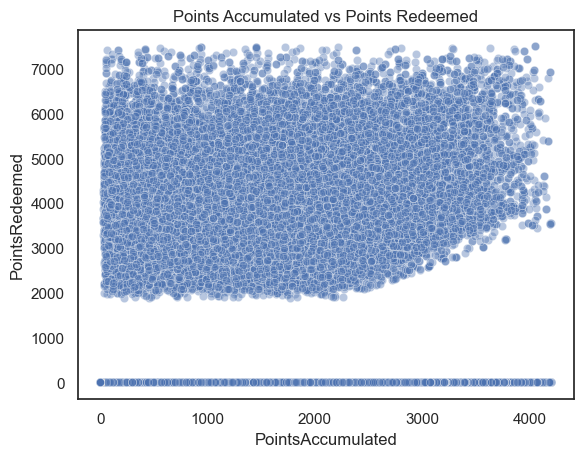

In [379]:
sns.scatterplot(data=flights, x='PointsAccumulated', y='PointsRedeemed', alpha=0.4)
plt.title('Points Accumulated vs Points Redeemed')

This chart explores the relationship between loyalty points earned and points redeemed.
There is a visible positive relationship — customers who accumulate more points generally redeem more.
However, many observations lie along the bottom axis (zero redemptions), suggesting that a large portion of customers never use their accumulated points.

<a class="anchor" id="3rd-bullet">

### 2.4.3 Temporal Patterns
</a>

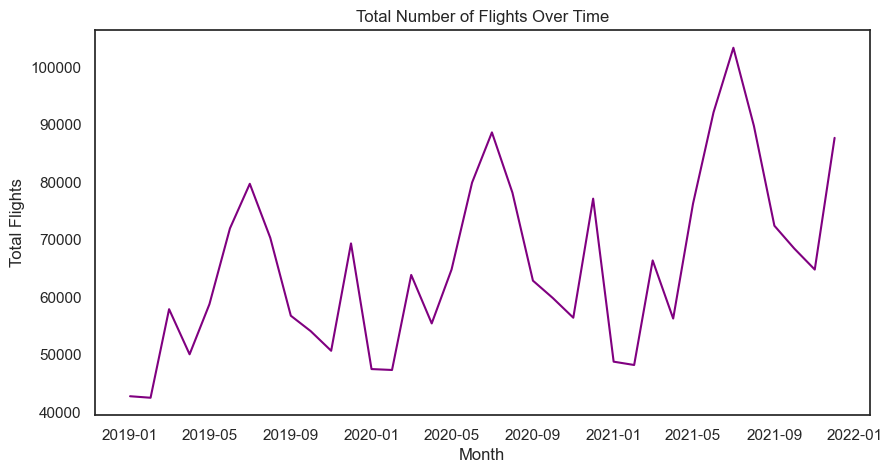

In [380]:
# Line chart - Total flights over time
flights_per_month = flights.groupby('YearMonthDate')['NumFlights'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(flights_per_month['YearMonthDate'], flights_per_month['NumFlights'], color='purple')
plt.title('Total Number of Flights Over Time')
plt.xlabel('Month')
plt.ylabel('Total Flights')
plt.show()


The line chart shows fluctuations in the total number of flights over time.
Despite month-to-month variability, there is a general upward trend with periodic peaks that may reflect seasonality or promotional periods.
The data also reveals temporary declines, possibly associated with external events or lower travel seasons.

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2424916187.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flights.groupby('Month')['NumFlights'].sum().reset_index(),


Text(0.5, 1.0, 'Total of flights per month')

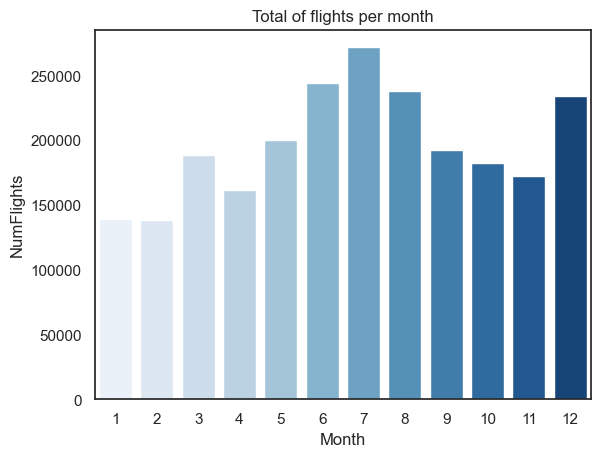

In [381]:
sns.barplot(data=flights.groupby('Month')['NumFlights'].sum().reset_index(),
            x='Month', y='NumFlights', palette='Blues')
plt.title('Total of flights per month')


This bar chart shows the total number of flights per month.
The number of flights increases steadily from the beginning of the year, peaking around July, and then slightly drops afterward.
This pattern suggests strong seasonality, likely related to summer holidays and end-of-year travel.

<a class="anchor" id="3rd-bullet">

### 2.4.4 Behavioral Insights
</a>

Text(0.5, 1.0, 'Distance vs Number of flights with companions')

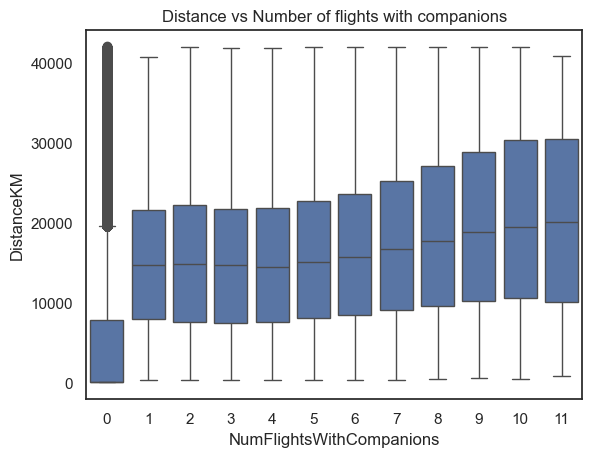

In [382]:
sns.boxplot(data=flights, x='NumFlightsWithCompanions', y='DistanceKM')
plt.title('Distance vs Number of flights with companions')

This boxplot examines how flight distance varies with the number of flights taken with companions.
As the number of companion flights increases, the median distance also tends to rise.
This could indicate that travelers who fly more frequently with others often take longer trips, such as vacations or group travel.

Text(0.5, 1.0, 'Monthly Evolution of Key Metrics')

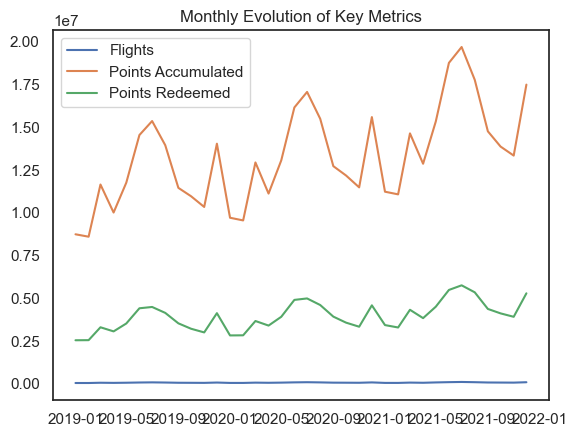

In [383]:
metrics_per_month = flights.groupby('YearMonthDate')[['NumFlights', 'PointsAccumulated', 'PointsRedeemed']].sum().reset_index()

plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['NumFlights'], label='Flights')
plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['PointsAccumulated'], label='Points Accumulated')
plt.plot(metrics_per_month['YearMonthDate'], metrics_per_month['PointsRedeemed'], label='Points Redeemed')
plt.legend()
plt.title('Monthly Evolution of Key Metrics')

This line chart compares the monthly evolution of the three main metrics — total flights, points accumulated, and points redeemed.
Points accumulated and redeemed show clear cyclical patterns over time, while flights remain relatively stable.
The similar peaks in all lines suggest that flying activity and loyalty program engagement move together.

<a class="anchor" id="3rd-bullet">

### 2.5. Feature Engineering
</a>

In [384]:
# create new variables

**ActiveMonth**  
- Many customers have months with zero flights and zero points.

- This binary flag indicates whether a customer was active during that month, making it easier to analyze loyalty frequency and churn.

In [385]:
#If the customer flew in a determined month
flights['ActiveMonth'] = (flights['NumFlights'] > 0).astype(int)

**RedeemRate**  
- The histogram showed that most customers never redeem points (PointsRedeemed = 0).
- This variable quantifies how much of the accumulated points are actually used, helping to distinguish engaged from inactive customers.

In [386]:
flights['RedeemRate'] = flights['PointsRedeemed'] / flights['PointsAccumulated'].replace(0, np.nan)

**AvgDistancePerFlight**  
- The scatterplot between NumFlights and DistanceKM showed some customers take many short flights, while others take few long flights.
- Calculating the average distance per flight helps identify travel patterns.
- It also reduces redundancy between two strongly correlated variables (correlation ≈ 0.62).

In [387]:
flights['AvgDistancePerFlight'] = flights['DistanceKM'] / flights['NumFlights'].replace(0, np.nan)

**CompanionshipRatio**  
- The boxplot showed that customers who travel more frequently with companions tend to take longer trips.
- This ratio measures the percentage of flights taken with others, which may indicate family or leisure travel.
- It can help segment customers into social vs solo travelers.

In [388]:
flights['CompanionshipRatio'] = flights['NumFlightsWithCompanions'] / flights['NumFlights'].replace(0, np.nan)

**MonthSeason**  
- The bar plot of flights per month showed strong seasonality, with peaks in July and December.

- Grouping months into seasons (Winter, Spring, Summer, Autumn) captures this cyclical pattern and can be useful in time-based models.

In [389]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

flights['MonthSeason'] = flights['Month'].apply(get_season)

In [390]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,ActiveMonth,RedeemRate,AvgDistancePerFlight,CompanionshipRatio,MonthSeason
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,1,0.000000,4692.000000,1.00,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,1,0.000000,1474.500000,0.30,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,1,1.221209,1644.437500,0.25,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,1,0.000000,2141.666667,0.00,Winter


In [391]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  602532 non-null  int64         
 1   Year                      602532 non-null  int64         
 2   Month                     602532 non-null  int64         
 3   YearMonthDate             602532 non-null  datetime64[ns]
 4   NumFlights                602532 non-null  int64         
 5   NumFlightsWithCompanions  602532 non-null  int64         
 6   DistanceKM                602532 non-null  float64       
 7   PointsAccumulated         602532 non-null  float64       
 8   PointsRedeemed            602532 non-null  float64       
 9   DollarCostPointsRedeemed  602532 non-null  float64       
 10  ActiveMonth               602532 non-null  int64         
 11  RedeemRate                307477 non-null  float64       
 12  AvgDist

In [392]:
flights.isna().sum()
flights.isna().mean() * 100

Loyalty#                     0.000000
Year                         0.000000
Month                        0.000000
YearMonthDate                0.000000
NumFlights                   0.000000
NumFlightsWithCompanions     0.000000
DistanceKM                   0.000000
PointsAccumulated            0.000000
PointsRedeemed               0.000000
DollarCostPointsRedeemed     0.000000
ActiveMonth                  0.000000
RedeemRate                  48.969183
AvgDistancePerFlight        49.941082
CompanionshipRatio          49.941082
MonthSeason                  0.000000
dtype: float64

<a class="anchor" id="3rd-bullet">

### 2.5.1. Distribution Analysis of Engineered Features
    
</a>

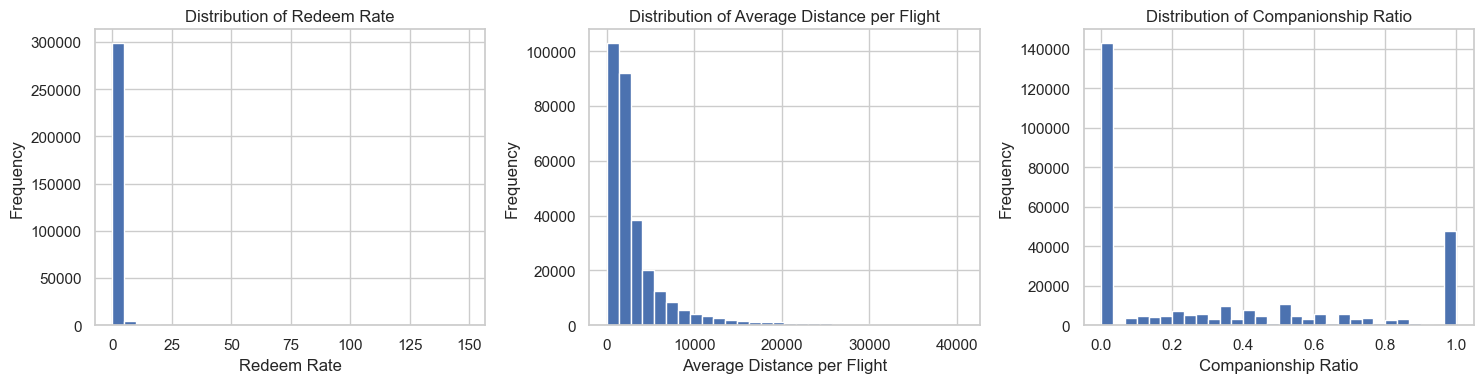

In [393]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Redeem Rate ---
axes[0].hist(flights['RedeemRate'], bins=30)
axes[0].set_title('Distribution of Redeem Rate')
axes[0].set_xlabel('Redeem Rate')
axes[0].set_ylabel('Frequency')

# --- Average Distance per Flight ---
axes[1].hist(flights['AvgDistancePerFlight'], bins=30)
axes[1].set_title('Distribution of Average Distance per Flight')
axes[1].set_xlabel('Average Distance per Flight')
axes[1].set_ylabel('Frequency')

# --- Companionship Ratio ---
axes[2].hist(flights['CompanionshipRatio'], bins=30)
axes[2].set_title('Distribution of Companionship Ratio')
axes[2].set_xlabel('Companionship Ratio')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The histograms show highly skewed distributions across all engineered variables. The Redeem Rate and Companionship Ratio are mostly concentrated near zero, meaning that most customers rarely redeem points or travel with companions. The Average Distance per Flight also has a strong right skew, indicating that most flights cover short distances, with few long-haul outliers. 

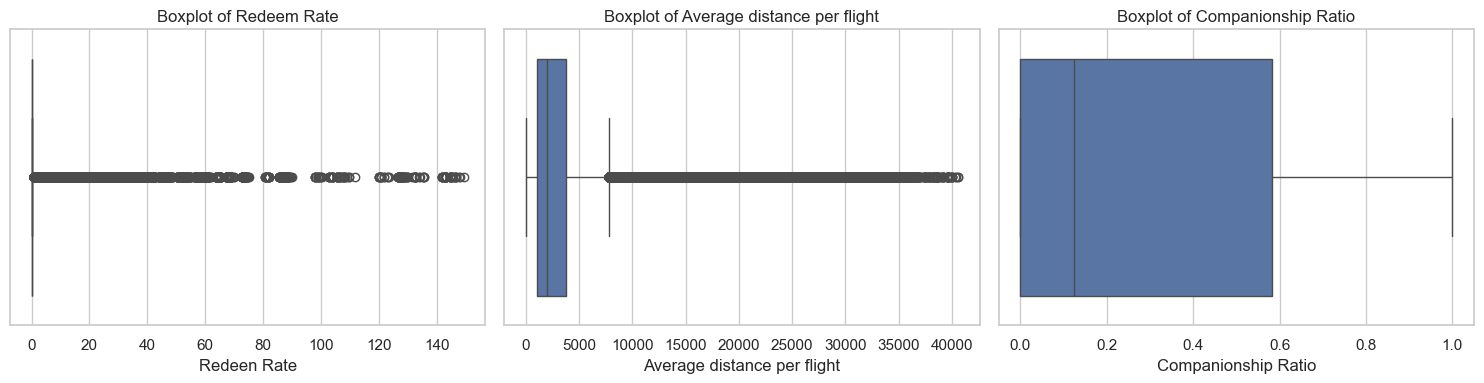

In [394]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=flights['RedeemRate'], ax=axes[0])
axes[0].set_title('Boxplot of Redeem Rate')
axes[0].set_xlabel('Redeen Rate')

sns.boxplot(x=flights['AvgDistancePerFlight'], ax=axes[1])
axes[1].set_title('Boxplot of Average distance per flight')
axes[1].set_xlabel('Average distance per flight')

sns.boxplot(x=flights['CompanionshipRatio'], ax=axes[2])
axes[2].set_title('Boxplot of Companionship Ratio')
axes[2].set_xlabel('Companionship Ratio')


plt.tight_layout()
plt.show()


The boxplots confirm the presence of significant outliers, particularly in Redeem Rate and Average Distance per Flight. The interquartile range is narrow, meaning that most customers fall within a limited behavioral pattern. The wide spread of outliers indicates the existence of a small subset of highly active or exceptional customers who accumulate or redeem many points or travel much farther than the average.

<a class="anchor" id="3rd-bullet">

### 2.5.2. Correlation between Original and Engineered Variables
    
</a>

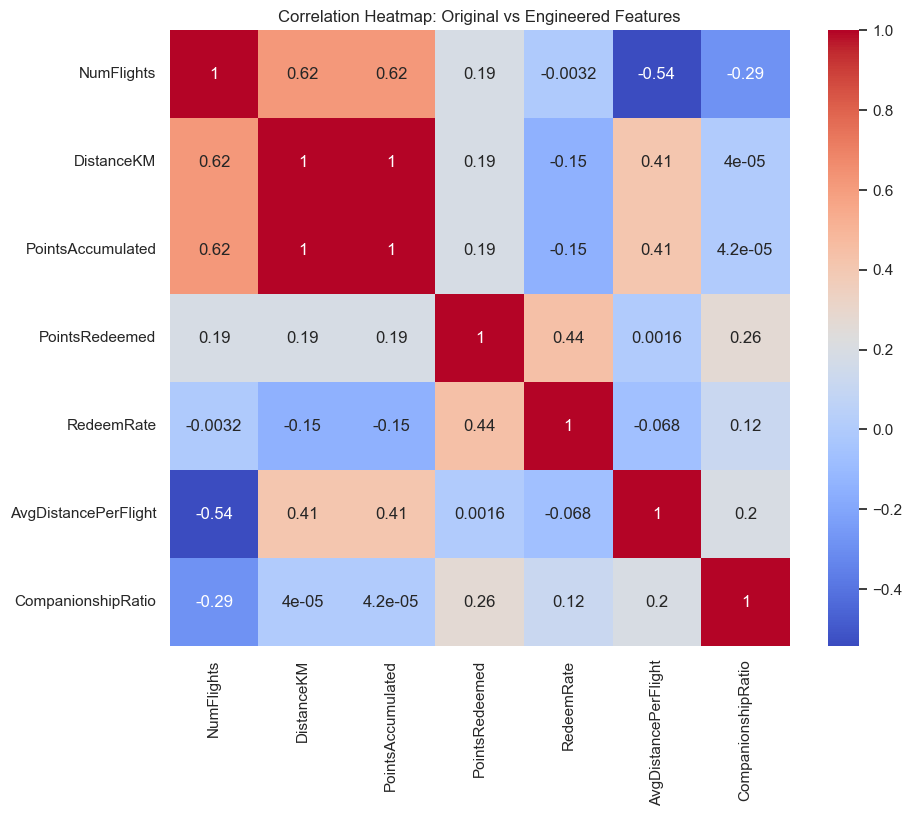

In [395]:
selected = ['NumFlights', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
            'RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']

plt.figure(figsize=(10, 8))
sns.heatmap(flights[selected].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Original vs Engineered Features')
plt.show()

The heatmap highlights strong correlations between NumFlights, DistanceKM, PointsAccumulated, and the new feature ActivityLevel, confirming that this derived variable effectively summarizes customer engagement. RedeemRate has weak correlations with most other features, which is expected since point redemption behavior is relatively independent of flight frequency or distance. AvgDistancePerFlight shows a negative relationship with NumFlights, suggesting that frequent travelers tend to take shorter trips.

<a class="anchor" id="3rd-bullet">

### 2.5.3. Relationships between Flights and Points Variables
    
</a>

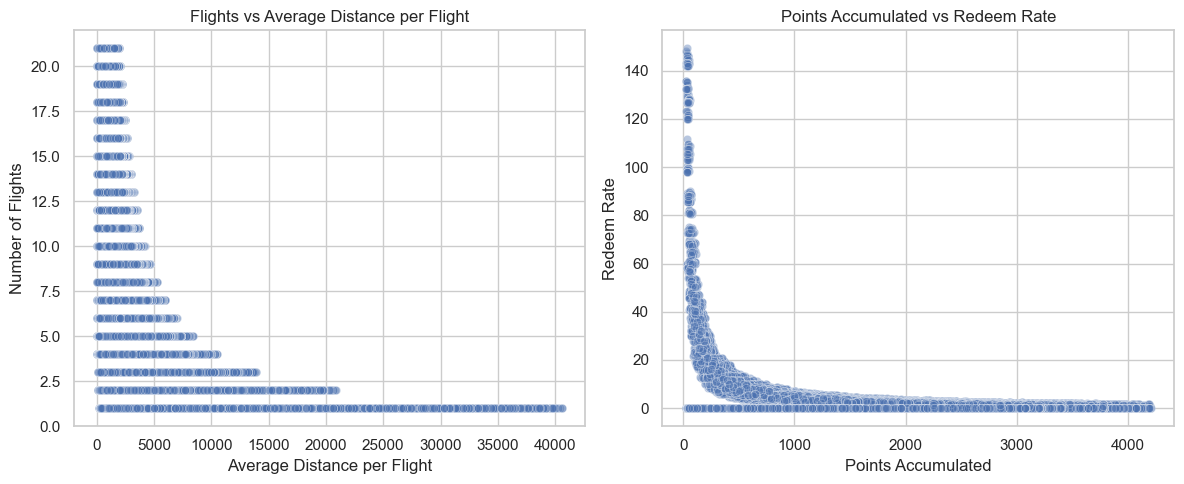

In [396]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter 1: AvgDistancePerFlight vs NumFlights
sns.scatterplot(data=flights, x='AvgDistancePerFlight', y='NumFlights',
                alpha=0.4, ax=axes[0])
axes[0].set_title('Flights vs Average Distance per Flight')
axes[0].set_xlabel('Average Distance per Flight')
axes[0].set_ylabel('Number of Flights')

# Scatter 2: PointsAccumulated vs RedeemRate
sns.scatterplot(data=flights, x='PointsAccumulated', y='RedeemRate',
                alpha=0.4, ax=axes[1])
axes[1].set_title('Points Accumulated vs Redeem Rate')
axes[1].set_xlabel('Points Accumulated')
axes[1].set_ylabel('Redeem Rate')

plt.tight_layout()
plt.show()

The first scatterplot shows an inverse relationship between AvgDistancePerFlight and NumFlights, supporting the idea that customers who fly frequently tend to take shorter routes. The second scatterplot reveals a decreasing trend between PointsAccumulated and RedeemRate — as customers accumulate more points, the proportion of those points being redeemed declines. This may indicate point-saving behavior or delayed redemption among loyal customers.

<a class="anchor" id="3rd-bullet">

### 2.5.4. Temporal and Seasonal Behavior
    
</a>



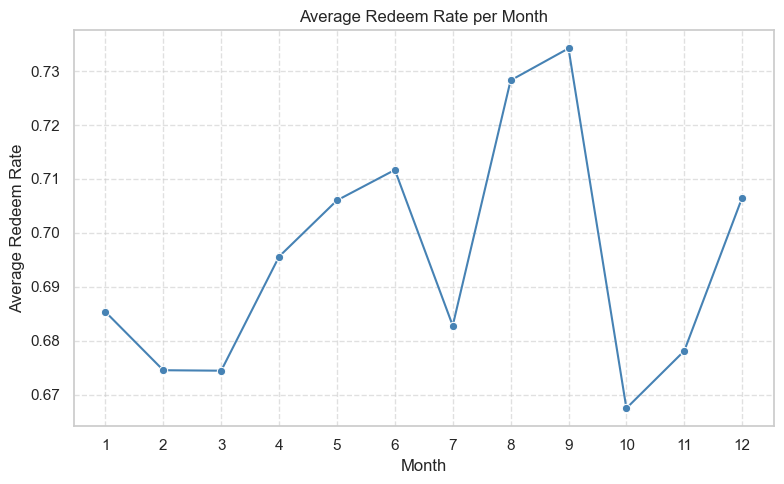

In [397]:
# Calculate the mean RedeemRate per Month
redeem_by_month = flights.groupby('Month')['RedeemRate'].mean().reset_index()

# Create the lineplot
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=redeem_by_month,
    x='Month',
    y='RedeemRate',
    marker='o',
    color='steelblue'
)

# Customize titles and labels
plt.title('Average Redeem Rate per Month')
plt.xlabel('Month')
plt.ylabel('Average Redeem Rate')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


The Average Redeem Rate per Month shows small monthly fluctuations, with slight peaks during mid-year months, possibly associated with holiday travel or promotional campaigns. 


<a class="anchor" id="3rd-bullet">

### 2.5.5. Interactions among Engineered Features
    
</a>


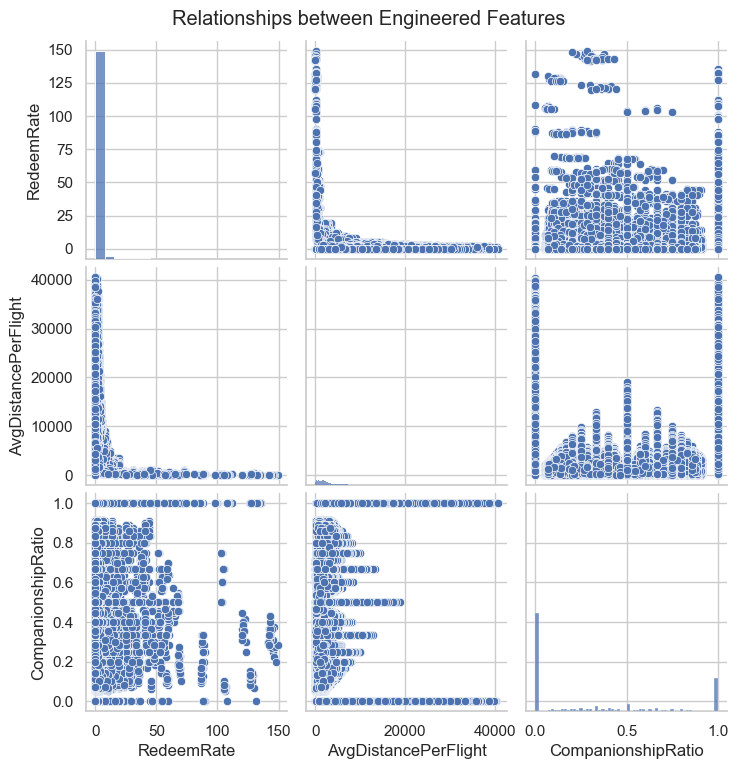

In [398]:
sns.pairplot(flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']])
plt.suptitle('Relationships between Engineered Features', y=1.02)
plt.show()

The pairplot allows a broader view of how the engineered features relate to each other. The plots confirm that most variables are weakly correlated, meaning they capture distinct aspects of customer behavior. 

<a class="anchor" id="3rd-bullet">

### 2.5.6. Treating Missing Values
</a>


Missing values in *RedeemRate*, *AvgDistancePerFlight*, and *CompanionshipRatio* occur logically for customers with no recorded flights or accumulated points in a given month.
Instead of treating these as errors, they were replaced with zeros, reflecting the absence of activity rather than missing information.
This approach ensures consistency with the variable ActiveMonth, which already identifies periods of inactivity.

In [399]:
flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']] = (
    flights[['RedeemRate', 'AvgDistancePerFlight', 'CompanionshipRatio']].fillna(0)
)


In [400]:
flights.isna().sum()
flights.isna().mean() * 100

Loyalty#                    0.0
Year                        0.0
Month                       0.0
YearMonthDate               0.0
NumFlights                  0.0
NumFlightsWithCompanions    0.0
DistanceKM                  0.0
PointsAccumulated           0.0
PointsRedeemed              0.0
DollarCostPointsRedeemed    0.0
ActiveMonth                 0.0
RedeemRate                  0.0
AvgDistancePerFlight        0.0
CompanionshipRatio          0.0
MonthSeason                 0.0
dtype: float64

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 3. Flights Dataset (After Aggregation)
    

    
</div>

<a class="anchor" id="3rd-bullet">

### 3.1. Creating The New Dataset
    
</a>

In [401]:
# create dataset equal to the flights dataset but instead of having multiple rows for each customer,
# we can only have one row for each customer

# i think we need to aggregate the rows in the flights dataset that refer to the same customer

# but we have to do this whitout removing the Month, Year, Date variables

In [402]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,ActiveMonth,RedeemRate,AvgDistancePerFlight,CompanionshipRatio,MonthSeason
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,1,0.000000,4692.000000,1.00,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,0.00,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,1,0.000000,1474.500000,0.30,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,1,1.221209,1644.437500,0.25,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,1,0.000000,2141.666667,0.00,Winter


In [403]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 602532 entries, 0 to 608435
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  602532 non-null  int64         
 1   Year                      602532 non-null  int64         
 2   Month                     602532 non-null  int64         
 3   YearMonthDate             602532 non-null  datetime64[ns]
 4   NumFlights                602532 non-null  int64         
 5   NumFlightsWithCompanions  602532 non-null  int64         
 6   DistanceKM                602532 non-null  float64       
 7   PointsAccumulated         602532 non-null  float64       
 8   PointsRedeemed            602532 non-null  float64       
 9   DollarCostPointsRedeemed  602532 non-null  float64       
 10  ActiveMonth               602532 non-null  int64         
 11  RedeemRate                602532 non-null  float64       
 12  AvgDist

**Variables Agregation**  
This aggregation step was performed to transform the dataset from a monthly flight-level structure into a customer-level summary, with one row per loyalty member. By grouping the data by customer and calculating totals (such as total flights, distance flown, and points accumulated) as well as averages (such as average distance per flight and average activity level), we obtain a compact and comprehensive view of each customer’s overall travel behavior. This allows for easier comparison between customers and supports further analysis of loyalty patterns, engagement, and flight activity intensity.

In [404]:
# Aggregate flights dataset to have one row per customer (Loyalty#)
# We calculate key totals, averages, and activity indicators

flights_agg = flights.groupby('Loyalty#').agg({
    'NumFlights': ['sum', 'mean'],
    'NumFlightsWithCompanions': ['sum', 'mean'],
    'DistanceKM': ['sum', 'mean'],
    'PointsAccumulated': ['sum', 'mean'],
    'PointsRedeemed': ['sum', 'mean'],
    'DollarCostPointsRedeemed': ['sum', 'mean'],
    'RedeemRate': 'mean',
    'AvgDistancePerFlight': 'mean',
    'CompanionshipRatio': 'mean',
    'ActiveMonth': 'sum',
}).reset_index()

# Simplify column names
flights_agg.columns = ['Loyalty#',
                       'TotalFlights', 'AvgFlightsPerMonth',
                       'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
                       'TotalDistanceKM', 'AvgDistanceKM',
                       'TotalPointsAccumulated', 'AvgPointsAccumulated',
                       'TotalPointsRedeemed', 'AvgPointsRedeemed',
                       'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed',
                       'AvgRedeemRate', 'AvgDistancePerFlight',
                       'AvgCompanionshipRatio',
                       'TotalActiveMonths']

# Quick check
flights_agg.head()


,Loyalty#,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,TotalActiveMonths
0,100018,231,6.416667,50,1.388889,530230.0,14728.611111,53014.30,1472.619444,20562.8,571.188889,201.9,5.608333,0.282897,2388.168953,0.192623,31
1,100102,248,6.888889,59,1.638889,339114.6,9419.850000,33903.96,941.776667,18760.6,521.127778,186.2,5.172222,0.627745,1074.373827,0.198539,25
2,100140,217,6.027778,54,1.500000,432030.8,12000.855556,43192.58,1199.793889,4896.0,136.000000,48.0,1.333333,0.080616,2480.593814,0.276175,28
3,100214,112,3.111111,20,0.555556,364601.7,10127.825000,36453.77,1012.604722,12908.6,358.572222,127.3,3.536111,1.315612,4431.372537,0.210317,21
4,100272,187,5.194444,53,1.472222,429630.5,11934.180556,42953.25,1193.145833,10891.4,302.538889,107.0,2.972222,0.155939,4527.014935,0.248248,25


**MonthsActive_PerYear**  
This step was implemented to replace the overall activity variable (TotalActiveMonths) with a more detailed year-by-year breakdown. By grouping the data by customer and year, we calculated the number of months each customer was active in 2019, 2020, and 2021. This approach provides a clearer view of the customer’s flight consistency and engagement across different years, allowing for more accurate temporal analysis of flying behavior.

In [405]:
#split the column TotalActiveMonths per year
flights_agg = flights_agg.drop(columns=['TotalActiveMonths'])

#created new variables that return the nº of months a customer flies in a determined year
activity = flights.groupby(['Loyalty#','Year'])['ActiveMonth'].sum().unstack().fillna(0)
activity.columns = ['monthsActive_2019','monthsActive_2020','monthsActive_2021']
flights_agg = flights_agg.merge(activity, on='Loyalty#', how='left')

flights_agg[['Loyalty#', 'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021']].head()

,Loyalty#,monthsActive_2019,monthsActive_2020,monthsActive_2021
0,100018,11,11,9
1,100102,8,8,9
2,100140,10,10,8
3,100214,7,7,7
4,100272,8,8,9


**Flights_PerSeason**  
This step was carried out to analyze customer flight behavior by season. By grouping the dataset by customer and season, we calculated the total number of flights each customer took during autumn, spring, summer, and winter. The resulting seasonal flight variables (*Flights_Autumn*, *Flights_Spring*, *Flights_Summer*, and *Flights_Winter*) allow for a clearer understanding of seasonal travel patterns and preferences, enabling comparisons of activity intensity across different times of the year.

In [406]:
flights_season = flights.groupby(['Loyalty#', 'MonthSeason'])['NumFlights'].sum().unstack(fill_value=0).reset_index()

# Rename columns to the desired format
flights_season = flights_season.rename(columns={
    'Autumn': 'Flights_Autumn',
    'Spring': 'Flights_Spring',
    'Summer': 'Flights_Summer',
    'Winter': 'Flights_Winter'
})

flights_agg = flights_agg.merge(flights_season, on='Loyalty#', how='left')

#check
flights_agg[['Loyalty#', 'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter']].head()

,Loyalty#,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter
0,100018,84,47,55,45
1,100102,77,62,49,60
2,100140,62,58,48,49
3,100214,48,3,18,43
4,100272,22,64,70,31


**Favorite Month and Season**  
This part of the analysis identifies each customer’s preferred period to fly. First, the total number of flights per season and per month was calculated, allowing us to determine for each customer their PeakSeason (the season with the highest flight activity) and PeakMonth (the month with the highest number of flights). These variables provide insight into individual travel preferences and seasonality patterns. Finally, the variable MonthMatchesSeason was created to verify whether the customer’s favorite month to fly belongs to their favorite season, enabling the identification of consistent or irregular travel behaviors across time.

In [407]:
season_totals = (
    flights.groupby(['Loyalty#', 'MonthSeason'], as_index=False)['NumFlights']
           .sum()
)

peak_season = (
    season_totals.loc[season_totals.groupby('Loyalty#')['NumFlights'].idxmax(),
                      ['Loyalty#', 'MonthSeason']]
    .rename(columns={'MonthSeason': 'PeakSeason'})
)

flights['Month'] = flights['Month'].astype(int)

month_totals = (
    flights.groupby(['Loyalty#', 'Month'], as_index=False)['NumFlights']
           .sum()
)

peak_month = (
    month_totals.loc[month_totals.groupby('Loyalty#')['NumFlights'].idxmax(),
                     ['Loyalty#', 'Month']]
    .rename(columns={'Month': 'PeakMonth'})
)


flights_agg = (
    flights_agg.merge(peak_season, on='Loyalty#', how='left')
               .merge(peak_month, on='Loyalty#', how='left')
)


#check if the favorite month to fly corresponds to the favorite season to fly
def match_season(row):
    if row['PeakSeason'] == 'Winter' and row['PeakMonth'] in [12, 1, 2]:
        return 1
    elif row['PeakSeason'] == 'Spring' and row['PeakMonth'] in [3, 4, 5]:
        return 1
    elif row['PeakSeason'] == 'Summer' and row['PeakMonth'] in [6, 7, 8]:
        return 1
    elif row['PeakSeason'] == 'Autumn' and row['PeakMonth'] in [9, 10, 11]:
        return 1
    else:
        return 0

flights_agg['MonthMatchesSeason'] = flights_agg.apply(match_season, axis=1)

flights_agg[['Loyalty#', 'PeakSeason', 'PeakMonth', 'MonthMatchesSeason']].head()

,Loyalty#,PeakSeason,PeakMonth,MonthMatchesSeason
0,100018,Autumn,11,1
1,100102,Autumn,12,0
2,100140,Autumn,9,1
3,100214,Autumn,12,0
4,100272,Summer,6,1


**Flight Activity per Year**  
This step was performed to measure each customer’s flight activity across different years. By aggregating the total number of flights per customer and per year, the code identifies whether the customer flew in 2019, 2020, or 2021. Binary variables were then created for each year, taking the value 1 if the customer flew and 0 otherwise. Additionally, the variable YearsActive was introduced to indicate the total number of years (from 0 to 3) in which the customer had flight activity. This provides a clear indicator of the customer’s temporal consistency and engagement with the airline over time.

In [408]:
#Determine if the customer flew in each year (2019, 2020, 2021)
#We check whether total flights in that year > 0

#Aggregate total flights per customer and year
year_flights = flights.groupby(['Loyalty#', 'Year'], as_index=False)['NumFlights'].sum()

#Pivot to create one column per year
year_flights_pivot = year_flights.pivot(index='Loyalty#', columns='Year', values='NumFlights').fillna(0).reset_index()

#Create binary columns for each year
year_flights_pivot['Flew_2019'] = (year_flights_pivot.get(2019, 0) > 0).astype(int)
year_flights_pivot['Flew_2020'] = (year_flights_pivot.get(2020, 0) > 0).astype(int)
year_flights_pivot['Flew_2021'] = (year_flights_pivot.get(2021, 0) > 0).astype(int)

#Count in how many years the customer flew
year_flights_pivot['YearsActive'] = (
    year_flights_pivot[['Flew_2019', 'Flew_2020', 'Flew_2021']].sum(axis=1)
)

#Keep only the relevant columns
year_flights_pivot = year_flights_pivot[['Loyalty#', 'Flew_2019', 'Flew_2020', 'Flew_2021', 'YearsActive']]

#Merge with the aggregated dataset
flights_agg = flights_agg.merge(year_flights_pivot, on='Loyalty#', how='left')

#Quick check
flights_agg[['Loyalty#', 'Flew_2019', 'Flew_2020', 'Flew_2021', 'YearsActive']].head()


,Loyalty#,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,100018,1,1,1,3
1,100102,1,1,1,3
2,100140,1,1,1,3
3,100214,1,1,1,3
4,100272,1,1,1,3


<a class="anchor" id="3rd-bullet">

### 3.2. Exploratory Data Analysis
    
</a>

In [409]:
pd.set_option('display.max_columns', None)
flights_agg.head()

,Loyalty#,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,100018,231,6.416667,50,1.388889,530230.0,14728.611111,53014.30,1472.619444,20562.8,571.188889,201.9,5.608333,0.282897,2388.168953,0.192623,11,11,9,84,47,55,45,Autumn,11,1,1,1,1,3
1,100102,248,6.888889,59,1.638889,339114.6,9419.850000,33903.96,941.776667,18760.6,521.127778,186.2,5.172222,0.627745,1074.373827,0.198539,8,8,9,77,62,49,60,Autumn,12,0,1,1,1,3
2,100140,217,6.027778,54,1.500000,432030.8,12000.855556,43192.58,1199.793889,4896.0,136.000000,48.0,1.333333,0.080616,2480.593814,0.276175,10,10,8,62,58,48,49,Autumn,9,1,1,1,1,3
3,100214,112,3.111111,20,0.555556,364601.7,10127.825000,36453.77,1012.604722,12908.6,358.572222,127.3,3.536111,1.315612,4431.372537,0.210317,7,7,7,48,3,18,43,Autumn,12,0,1,1,1,3
4,100272,187,5.194444,53,1.472222,429630.5,11934.180556,42953.25,1193.145833,10891.4,302.538889,107.0,2.972222,0.155939,4527.014935,0.248248,8,8,9,22,64,70,31,Summer,6,1,1,1,1,3


In [410]:
flights_agg.shape

(16737, 30)

In [411]:
flights_agg.columns

Index(['Loyalty#', 'TotalFlights', 'AvgFlightsPerMonth',
       'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
       'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated',
       'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed',
       'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate',
       'AvgDistancePerFlight', 'AvgCompanionshipRatio', 'monthsActive_2019',
       'monthsActive_2020', 'monthsActive_2021', 'Flights_Autumn',
       'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'PeakSeason',
       'PeakMonth', 'MonthMatchesSeason', 'Flew_2019', 'Flew_2020',
       'Flew_2021', 'YearsActive'],
      dtype='object')

In [412]:
flights_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Loyalty#                    16737 non-null  int64  
 1   TotalFlights                16737 non-null  int64  
 2   AvgFlightsPerMonth          16737 non-null  float64
 3   TotalFlightsWithCompanions  16737 non-null  int64  
 4   AvgFlightsWithCompanions    16737 non-null  float64
 5   TotalDistanceKM             16737 non-null  float64
 6   AvgDistanceKM               16737 non-null  float64
 7   TotalPointsAccumulated      16737 non-null  float64
 8   AvgPointsAccumulated        16737 non-null  float64
 9   TotalPointsRedeemed         16737 non-null  float64
 10  AvgPointsRedeemed           16737 non-null  float64
 11  TotalDollarCostRedeemed     16737 non-null  float64
 12  AvgDollarCostRedeemed       16737 non-null  float64
 13  AvgRedeemRate               167

In [413]:
flights_agg.dtypes

Loyalty#                        int64
TotalFlights                    int64
AvgFlightsPerMonth            float64
TotalFlightsWithCompanions      int64
AvgFlightsWithCompanions      float64
TotalDistanceKM               float64
AvgDistanceKM                 float64
TotalPointsAccumulated        float64
AvgPointsAccumulated          float64
TotalPointsRedeemed           float64
AvgPointsRedeemed             float64
TotalDollarCostRedeemed       float64
AvgDollarCostRedeemed         float64
AvgRedeemRate                 float64
AvgDistancePerFlight          float64
AvgCompanionshipRatio         float64
monthsActive_2019               int64
monthsActive_2020               int64
monthsActive_2021               int64
Flights_Autumn                  int64
Flights_Spring                  int64
Flights_Summer                  int64
Flights_Winter                  int64
PeakSeason                     object
PeakMonth                       int64
MonthMatchesSeason              int64
Flew_2019   

- Variable*PeakSeason* must be categorical
- Transform Binary Variables into int8 ?? what does this means??

In [414]:
id_col = ['Loyalty#']
categorical_cols = ['PeakSeason']
binary_cols = ['MonthMatchesSeason', 'Flew_2019', 'Flew_2020', 'Flew_2021']
numeric_cols = [col for col in flights_agg.columns if col not in id_col + categorical_cols + binary_cols]

In [415]:
flights_agg[numeric_cols].describe()

,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakMonth,YearsActive
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,141.118898,3.919969,35.574954,0.988193,286387.061188,7955.196144,28633.064152,795.362893,8488.983384,235.805094,83.891289,2.330314,0.354999,1697.956332,0.157836,5.711418,5.711418,6.598375,32.653761,32.857083,45.049770,30.558284,6.882297,2.410289
std,80.750753,2.243076,23.409824,0.650273,163685.100797,4546.808355,16365.767353,454.604649,8689.653565,241.379266,85.934126,2.387059,0.711980,1137.568933,0.103703,3.787592,3.787592,3.303540,21.951086,24.703764,31.782945,21.636966,3.243081,1.033195
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,70.000000,1.944444,16.000000,0.444444,143122.000000,3975.611111,14309.000000,397.472222,0.000000,0.000000,0.000000,0.000000,0.000000,768.806354,0.069444,1.000000,1.000000,5.000000,15.000000,11.000000,18.000000,12.000000,5.000000,2.000000
50%,163.000000,4.527778,37.000000,1.027778,330830.200000,9189.727778,33075.520000,918.764444,6469.500000,179.708333,64.000000,1.777778,0.128863,1738.427182,0.163678,7.000000,7.000000,8.000000,33.000000,33.000000,46.000000,31.000000,7.000000,3.000000
75%,203.000000,5.638889,53.000000,1.472222,412907.500000,11469.652778,41283.050000,1146.751389,13516.000000,375.444444,133.400000,3.705556,0.390621,2449.202071,0.233951,9.000000,9.000000,9.000000,49.000000,52.000000,69.000000,46.000000,9.000000,3.000000
max,349.000000,9.694444,124.000000,3.444444,712729.600000,19798.044444,71264.460000,1979.568333,57527.800000,1597.994444,572.000000,15.888889,10.782201,6777.859697,0.554235,12.000000,12.000000,12.000000,107.000000,115.000000,147.000000,104.000000,12.000000,3.000000


The descriptive statistics summarize the main characteristics of the aggregated flight dataset.
Overall, customers took an average of 141 flights, traveling about 286,000 km in total, which corresponds to roughly 7,950 km per flight.
The number of flights per customer varies substantially (from 0 to 349), indicating different engagement levels with the loyalty program.

On average, customers earned around 28,600 points and redeemed approximately 8,500 points, showing that redemption behavior is less frequent than accumulation.
The average redeem rate (0.35) also supports this pattern, suggesting that many customers accumulate points without using them regularly.

Seasonally, activity is relatively balanced, with a slightly higher concentration of flights during the summer months (≈45 flights).
Most customers were active for 2 to 3 years between 2019 and 2021, with an average of around 6 active months per year.

These results confirm a heterogeneous customer base, with a mix of highly frequent flyers and less active participants, and reveal distinct temporal and seasonal travel patterns that may later influence the clustering analysis.

In [416]:
flights_agg['PeakSeason'].value_counts(normalize=True)
flights_agg[binary_cols].mean()

MonthMatchesSeason    0.645396
Flew_2019             0.766744
Flew_2020             0.766744
Flew_2021             0.876800
dtype: float64

The categorical and binary variables provide additional insights into customers’ flying behavior.
Approximately 65% of customers have their favorite month of travel matching their favorite season, indicating consistent seasonal flying preferences.
Regarding yearly activity, around 77% of customers flew in both 2019 and 2020, and nearly 88% remained active in 2021, suggesting strong program engagement and customer retention over time.
These proportions confirm that most loyalty members are recurrent travelers with stable travel patterns across the analyzed years.

<a class="anchor" id="3rd-bullet">

### 3.2.1. Checking For Missing Values
    
</a>

In [417]:
flights_agg.isna().sum()

Loyalty#                      0
TotalFlights                  0
AvgFlightsPerMonth            0
TotalFlightsWithCompanions    0
AvgFlightsWithCompanions      0
TotalDistanceKM               0
AvgDistanceKM                 0
TotalPointsAccumulated        0
AvgPointsAccumulated          0
TotalPointsRedeemed           0
AvgPointsRedeemed             0
TotalDollarCostRedeemed       0
AvgDollarCostRedeemed         0
AvgRedeemRate                 0
AvgDistancePerFlight          0
AvgCompanionshipRatio         0
monthsActive_2019             0
monthsActive_2020             0
monthsActive_2021             0
Flights_Autumn                0
Flights_Spring                0
Flights_Summer                0
Flights_Winter                0
PeakSeason                    0
PeakMonth                     0
MonthMatchesSeason            0
Flew_2019                     0
Flew_2020                     0
Flew_2021                     0
YearsActive                   0
dtype: int64

- There is no missing values

<a class="anchor" id="3rd-bullet">

### 3.2.2. Checking For Duplicated Values
    
</a>

In [418]:
flights_agg.duplicated().sum()

np.int64(0)

In [419]:
flights_agg['Loyalty#'].duplicated().sum()

np.int64(0)

<a class="anchor" id="3rd-bullet">

### 3.3. Initial Data Preparation
    
</a>

In [420]:
# Deleting variables that aren't relevant (probably won't be necessary), converting types that might  
# be wrong, etc

Binary variables were converted from int64 to int8 to optimize memory usage. Since these columns only contain two possible values (0 and 1), using 64-bit integers is unnecessary and inefficient. Changing the data type to int8 significantly reduces memory consumption without affecting data accuracy or computational performance.

In [421]:
flights_agg['PeakSeason'] = flights_agg['PeakSeason'].astype('category')
flights_agg[binary_cols] = flights_agg[binary_cols].astype('int8')

flights_agg.dtypes

Loyalty#                         int64
TotalFlights                     int64
AvgFlightsPerMonth             float64
TotalFlightsWithCompanions       int64
AvgFlightsWithCompanions       float64
TotalDistanceKM                float64
AvgDistanceKM                  float64
TotalPointsAccumulated         float64
AvgPointsAccumulated           float64
TotalPointsRedeemed            float64
AvgPointsRedeemed              float64
TotalDollarCostRedeemed        float64
AvgDollarCostRedeemed          float64
AvgRedeemRate                  float64
AvgDistancePerFlight           float64
AvgCompanionshipRatio          float64
monthsActive_2019                int64
monthsActive_2020                int64
monthsActive_2021                int64
Flights_Autumn                   int64
Flights_Spring                   int64
Flights_Summer                   int64
Flights_Winter                   int64
PeakSeason                    category
PeakMonth                        int64
MonthMatchesSeason       

<a class="anchor" id="3rd-bullet">

### 3.3.1. Checking for inconsistencies
    
</a>

- Check if total points redeemed is higher than total points accumulated

In [481]:
# Count how many rows have more redeemed points than accumulated
invalid_points = flights_agg[flights_agg['TotalPointsRedeemed'] > flights_agg['TotalPointsAccumulated']]

# Print summary
print(f"Number of inconsistent rows: {len(invalid_points)}")
print(f"Percentage of inconsistencies: {len(invalid_points) / len(flights_agg) * 100:.2f}%")

# Optionally display a few examples
display(invalid_points[['Loyalty#', 'TotalPointsAccumulated', 'TotalPointsRedeemed']].head(10))

Number of inconsistent rows: 462
Percentage of inconsistencies: 2.76%


,Loyalty#,TotalPointsAccumulated,TotalPointsRedeemed
81,103975,5457.00,9014.0
120,106444,12108.00,12947.0
170,108857,8036.99,10549.9
174,109023,21905.53,25591.1
299,116238,6771.00,6798.0
308,116897,2664.00,10266.0
389,121236,10479.94,15830.8
396,121751,2828.00,3049.0
403,122020,42695.04,48555.3
409,122283,21994.82,24038.8


We found 462 records (2.76%) where TotalPointsRedeemed exceeds TotalPointsAccumulated.
This situation is logically inconsistent, since customers cannot redeem more points than they have previously earned.

**Possible causes include:**  

- Data aggregation errors – for example, if monthly data were summed incorrectly, causing both accumulated and redeemed points to be added up multiple times.

- Timing mismatches – some redemptions may have been recorded before the corresponding accumulation was fully registered in the system.

- Duplicated or incomplete source transactions – particularly if the aggregation process did not account for partial or overlapping records.

**Recommended approach:**  

Before making any automatic correction, it is important to flag these inconsistencies and treat them as potential data quality issues.
Rather than immediately modifying the raw values, we can conceptually apply a logical upper bound — meaning that, for interpretation and modeling, TotalPointsRedeemed should never exceed TotalPointsAccumulated.

This “upper cap” acts as a conceptual constraint, ensuring that analytical results (such as loyalty segmentation, redemption efficiency, or customer value estimation) are not distorted by impossible values.

**The key idea is:**

Redemptions can be equal to or less than total accumulated points, but never higher.

In further stages, depending on the analytical goal:

- We might replace those values with the maximum valid limit (the accumulated total),

- or exclude those records entirely if their proportion or impact is significant.

Either way, acknowledging and documenting this logical boundary ensures that any subsequent analysis remains internally consistent and reliable.

<a class="anchor" id="3rd-bullet">

#### Splitting the data
    
</a>

In [422]:
# Group variables by analytical category
flights_vars = {
    "Flight_Activity": [
        'TotalFlights', 'AvgFlightsPerMonth',
        'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
        'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated',
        'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed',
        'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate',
        'AvgDistancePerFlight', 'AvgCompanionshipRatio'
    ],
    
    "Months_Active": [
        'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021'
    ],
    
    "Seasonal_Flights": [
        'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter'
    ],
    
    "Season_Peak": [
        'PeakSeason', 'PeakMonth'
    ],
    
    "Season_Match_Flew": [
        'MonthMatchesSeason', 'Flew_2019', 'Flew_2020', 'Flew_2021'
    ],
    
    "Years_Active": [
        'YearsActive'
    ]
}


<a class="anchor" id="3rd-bullet">

### 3.4. Visual Exploration
    
</a>

<a class="anchor" id="3rd-bullet">

### 3.4.1. Visual Analysis Of The Data Per Split
    
</a>

<a class="anchor" id="3rd-bullet">

#### Flights Activity
    
</a>


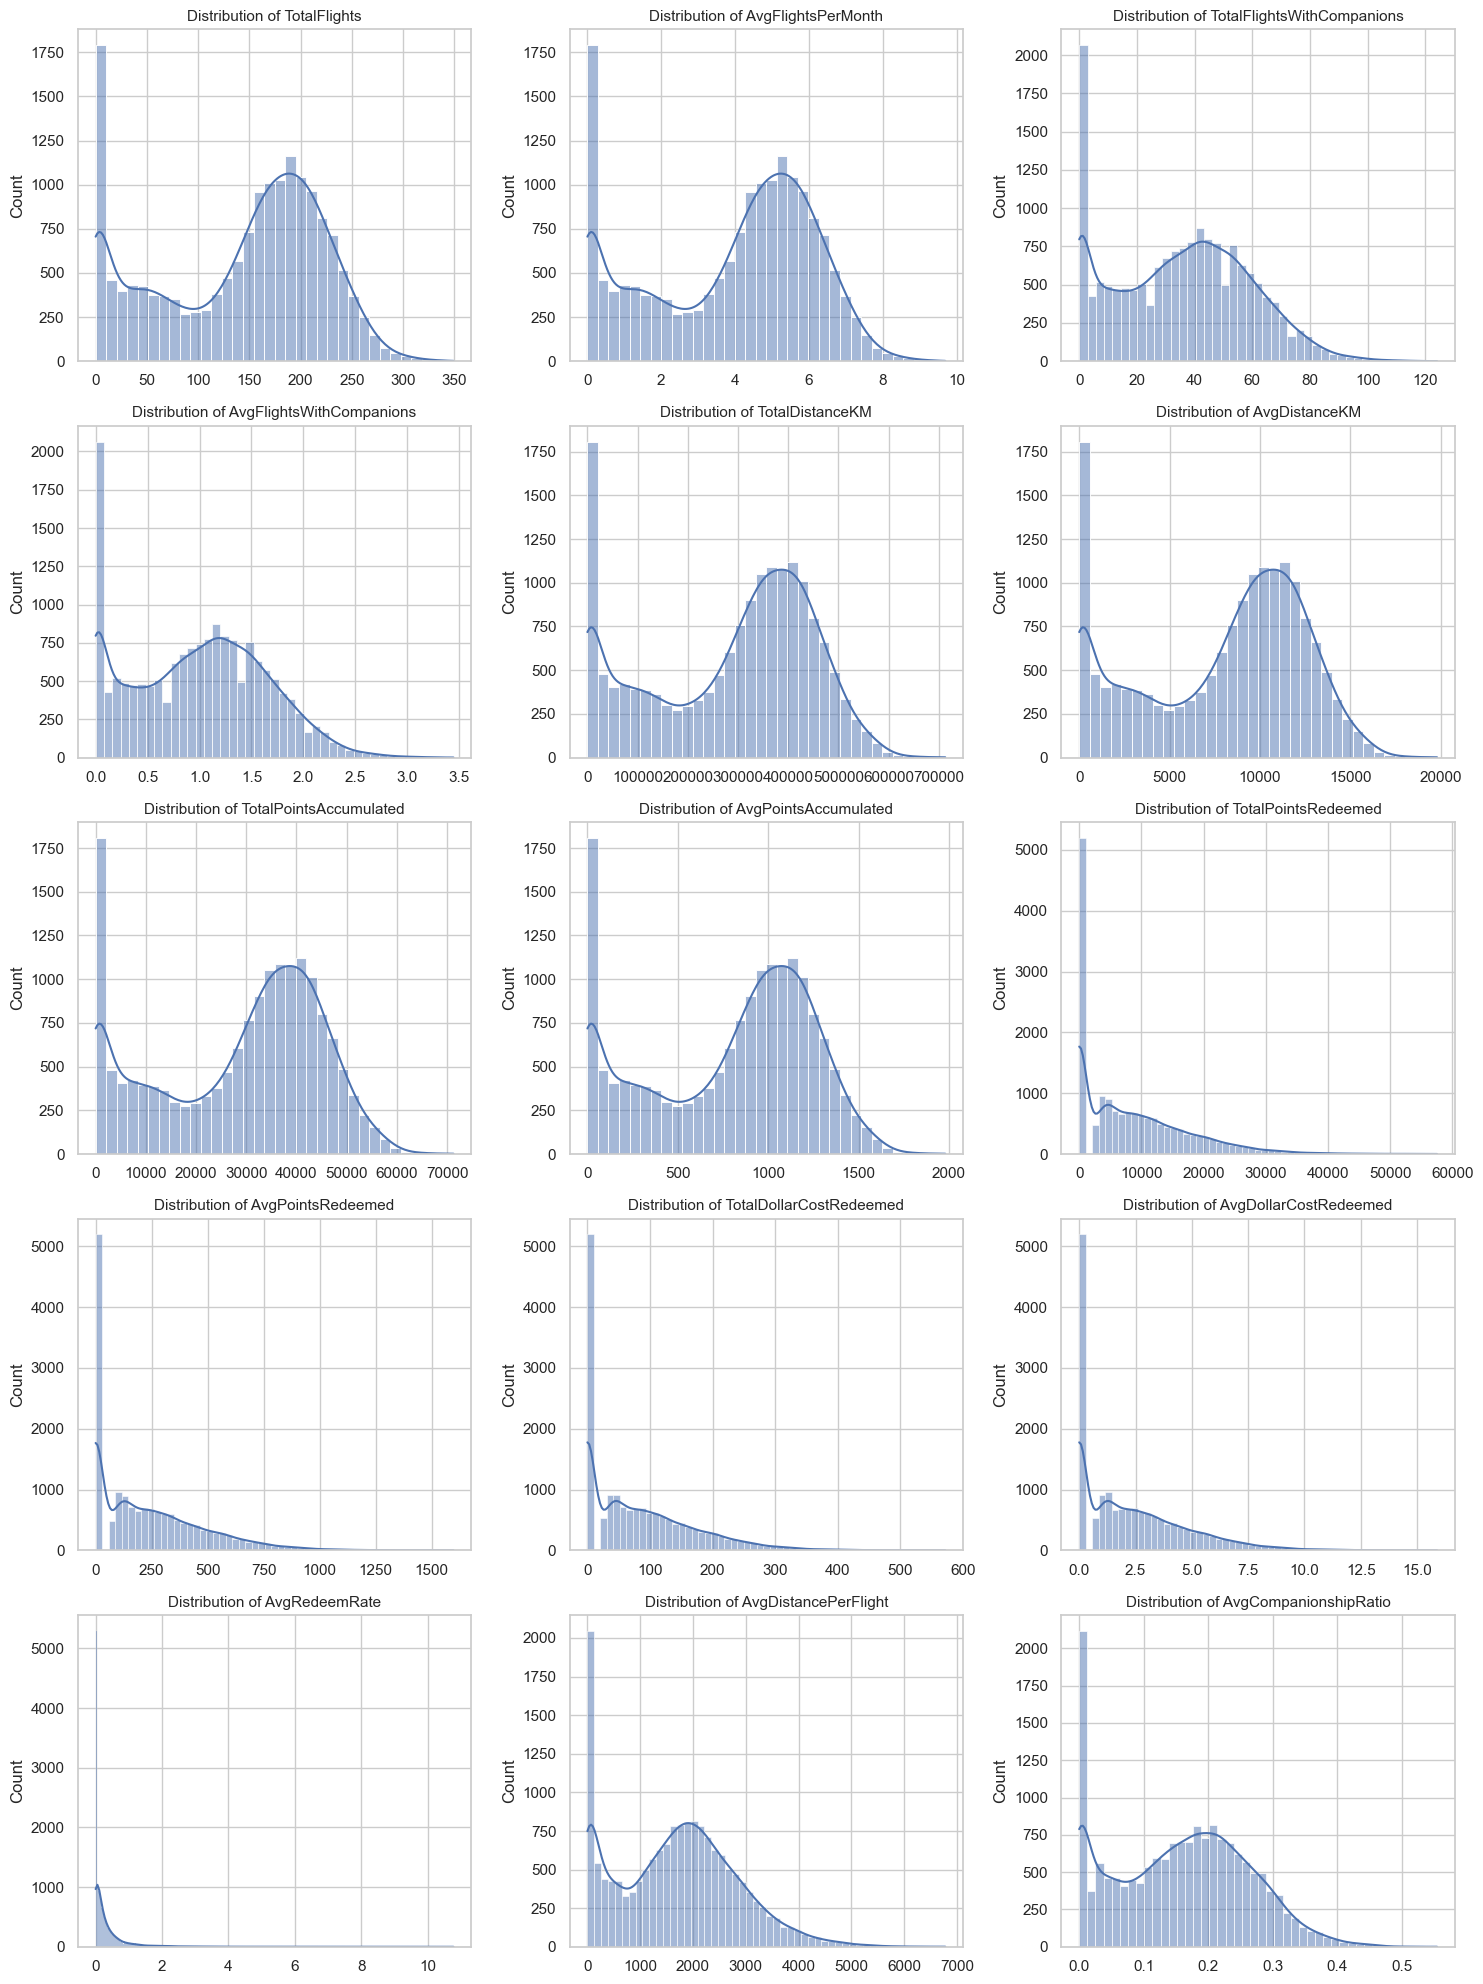

In [423]:
# Select the variables from the Flight_Activity group
cols = flights_vars["Flight_Activity"]

# Calculate grid size (3 per row)
n = len(cols)
rows = math.ceil(n / 3)

# Create subplots
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

# Plot each histogram
for i, c in enumerate(cols):
    sns.histplot(flights_agg[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {c}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplots if the last row is not full
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

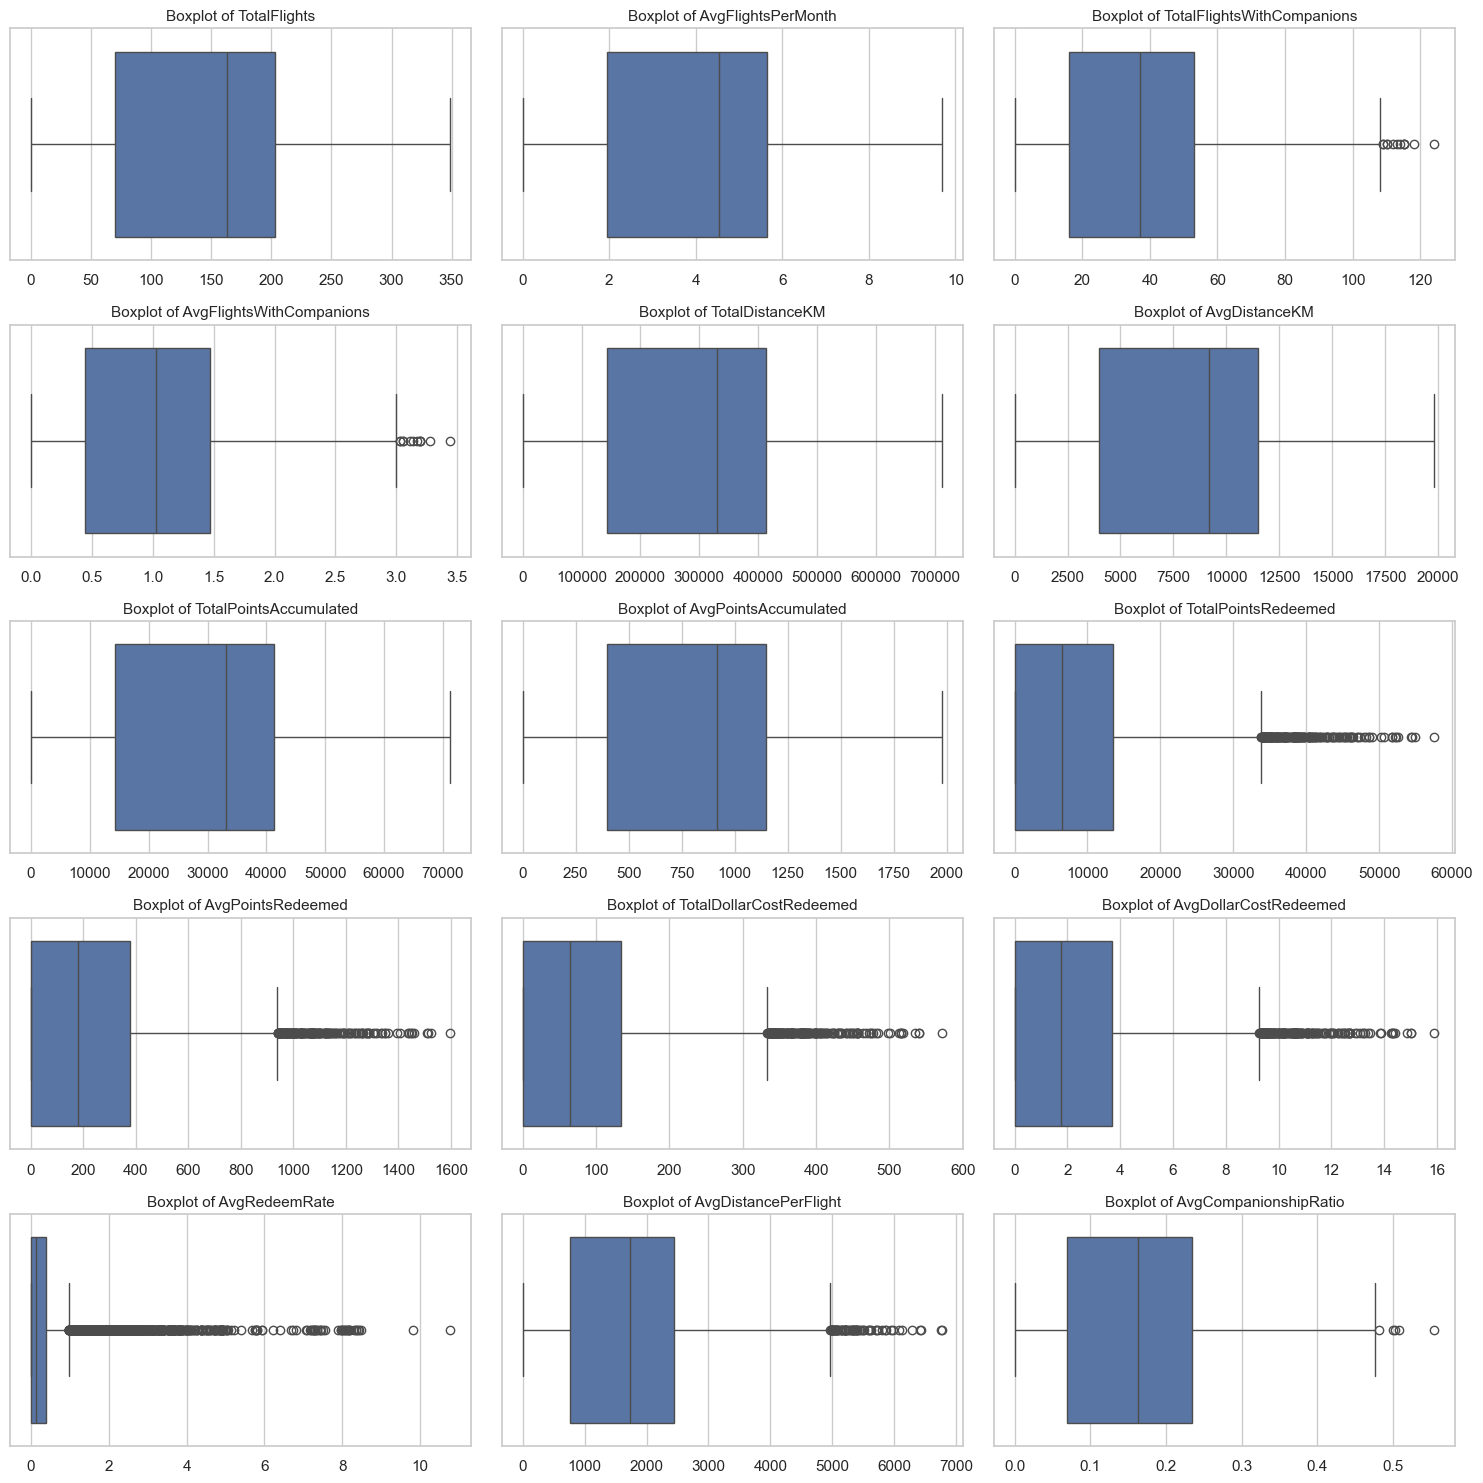

In [424]:
# Select variables from the Flight_Activity group
cols = flights_vars["Flight_Activity"]

# Calculate grid size (3 per row)
n = len(cols)
rows = math.ceil(n / 3)

# Create subplots
fig, axes = plt.subplots(rows, 3, figsize=(15, 3 * rows))
axes = axes.flatten()

# Plot each boxplot
for i, c in enumerate(cols):
    sns.boxplot(x=flights_agg[c], ax=axes[i])
    axes[i].set_title(f"Boxplot of {c}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots if the last row is not full
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


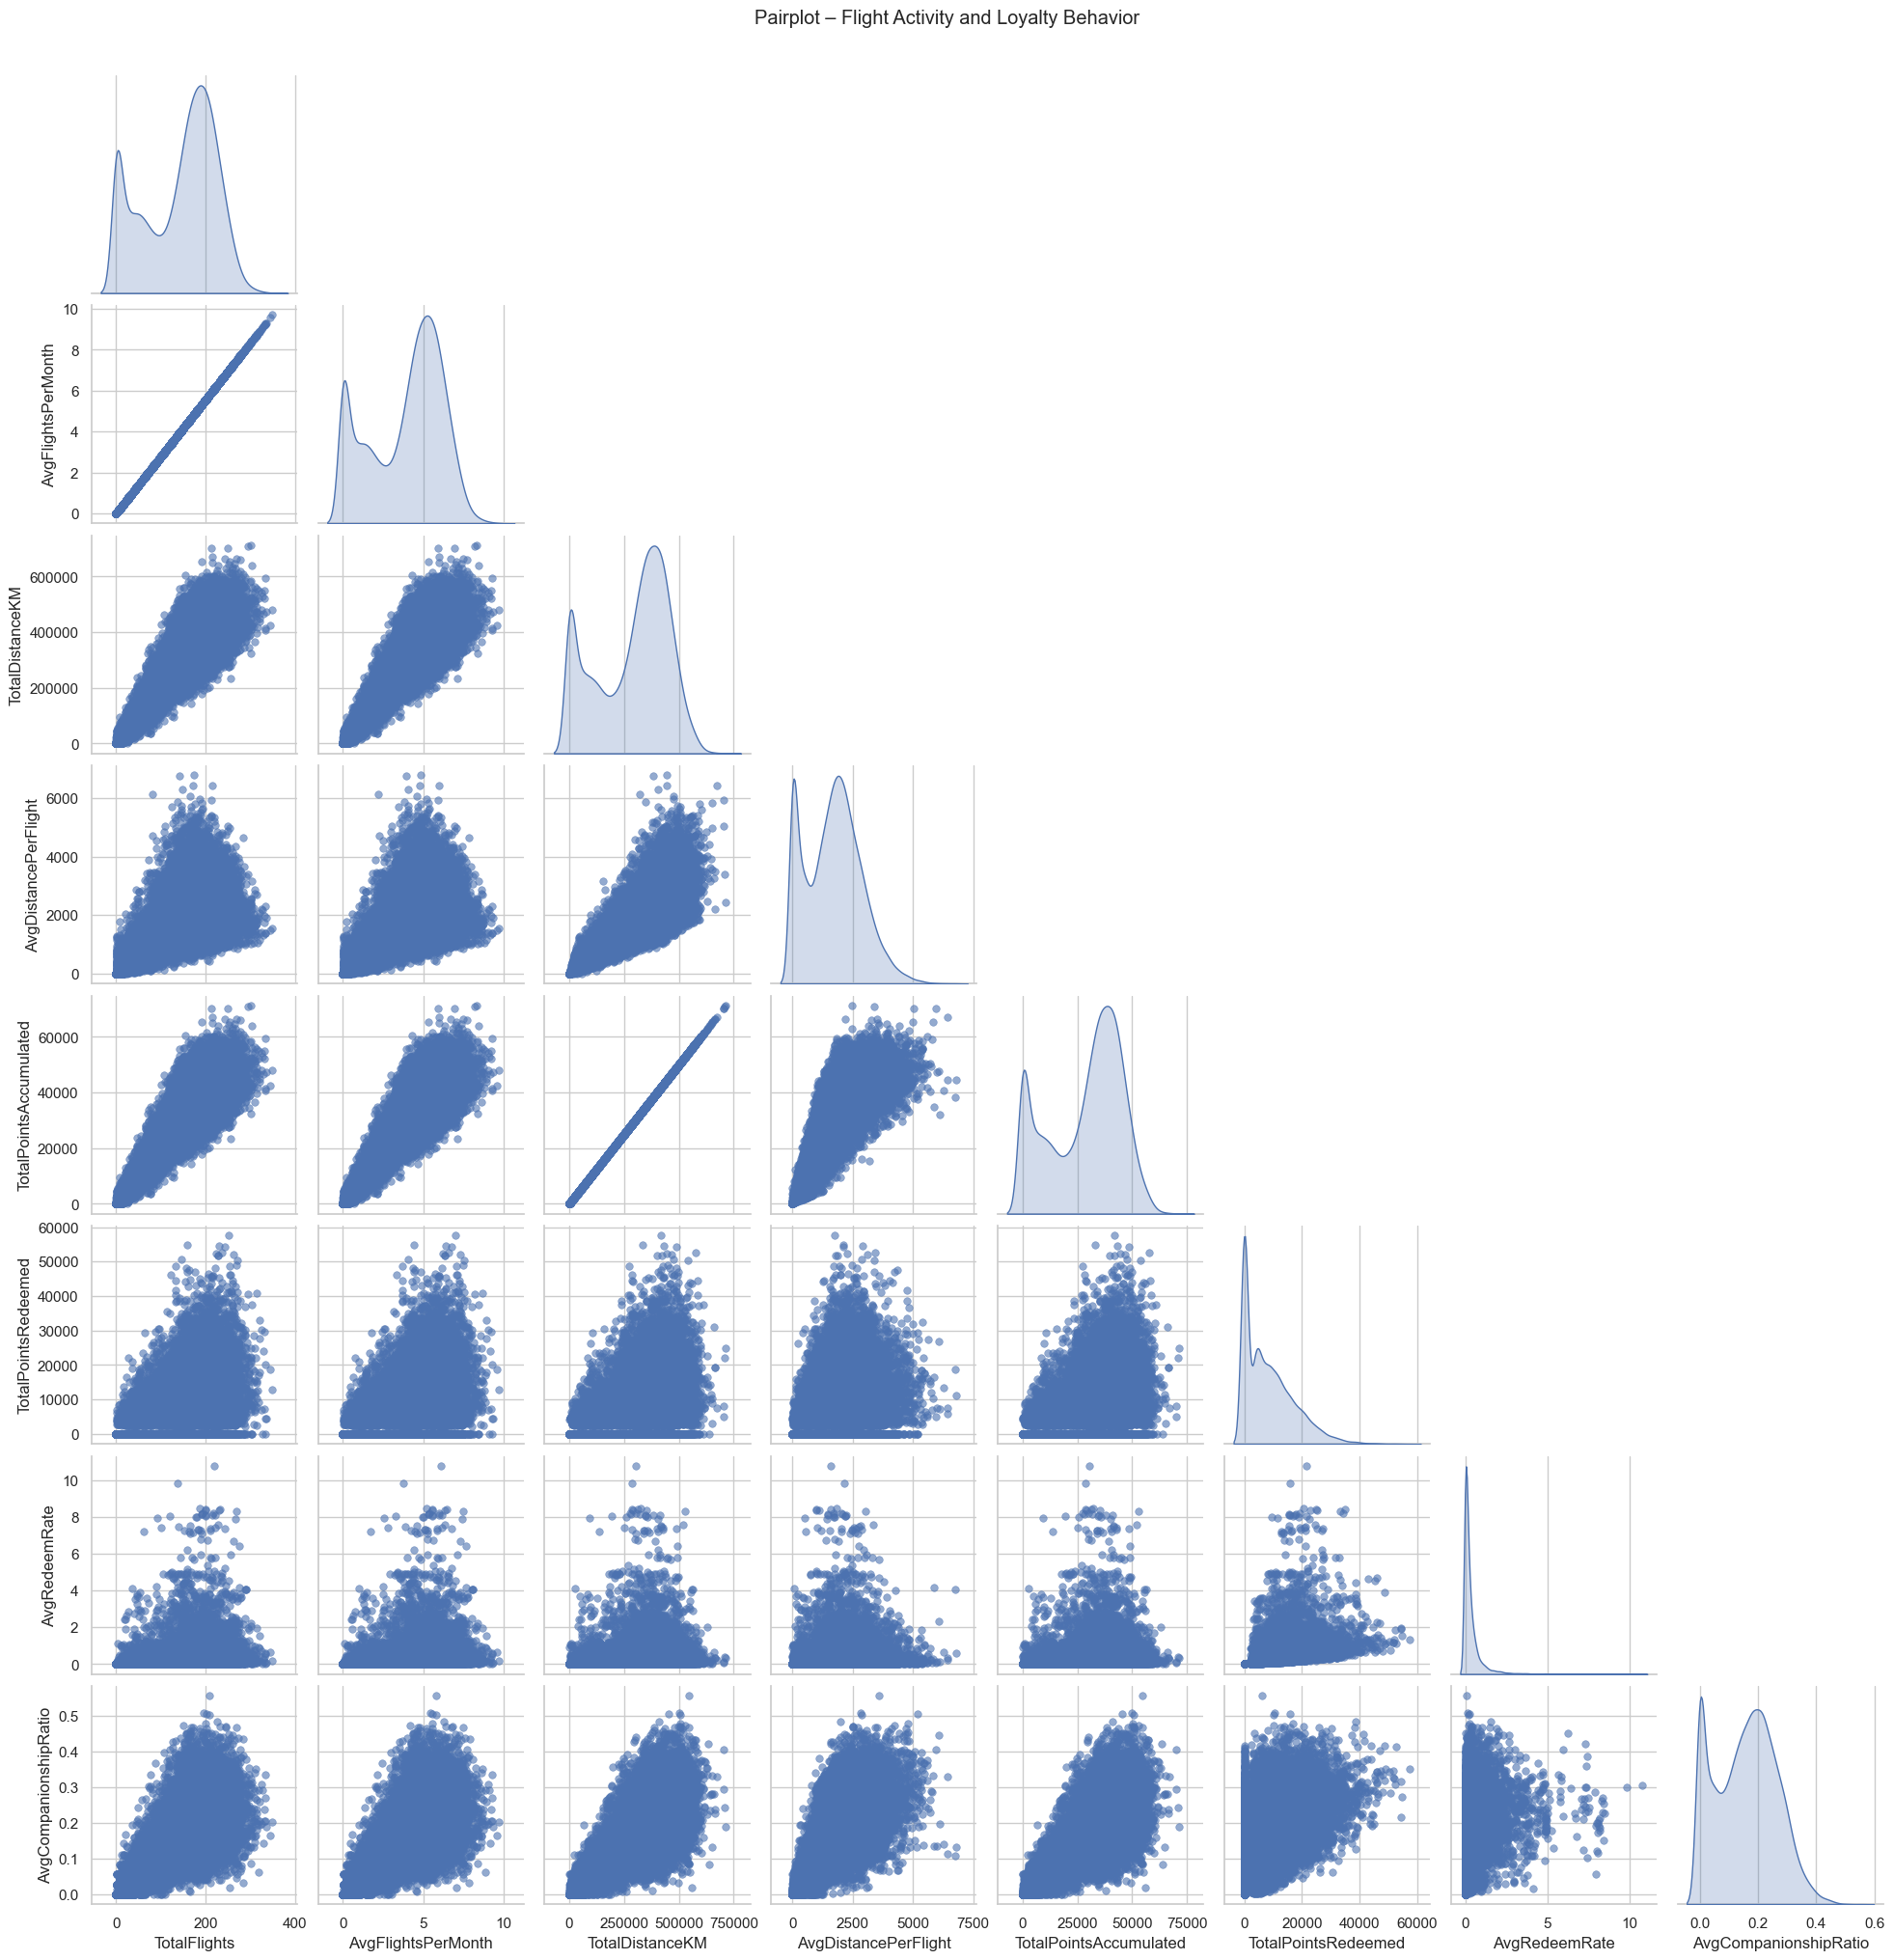

In [425]:
pair_vars = [
    'TotalFlights', 'AvgFlightsPerMonth', 'TotalDistanceKM', 'AvgDistancePerFlight',
    'TotalPointsAccumulated', 'TotalPointsRedeemed', 'AvgRedeemRate',
    'AvgCompanionshipRatio'
]

sns.pairplot(
    flights_agg[pair_vars],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': None}
)
plt.suptitle("Pairplot – Flight Activity and Loyalty Behavior", y=1.02)
plt.show()

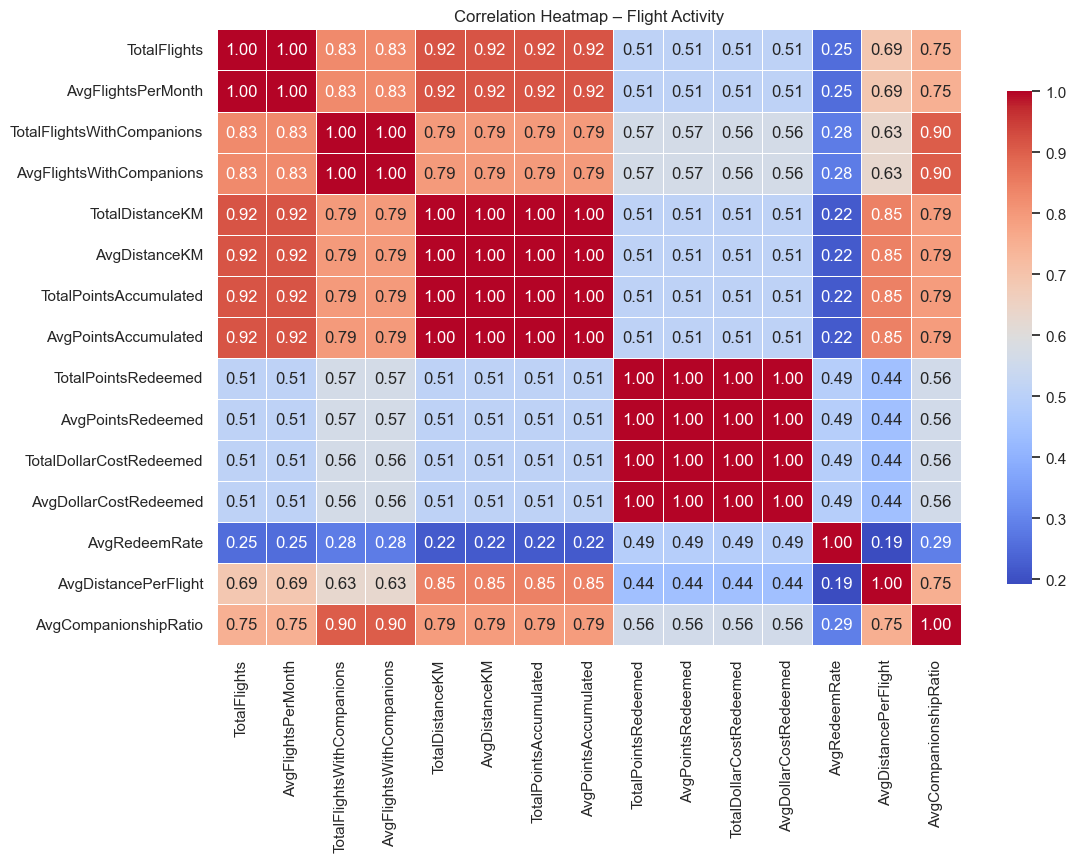

In [426]:
plt.figure(figsize=(12, 8))
corr_flight = flights_agg[flights_vars["Flight_Activity"]].corr()
sns.heatmap(
    corr_flight,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap – Flight Activity")
plt.show()

<a class="anchor" id="3rd-bullet">

#### Months Active
    
</a>

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2220840395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette="Blues", ax=axes[i])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2220840395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette="Blues", ax=axes[i])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2220840395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette="Blues", ax=axes[i])


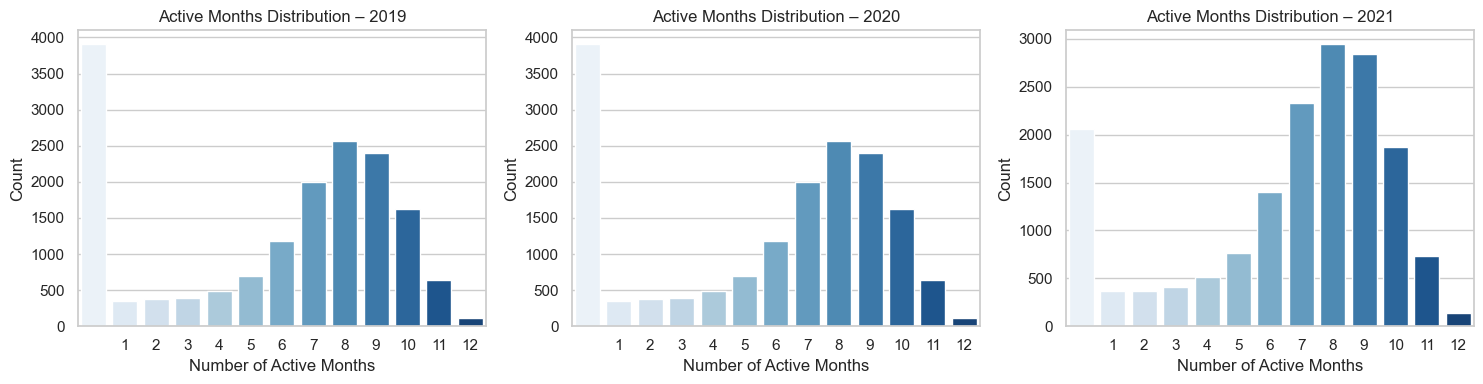

In [427]:
cols = flights_vars["Months_Active"]
n = len(cols)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, c in enumerate(cols):
    sns.countplot(x=flights_agg[c], palette="Blues", ax=axes[i])
    axes[i].set_title(f"Active Months Distribution – {c.split('_')[1]}")
    axes[i].set_xlabel("Number of Active Months")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks(range(1, 13))

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


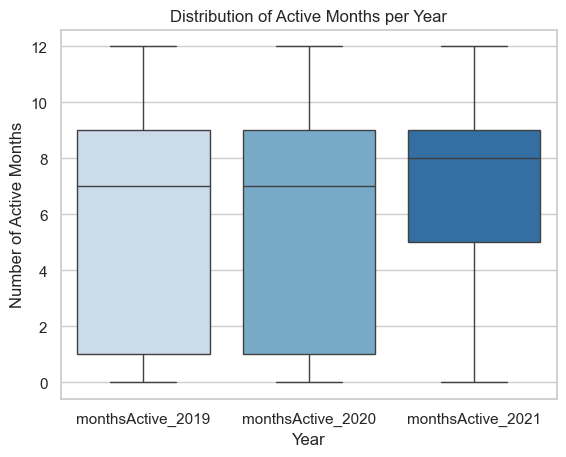

In [428]:
sns.boxplot(data=flights_agg[cols], palette="Blues")
plt.title("Distribution of Active Months per Year")
plt.xlabel("Year")
plt.ylabel("Number of Active Months")
plt.show()


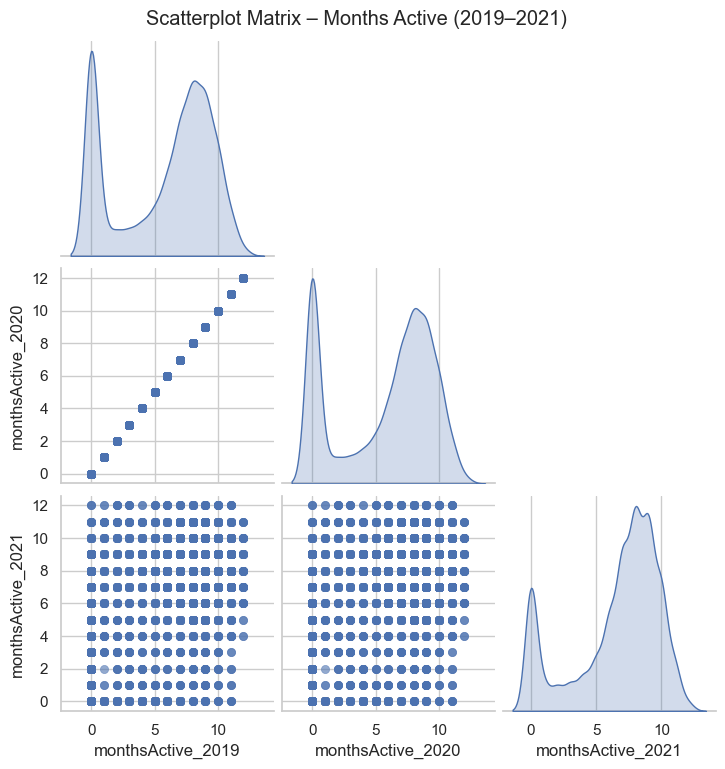

In [429]:
sns.pairplot(
    flights_agg[flights_vars["Months_Active"]],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': None}
)
plt.suptitle("Scatterplot Matrix – Months Active (2019–2021)", y=1.02)
plt.show()

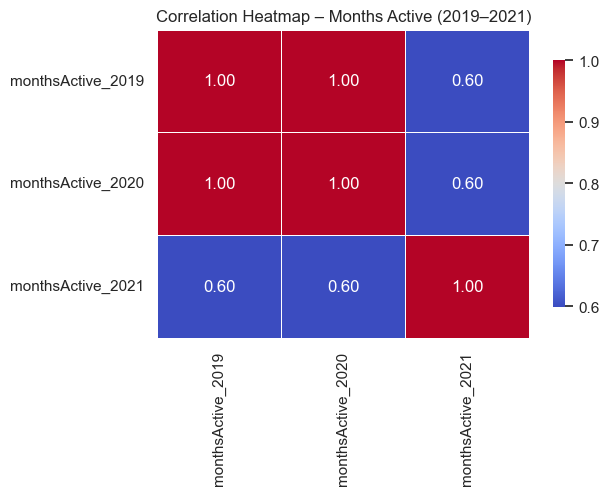

In [430]:
plt.figure(figsize=(6, 4))
corr_months = flights_agg[flights_vars["Months_Active"]].corr()
sns.heatmap(
    corr_months,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap – Months Active (2019–2021)")
plt.show()

<a class="anchor" id="3rd-bullet">

#### Seasonal Flights
    
</a>

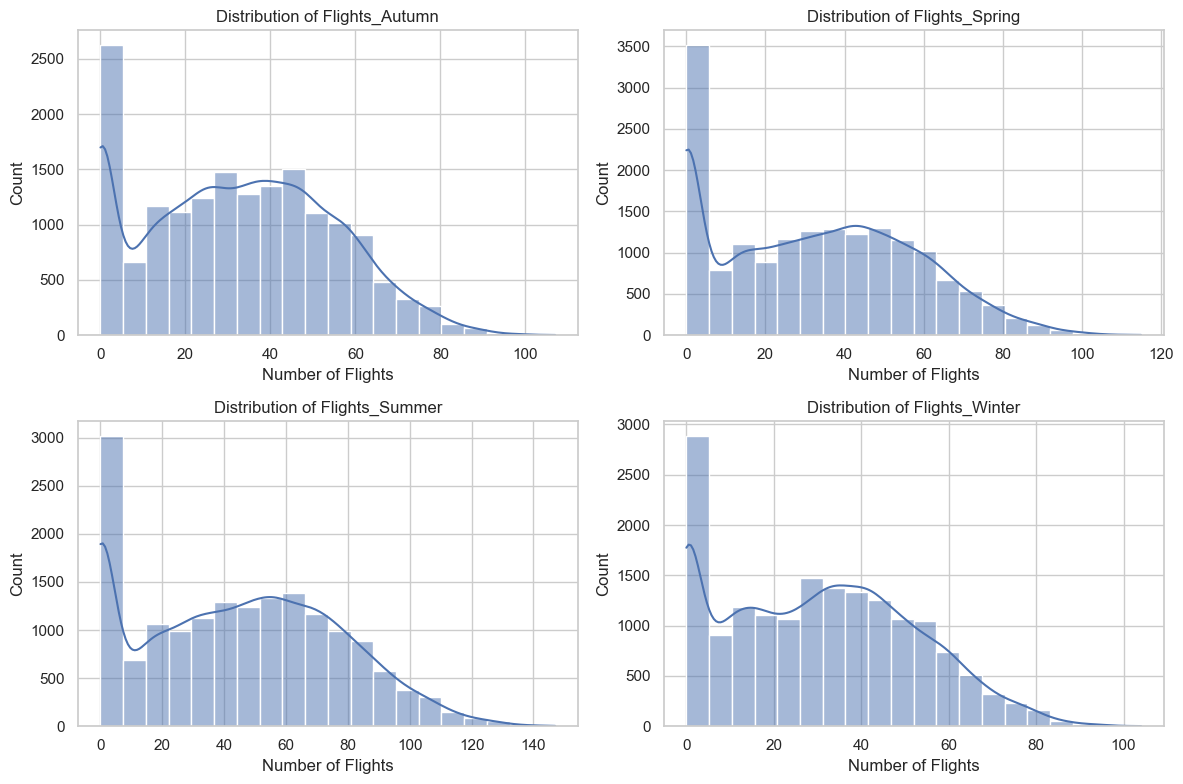

In [431]:
cols = flights_vars["Seasonal_Flights"]
n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, c in enumerate(cols):
    sns.histplot(flights_agg[c], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {c}")
    axes[i].set_xlabel("Number of Flights")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


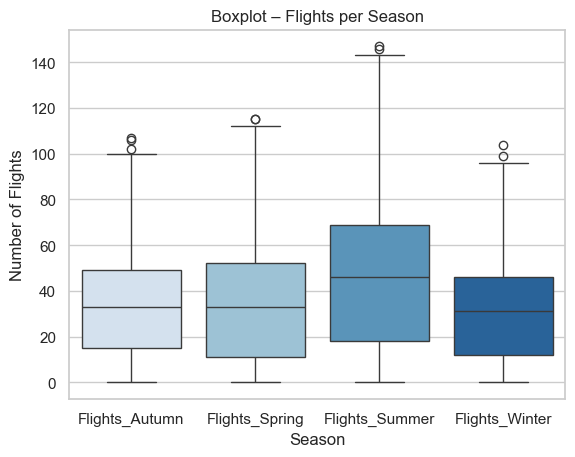

In [432]:
sns.boxplot(data=flights_agg[cols], palette="Blues")
plt.title("Boxplot – Flights per Season")
plt.xlabel("Season")
plt.ylabel("Number of Flights")
plt.show()

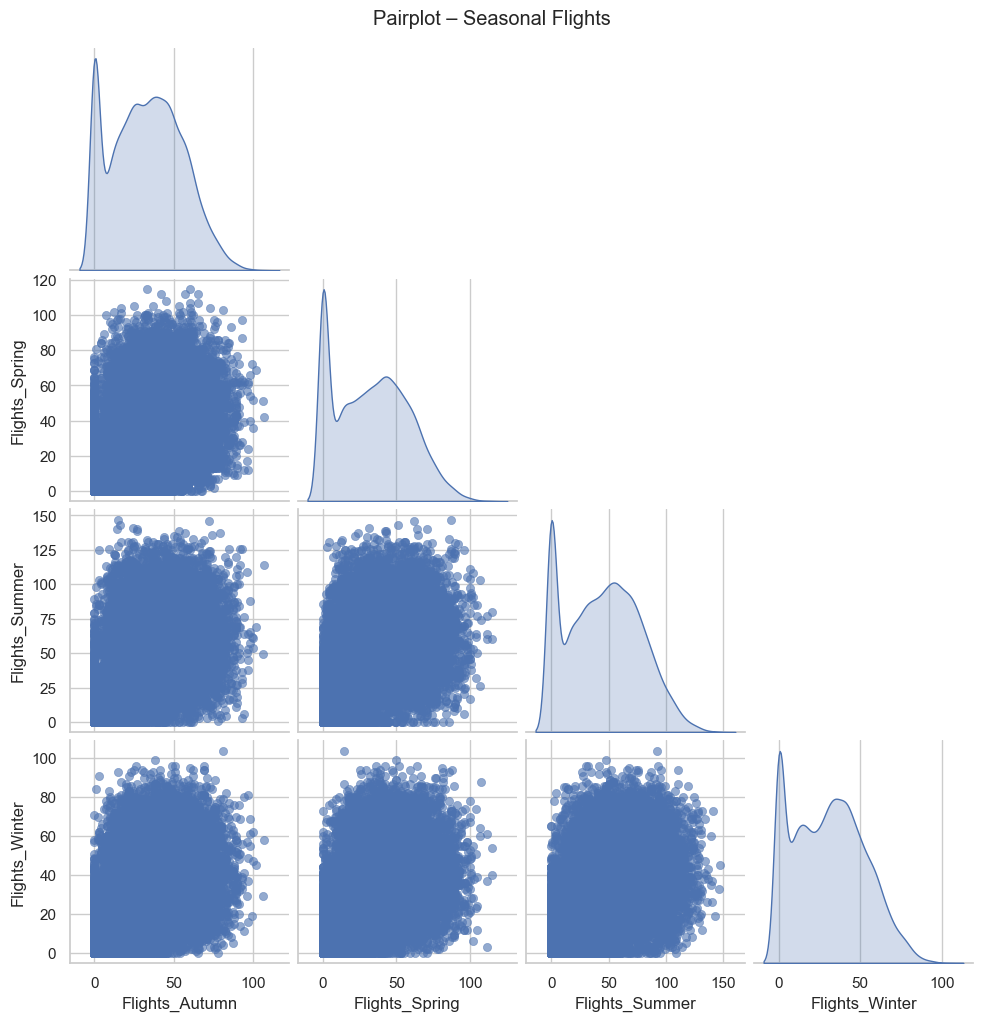

In [433]:
sns.pairplot(
    flights_agg[cols],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': None}
)
plt.suptitle("Pairplot – Seasonal Flights", y=1.02)
plt.show()


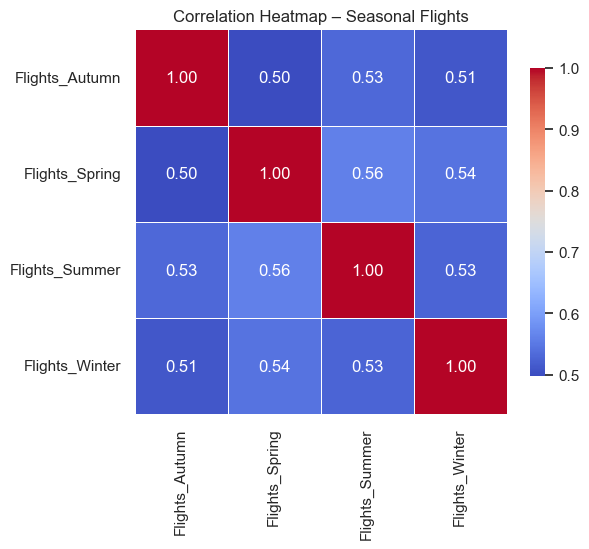

In [434]:
plt.figure(figsize=(6, 5))
corr_seasonal = flights_agg[cols].corr()
sns.heatmap(
    corr_seasonal,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap – Seasonal Flights")
plt.show()


<a class="anchor" id="3rd-bullet">

#### Peak Season and Peak Month
    
</a>

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\3741351385.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


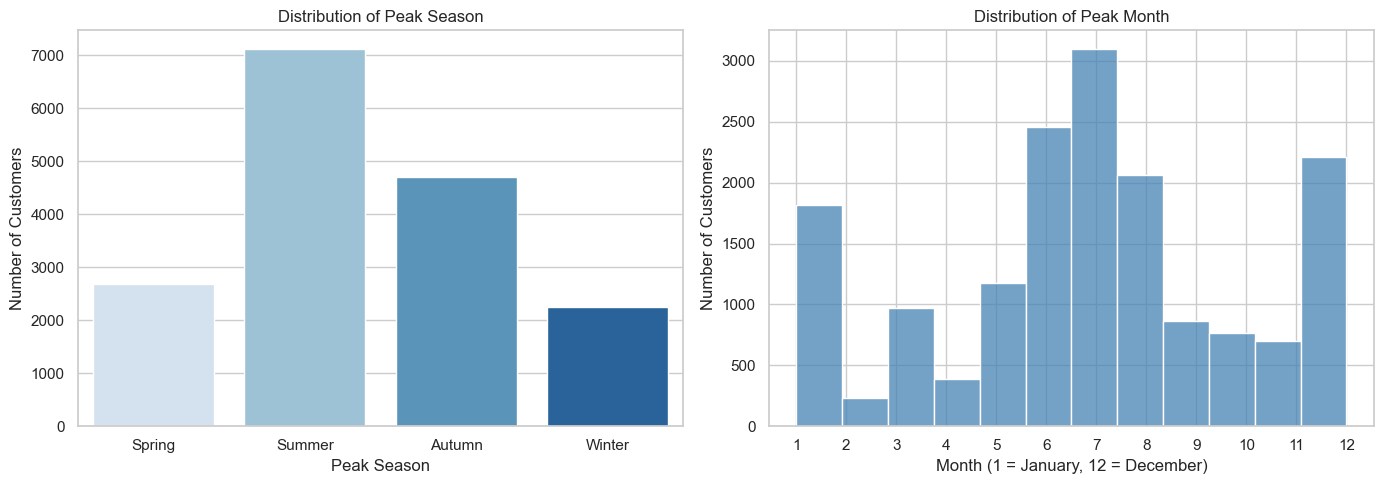

In [435]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Countplot: PeakSeason ---
sns.countplot(
    x='PeakSeason',
    data=flights_agg,
    palette='Blues',
    order=['Spring', 'Summer', 'Autumn', 'Winter'],
    ax=axes[0]
)
axes[0].set_title("Distribution of Peak Season")
axes[0].set_xlabel("Peak Season")
axes[0].set_ylabel("Number of Customers")

# --- Histplot: PeakMonth ---
sns.histplot(
    flights_agg['PeakMonth'],
    bins=12,
    kde=False,
    color='steelblue',
    ax=axes[1]
)
axes[1].set_title("Distribution of Peak Month")
axes[1].set_xlabel("Month (1 = January, 12 = December)")
axes[1].set_ylabel("Number of Customers")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\1670742151.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PeakSeason', y='PeakMonth', data=flights_agg, palette='Blues', order=['Spring', 'Summer', 'Autumn', 'Winter'])


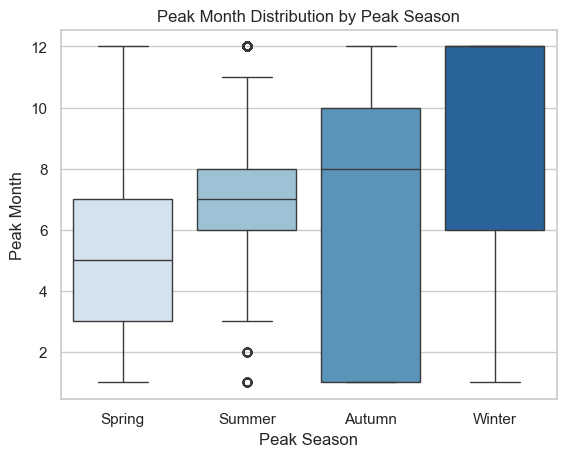

In [436]:
sns.boxplot(x='PeakSeason', y='PeakMonth', data=flights_agg, palette='Blues', order=['Spring', 'Summer', 'Autumn', 'Winter'])
plt.title("Peak Month Distribution by Peak Season")
plt.xlabel("Peak Season")
plt.ylabel("Peak Month")
plt.show()


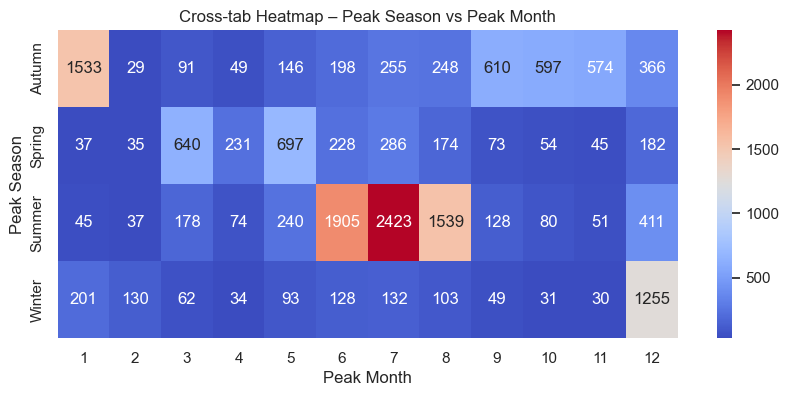

In [437]:
cross_tab = pd.crosstab(flights_agg['PeakSeason'], flights_agg['PeakMonth'])
plt.figure(figsize=(10, 4))
sns.heatmap(cross_tab, cmap='coolwarm', annot=True, fmt='d')
plt.title("Cross-tab Heatmap – Peak Season vs Peak Month")
plt.xlabel("Peak Month")
plt.ylabel("Peak Season")
plt.show()


<a class="anchor" id="3rd-bullet">

#### Binary Variables
    
</a>

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2900445747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Blues', ax=axes[i])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2900445747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Blues', ax=axes[i])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2900445747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=flights_agg[c], palette='Blues', ax=axes[i])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\2900445747.py:9

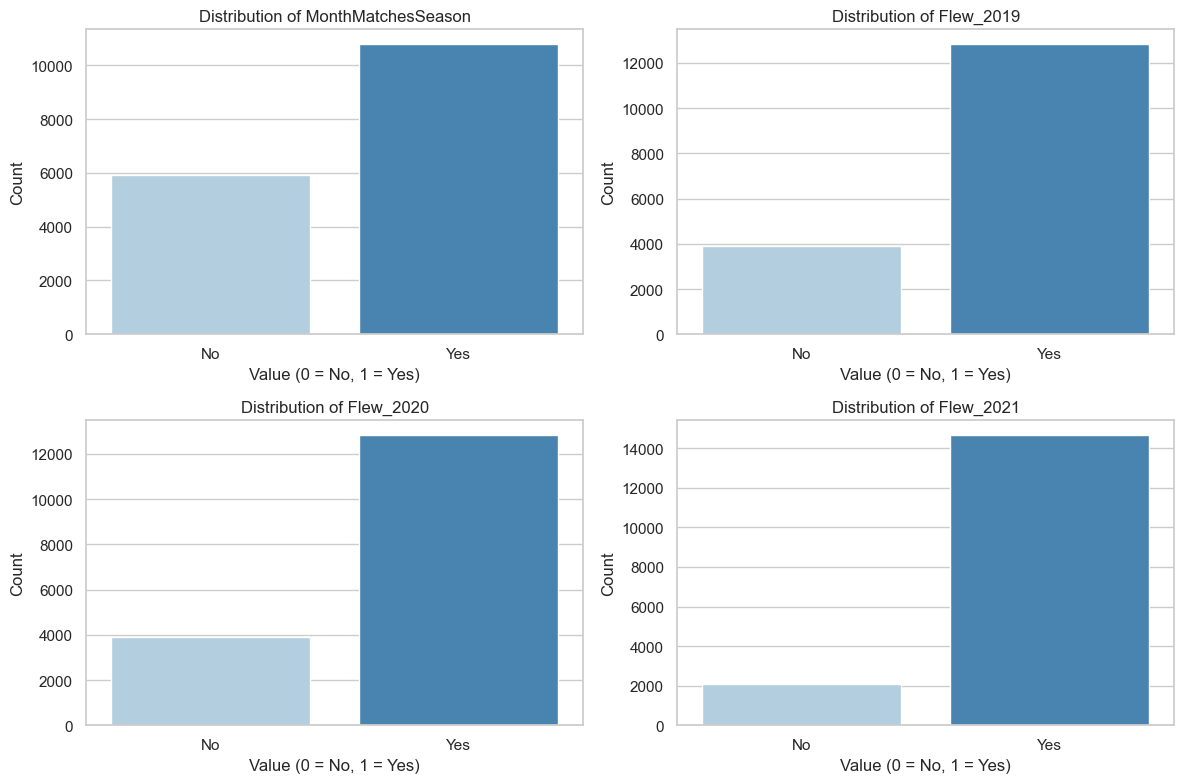

In [438]:
cols = flights_vars["Season_Match_Flew"]
n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, c in enumerate(cols):
    sns.countplot(x=flights_agg[c], palette='Blues', ax=axes[i])
    axes[i].set_title(f"Distribution of {c}")
    axes[i].set_xlabel("Value (0 = No, 1 = Yes)")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

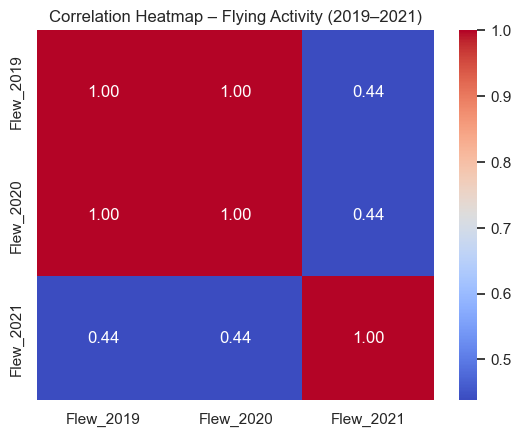

In [439]:
sns.heatmap(
    flights_agg[['Flew_2019','Flew_2020','Flew_2021']].corr(),
    annot=True, cmap='coolwarm', fmt=".2f"
)
plt.title("Correlation Heatmap – Flying Activity (2019–2021)")
plt.show()

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\607324527.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


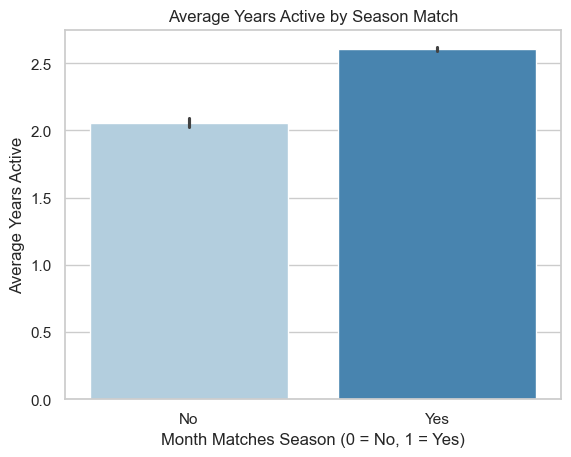

In [440]:
sns.barplot(
    data=flights_agg,
    x='MonthMatchesSeason',
    y='YearsActive',
    palette='Blues',
    estimator='mean'
)
plt.title("Average Years Active by Season Match")
plt.xlabel("Month Matches Season (0 = No, 1 = Yes)")
plt.ylabel("Average Years Active")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


<a class="anchor" id="3rd-bullet">

#### Years Active
    
</a>

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\976434992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='YearsActive', data=flights_agg, palette='Blues')


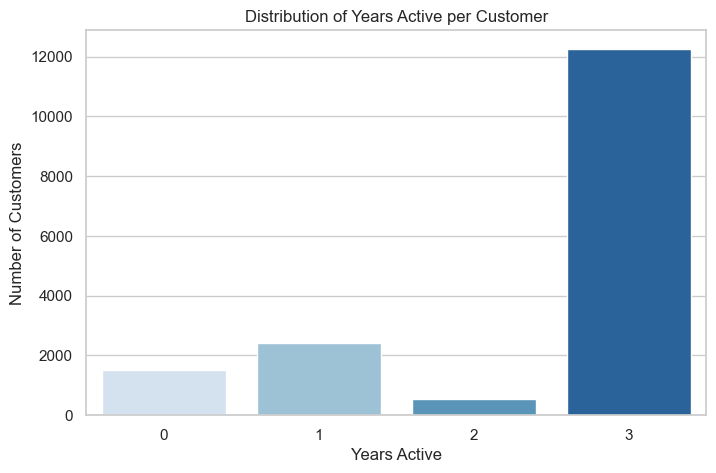

In [441]:
plt.figure(figsize=(8, 5))
sns.countplot(x='YearsActive', data=flights_agg, palette='Blues')
plt.title("Distribution of Years Active per Customer")
plt.xlabel("Years Active")
plt.ylabel("Number of Customers")
plt.show()


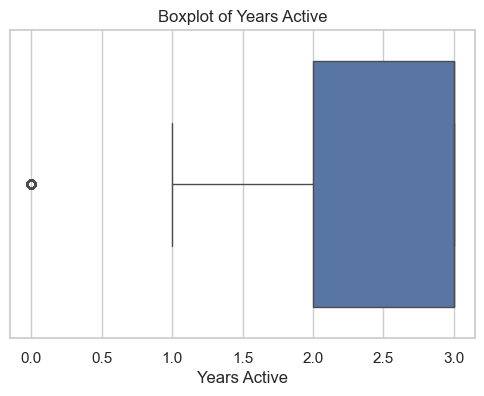

In [442]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=flights_agg['YearsActive'])
plt.title("Boxplot of Years Active")
plt.xlabel("Years Active")
plt.show()


<a class="anchor" id="3rd-bullet">

### 3.4.2. Multivariate Analysis
    
</a>

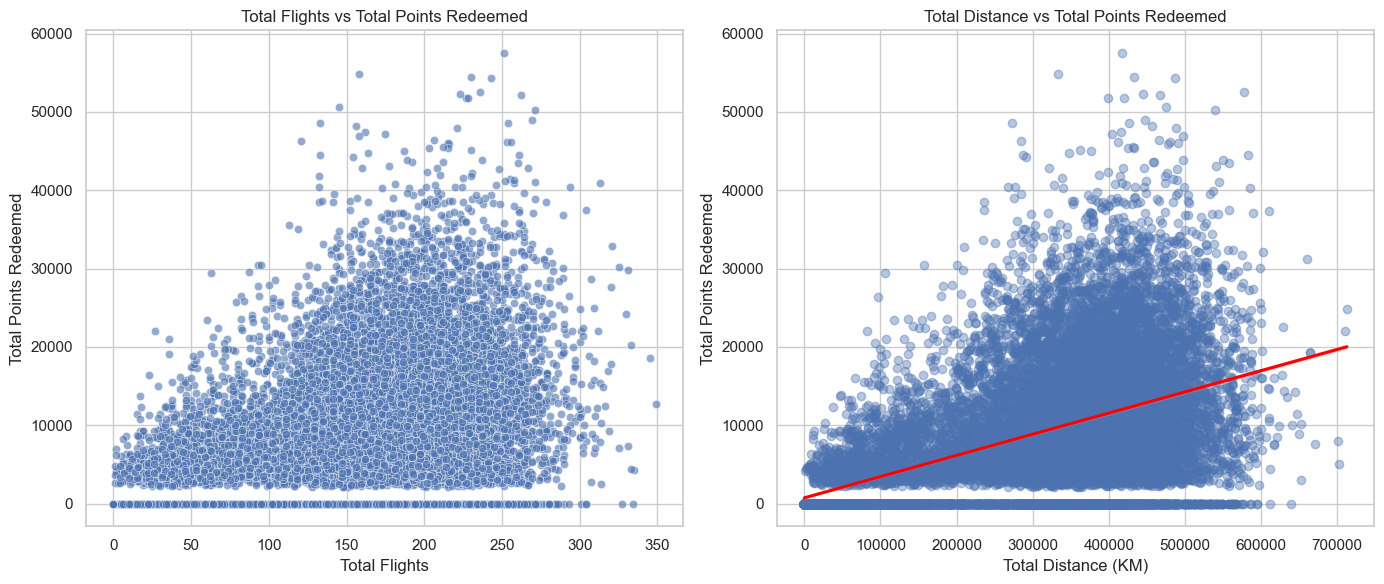

In [443]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Scatter: Total Flights vs Total Points Redeemed
sns.scatterplot(
    data=flights_agg,
    x='TotalFlights', 
    y='TotalPointsRedeemed',
    alpha=0.6, ax=axes[0]
)
axes[0].set_title('Total Flights vs Total Points Redeemed')
axes[0].set_xlabel('Total Flights')
axes[0].set_ylabel('Total Points Redeemed')

# Regression: Total Distance vs Total Points Redeemed
sns.regplot(
    data=flights_agg,
    x='TotalDistanceKM',
    y='TotalPointsRedeemed',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title('Total Distance vs Total Points Redeemed')
axes[1].set_xlabel('Total Distance (KM)')
axes[1].set_ylabel('Total Points Redeemed')

plt.tight_layout()
plt.show()

C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\4190924840.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


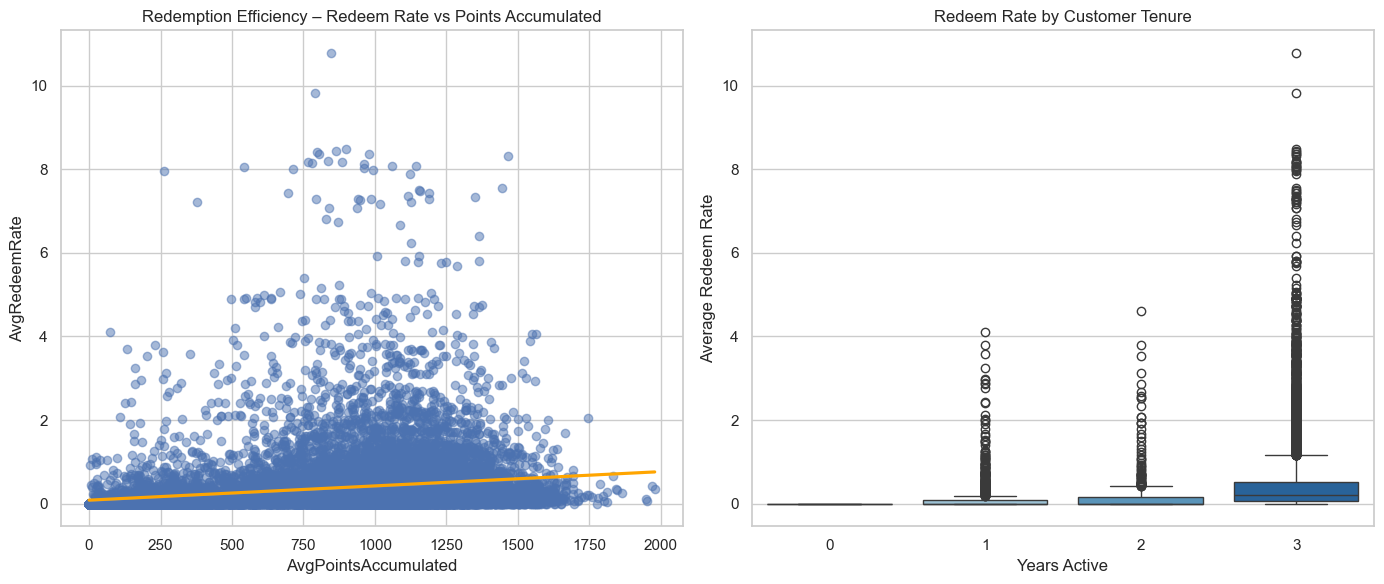

In [444]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Regression: Redeem Rate vs Avg Points Accumulated
sns.regplot(
    data=flights_agg,
    x='AvgPointsAccumulated', 
    y='AvgRedeemRate',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'orange'},
    ax=axes[0]
)
axes[0].set_title('Redemption Efficiency – Redeem Rate vs Points Accumulated')

# Boxplot: Redeem Rate by Years Active
sns.boxplot(
    data=flights_agg,
    x='YearsActive',
    y='AvgRedeemRate',
    palette='Blues',
    ax=axes[1]
)
axes[1].set_title('Redeem Rate by Customer Tenure')
axes[1].set_xlabel('Years Active')
axes[1].set_ylabel('Average Redeem Rate')

plt.tight_layout()
plt.show()


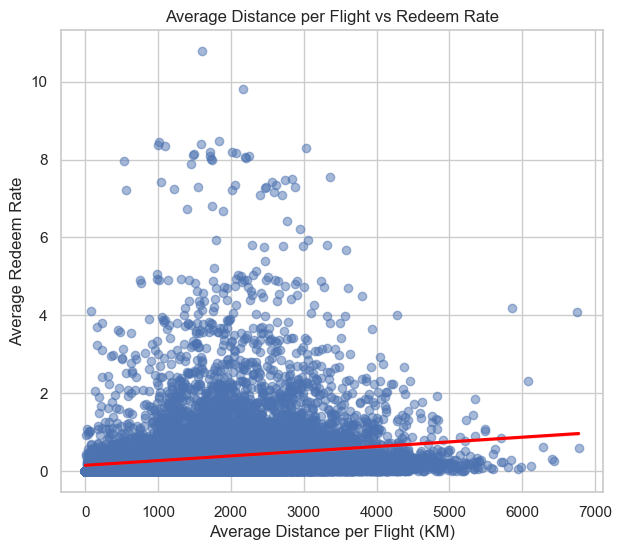

In [445]:
plt.figure(figsize=(7,6))
sns.regplot(
    data=flights_agg,
    x='AvgDistancePerFlight',
    y='AvgRedeemRate',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title('Average Distance per Flight vs Redeem Rate')
plt.xlabel('Average Distance per Flight (KM)')
plt.ylabel('Average Redeem Rate')
plt.show()


C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\3154346420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights_agg, x='YearsActive', y='TotalFlights', palette='Blues', ax=axes[0])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\3154346420.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights_agg, x='YearsActive', y='TotalPointsAccumulated', palette='Blues', ax=axes[1])
C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\3154346420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights_agg, x='YearsActive', y=

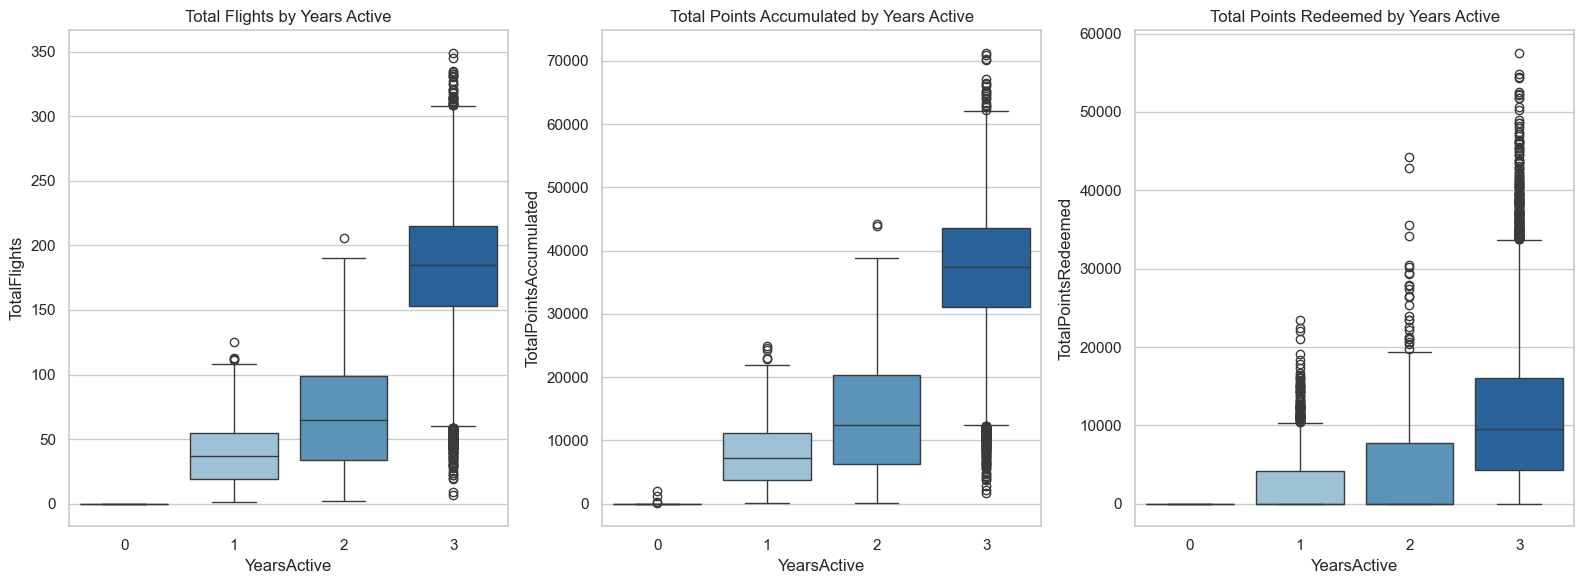

In [446]:
fig, axes = plt.subplots(1, 3, figsize=(16,6))

sns.boxplot(data=flights_agg, x='YearsActive', y='TotalFlights', palette='Blues', ax=axes[0])
axes[0].set_title('Total Flights by Years Active')

sns.boxplot(data=flights_agg, x='YearsActive', y='TotalPointsAccumulated', palette='Blues', ax=axes[1])
axes[1].set_title('Total Points Accumulated by Years Active')

sns.boxplot(data=flights_agg, x='YearsActive', y='TotalPointsRedeemed', palette='Blues', ax=axes[2])
axes[2].set_title('Total Points Redeemed by Years Active')

plt.tight_layout()
plt.show()


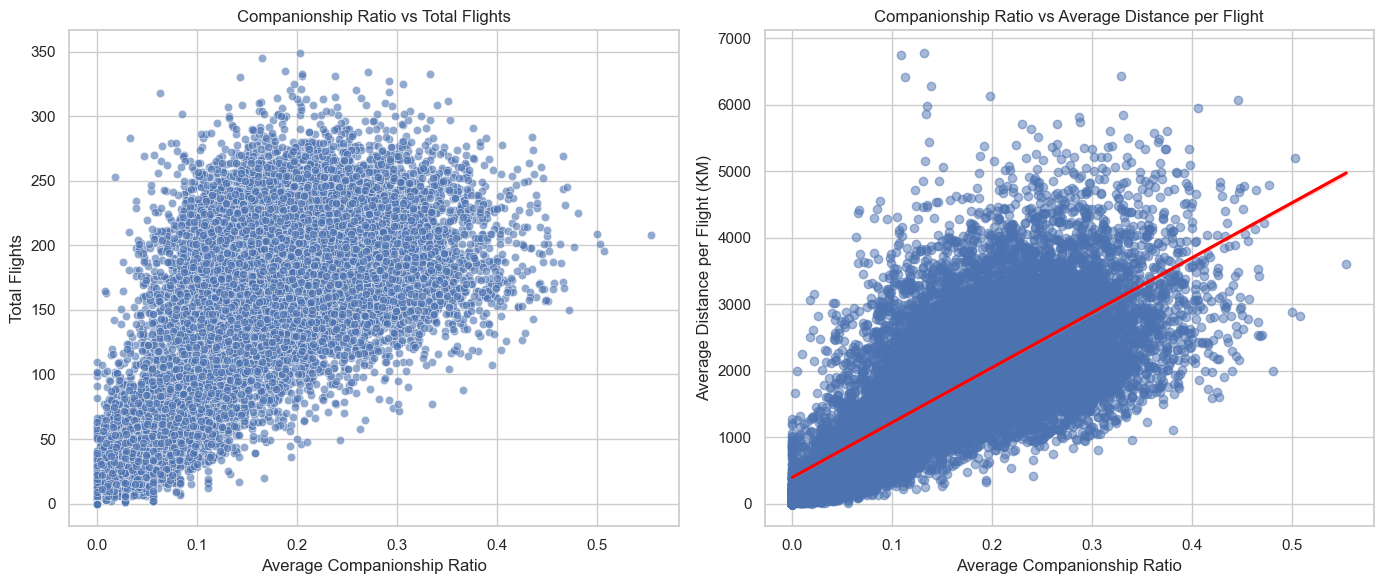

In [447]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Scatter: Companionship Ratio vs Total Flights
sns.scatterplot(
    data=flights_agg,
    x='AvgCompanionshipRatio',
    y='TotalFlights',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Companionship Ratio vs Total Flights')
axes[0].set_xlabel('Average Companionship Ratio')
axes[0].set_ylabel('Total Flights')

# Scatter: Companionship Ratio vs Avg Distance per Flight
sns.regplot(
    data=flights_agg,
    x='AvgCompanionshipRatio',
    y='AvgDistancePerFlight',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title('Companionship Ratio vs Average Distance per Flight')
axes[1].set_xlabel('Average Companionship Ratio')
axes[1].set_ylabel('Average Distance per Flight (KM)')

plt.tight_layout()
plt.show()


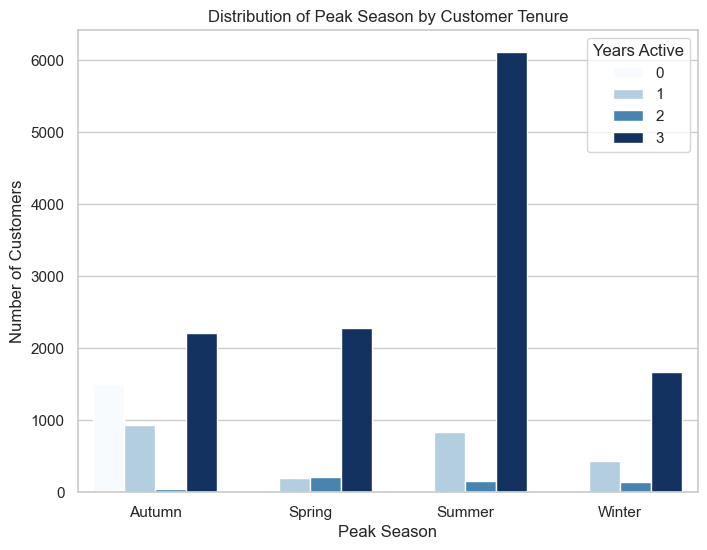

In [448]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=flights_agg,
    x='PeakSeason',
    hue='YearsActive',
    palette='Blues'
)
plt.title('Distribution of Peak Season by Customer Tenure')
plt.xlabel('Peak Season')
plt.ylabel('Number of Customers')
plt.legend(title='Years Active')
plt.show()


C:\Users\ritan\AppData\Local\Temp\ipykernel_6752\1780030418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


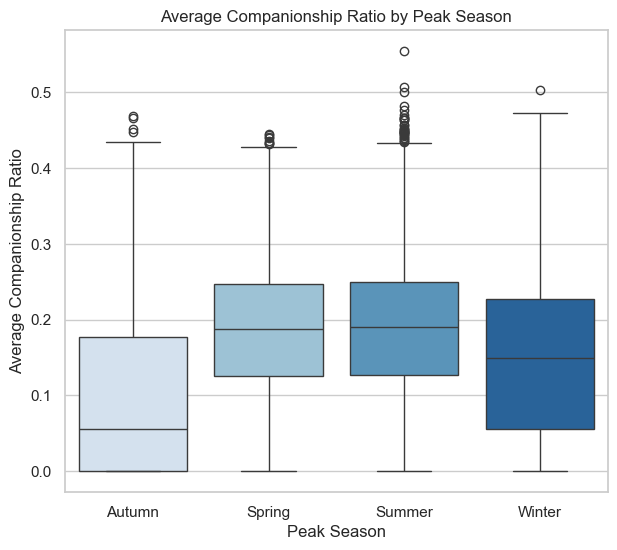

In [449]:
plt.figure(figsize=(7,6))
sns.boxplot(
    data=flights_agg,
    x='PeakSeason',
    y='AvgCompanionshipRatio',
    palette='Blues'
)
plt.title('Average Companionship Ratio by Peak Season')
plt.xlabel('Peak Season')
plt.ylabel('Average Companionship Ratio')
plt.show()


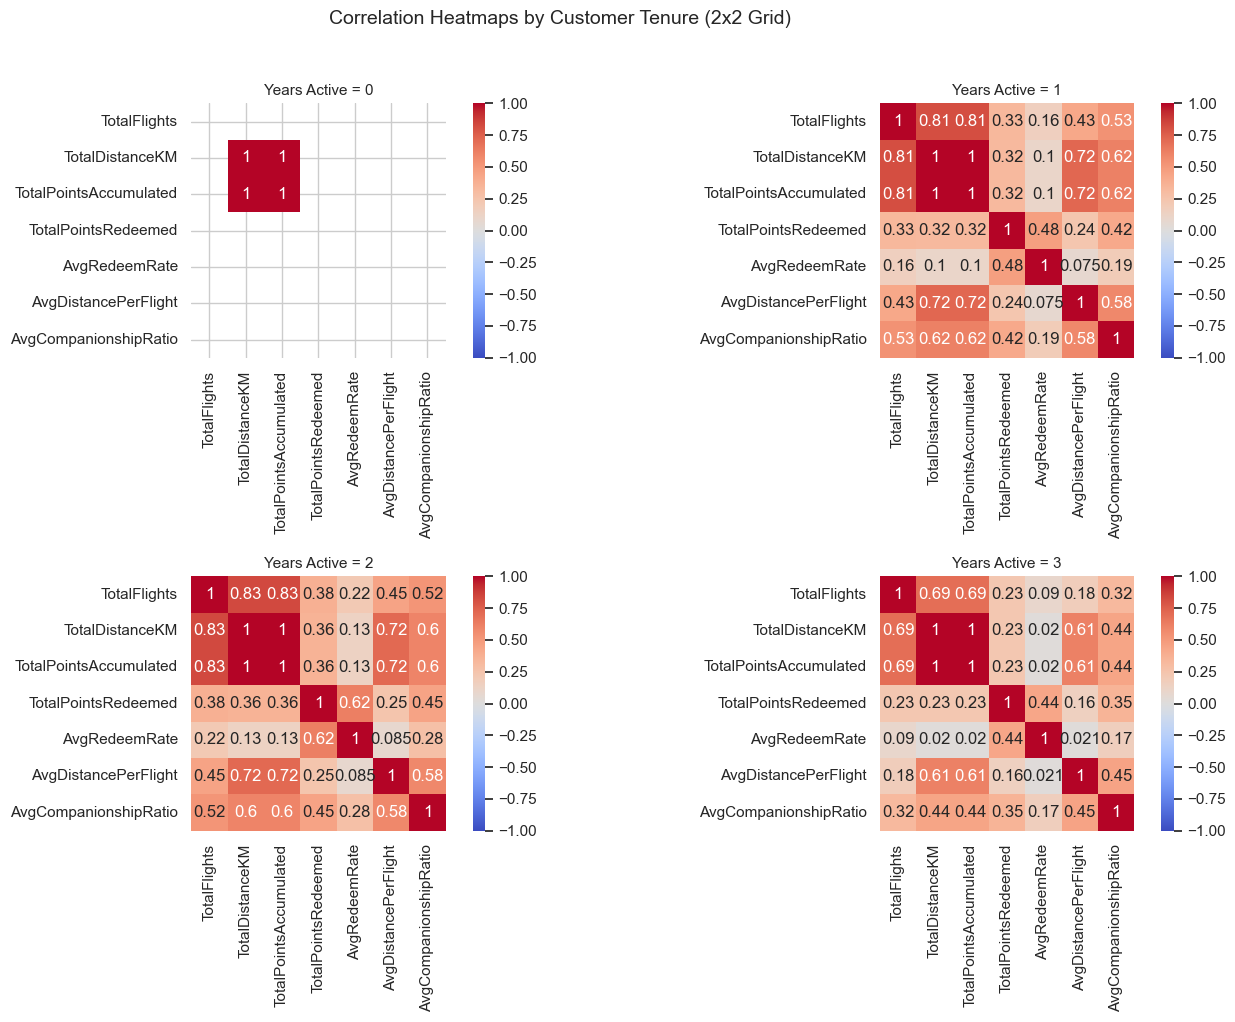

In [450]:
# Displaying heatmaps in a 2x2 grid for better comparison

tenure_groups = sorted(flights_agg['YearsActive'].unique())
n_groups = len(tenure_groups)

# Calculate number of rows and columns (2x2 layout)
n_cols = 2
n_rows = math.ceil(n_groups / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()  # Flatten to index easily

for i, yr in enumerate(tenure_groups):
    subset = flights_agg[flights_agg['YearsActive'] == yr]
    corr = subset[
        ['TotalFlights','TotalDistanceKM','TotalPointsAccumulated','TotalPointsRedeemed',
         'AvgRedeemRate','AvgDistancePerFlight','AvgCompanionshipRatio']
    ].corr()
    
    sns.heatmap(
        corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[i]
    )
    axes[i].set_title(f'Years Active = {yr}', fontsize=11)

# Hide any unused subplot (if not perfectly divisible by 2)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Correlation Heatmaps by Customer Tenure (2x2 Grid)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



<a class="anchor" id="3rd-bullet">

### 3.4.3. Heatmap between all numeric variables
    
</a>

In [455]:
# Select numeric columns with dtype float64 or int64 (excluding encoded bool/int8)
num_vars = flights_agg.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove the identifier if it exists
if 'Loyalty#' in num_vars:
    num_vars.remove('Loyalty#')

print("Numeric variables for correlation heatmap:")
print(num_vars)


Numeric variables for correlation heatmap:
['TotalFlights', 'AvgFlightsPerMonth', 'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions', 'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated', 'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed', 'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate', 'AvgDistancePerFlight', 'AvgCompanionshipRatio', 'monthsActive_2019', 'monthsActive_2020', 'monthsActive_2021', 'Flights_Autumn', 'Flights_Spring', 'Flights_Summer', 'Flights_Winter', 'PeakMonth', 'YearsActive']


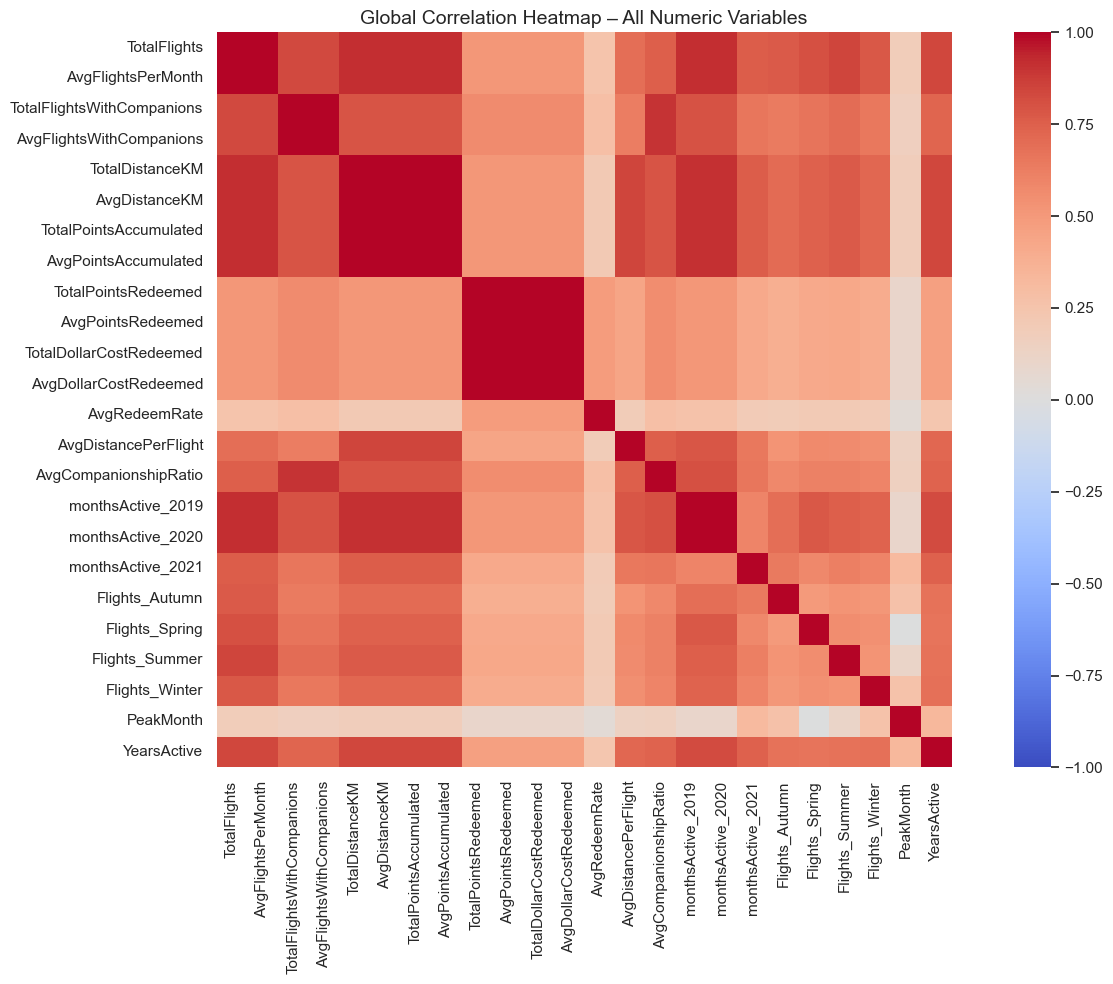

In [456]:
plt.figure(figsize=(14, 10))
corr = flights_agg[num_vars].corr()

sns.heatmap(
    corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, square=True
)
plt.title('Global Correlation Heatmap – All Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

### 3.5.3 Correlation Matrix (Numerical Variables)

We can see that the correlation matrix is very big .Thus the interpretation is difficult . We need first to focus on strong correlations

In [458]:
# --- Identify strong correlations among selected numerical variables ---

# Compute correlation matrix only for selected numeric variables
corr = flights_agg[num_vars].corr()

# Transform correlation matrix into list of variable pairs
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove duplicates and self-correlations
corr_pairs = corr_pairs[corr_pairs['Variable 1'] < corr_pairs['Variable 2']]

# Keep only strong correlations (|corr| ≥ 0.5)
strong_corr = corr_pairs[abs(corr_pairs['Correlation']) >= 0.5] \
                .sort_values('Correlation', ascending=False)

print("Strong correlations (|r| ≥ 0.5) among selected numeric variables:")
display(strong_corr.head(20))


Strong correlations (|r| ≥ 0.5) among selected numeric variables:


,Variable 1,Variable 2,Correlation
174,AvgPointsAccumulated,TotalPointsAccumulated,1.000000
74,AvgFlightsWithCompanions,TotalFlightsWithCompanions,1.000000
274,AvgDollarCostRedeemed,TotalDollarCostRedeemed,1.000000
376,monthsActive_2019,monthsActive_2020,1.000000
24,AvgFlightsPerMonth,TotalFlights,1.000000
124,AvgDistanceKM,TotalDistanceKM,1.000000
224,AvgPointsRedeemed,TotalPointsRedeemed,1.000000
102,TotalDistanceKM,TotalPointsAccumulated,1.000000
172,AvgPointsAccumulated,TotalDistanceKM,1.000000
126,AvgDistanceKM,TotalPointsAccumulated,1.000000


<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 4. Customers and Flights Datasets Merged
    

    
</div>

<a class="anchor" id="3rd-bullet">

### 4.1. Merging the two datasets
    
</a>

### Check in both datasets

In [459]:
print("Customer dataset shape:", customers.shape)
print("Flight dataset shape:", flights_agg.shape)

Customer dataset shape: (16757, 27)
Flight dataset shape: (16737, 30)


In [460]:
print("Customer key unique:", customers['Loyalty#'].is_unique)
print("Flight key unique:", flights_agg['Loyalty#'].is_unique)

Customer key unique: True
Flight key unique: True


In [461]:
merged_df = pd.merge(customers, flights_agg, on='Loyalty#', how='left')
merged_df


,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,IncomeGroup,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity,PostalArea,PostalAreaActivity,LoyaltyScore,ValueToIncomeRatio,MarriedHighIncome,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,High,Married,2019,3,5410,M2Z,257,3,0.054730,1,191.0,5.305556,56.0,1.555556,507054.9,14084.858333,50699.39,1408.316389,13517.9,375.497222,134.6,3.738889,0.230105,4877.435984,0.311940,9.0,9.0,11.0,40.0,47.0,85.0,19.0,Summer,5.0,0.0,1.0,1.0,1.0,3.0
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,Low,Not Married,2019,2,995,T3G,226,3,3839.610000,0,279.0,7.750000,32.0,0.888889,426827.4,11856.316667,42672.54,1185.348333,22457.8,623.827778,221.4,6.150000,1.212583,1017.891093,0.079320,8.0,8.0,10.0,59.0,84.0,84.0,52.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,Low,Not Married,2017,2,4379,V6E,1447,3,3839.750000,0,120.0,3.333333,40.0,1.111111,238376.1,6621.558333,23832.41,662.011389,5479.6,152.211111,53.2,1.477778,0.499992,1969.114015,0.195127,8.0,8.0,1.0,30.0,38.0,21.0,31.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,Low,Not Married,2016,2,5410,P1W,275,3,3839.750000,0,196.0,5.444444,58.0,1.611111,386029.3,10723.036111,38595.63,1072.100833,16331.5,453.652778,162.2,4.505556,0.878287,2493.037908,0.227100,10.0,10.0,7.0,43.0,68.0,37.0,48.0,Spring,6.0,0.0,1.0,1.0,1.0,3.0
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,High,Married,2017,3,3280,J8Y,358,3,0.039279,1,171.0,4.750000,63.0,1.750000,369242.6,10256.738889,36916.56,1025.460000,0.0,0.000000,0.0,0.000000,0.000000,3355.810496,0.303664,7.0,7.0,9.0,32.0,28.0,74.0,37.0,Summer,8.0,1.0,1.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16752,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,34148.0,Single,Star,2019-02-27,2019-02-27,5780.18,Standard,1,Medium,Not Married,2019,3,3280,Y0C,1,3,0.169264,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16753,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,34148.0,Married,Star,2017-09-20,2017-09-20,5780.18,Standard,1,Medium,Married,2017,3,995,L3S,1,3,0.169264,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16754,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,34148.0,Married,Star,2020-11-28,2020-11-28,5780.18,Standard,1,Medium,Married,2020,3,641,G2S,1,3,0.169264,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16755,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,34148.

In [468]:
merged_df.shape

(16757, 56)

In [472]:
merged_df.isna().sum()

Loyalty#                          0
Province or State                 0
City                              0
Latitude                          0
Longitude                         0
Postal code                       0
Gender                            0
Education                         0
Location Code                     0
Income                            0
Marital Status                    0
LoyaltyStatus                     0
EnrollmentDateOpening             0
CancellationDate              14471
Customer Lifetime Value           0
EnrollmentType                    0
Churn                             0
IncomeGroup                       0
MaritalGroup                      0
EnrollmentYear                    0
EducationLevelCode                0
ProvinceActivity                  0
PostalArea                        0
PostalAreaActivity                0
LoyaltyScore                      0
ValueToIncomeRatio                0
MarriedHighIncome                 0
TotalFlights                

In [473]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16757 entries, 0 to 16756
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Loyalty#                    16757 non-null  int64         
 1   Province or State           16757 non-null  object        
 2   City                        16757 non-null  object        
 3   Latitude                    16757 non-null  float64       
 4   Longitude                   16757 non-null  float64       
 5   Postal code                 16757 non-null  object        
 6   Gender                      16757 non-null  object        
 7   Education                   16757 non-null  object        
 8   Location Code               16757 non-null  object        
 9   Income                      16757 non-null  float64       
 10  Marital Status              16757 non-null  object        
 11  LoyaltyStatus               16757 non-null  object    

In [474]:
merged_df.head()

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Churn,IncomeGroup,MaritalGroup,EnrollmentYear,EducationLevelCode,ProvinceActivity,PostalArea,PostalAreaActivity,LoyaltyScore,ValueToIncomeRatio,MarriedHighIncome,TotalFlights,AvgFlightsPerMonth,TotalFlightsWithCompanions,AvgFlightsWithCompanions,TotalDistanceKM,AvgDistanceKM,TotalPointsAccumulated,AvgPointsAccumulated,TotalPointsRedeemed,AvgPointsRedeemed,TotalDollarCostRedeemed,AvgDollarCostRedeemed,AvgRedeemRate,AvgDistancePerFlight,AvgCompanionshipRatio,monthsActive_2019,monthsActive_2020,monthsActive_2021,Flights_Autumn,Flights_Spring,Flights_Summer,Flights_Winter,PeakSeason,PeakMonth,MonthMatchesSeason,Flew_2019,Flew_2020,Flew_2021,YearsActive
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,High,Married,2019,3,5410,M2Z,257,3,0.054730,1,191.0,5.305556,56.0,1.555556,507054.9,14084.858333,50699.39,1408.316389,13517.9,375.497222,134.6,3.738889,0.230105,4877.435984,0.311940,9.0,9.0,11.0,40.0,47.0,85.0,19.0,Summer,5.0,0.0,1.0,1.0,1.0,3.0
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,Low,Not Married,2019,2,995,T3G,226,3,3839.610000,0,279.0,7.750000,32.0,0.888889,426827.4,11856.316667,42672.54,1185.348333,22457.8,623.827778,221.4,6.150000,1.212583,1017.891093,0.079320,8.0,8.0,10.0,59.0,84.0,84.0,52.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,Low,Not Married,2017,2,4379,V6E,1447,3,3839.750000,0,120.0,3.333333,40.0,1.111111,238376.1,6621.558333,23832.41,662.011389,5479.6,152.211111,53.2,1.477778,0.499992,1969.114015,0.195127,8.0,8.0,1.0,30.0,38.0,21.0,31.0,Spring,5.0,1.0,1.0,1.0,1.0,3.0
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,Low,Not Married,2016,2,5410,P1W,275,3,3839.750000,0,196.0,5.444444,58.0,1.611111,386029.3,10723.036111,38595.63,1072.100833,16331.5,453.652778,162.2,4.505556,0.878287,2493.037908,0.227100,10.0,10.0,7.0,43.0,68.0,37.0,48.0,Spring,6.0,0.0,1.0,1.0,1.0,3.0
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,High,Married,2017,3,3280,J8Y,358,3,0.039279,1,171.0,4.750000,63.0,1.750000,369242.6,10256.738889,36916.56,1025.460000,0.0,0.000000,0.0,0.000000,0.000000,3355.810496,0.303664,7.0,7.0,9.0,32.0,28.0,74.0,37.0,Summer,8.0,1.0,1.0,1.0,1.0,3.0


In [476]:
merged_df.columns

Index(['Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType',
       'Churn', 'IncomeGroup', 'MaritalGroup', 'EnrollmentYear',
       'EducationLevelCode', 'ProvinceActivity', 'PostalArea',
       'PostalAreaActivity', 'LoyaltyScore', 'ValueToIncomeRatio',
       'MarriedHighIncome', 'TotalFlights', 'AvgFlightsPerMonth',
       'TotalFlightsWithCompanions', 'AvgFlightsWithCompanions',
       'TotalDistanceKM', 'AvgDistanceKM', 'TotalPointsAccumulated',
       'AvgPointsAccumulated', 'TotalPointsRedeemed', 'AvgPointsRedeemed',
       'TotalDollarCostRedeemed', 'AvgDollarCostRedeemed', 'AvgRedeemRate',
       'AvgDistancePerFlight', 'AvgCompanionshipRatio', 'monthsActive_2019',
       'monthsActive_2020', 'monthsActive_2021', 'Flights_Autumn',
       'Flights_Spring', '

In [477]:
merged_df.dtypes

Loyalty#                               int64
Province or State                     object
City                                  object
Latitude                             float64
Longitude                            float64
Postal code                           object
Gender                                object
Education                             object
Location Code                         object
Income                               float64
Marital Status                        object
LoyaltyStatus                         object
EnrollmentDateOpening         datetime64[ns]
CancellationDate              datetime64[ns]
Customer Lifetime Value              float64
EnrollmentType                        object
Churn                               category
IncomeGroup                         category
MaritalGroup                          object
EnrollmentYear                         int32
EducationLevelCode                     int64
ProvinceActivity                       int64
PostalArea

<a class="anchor" id="3rd-bullet">

### 4.2. Corretaltion Matrix/ Heatmap between all numeric variables
    
</a>

Number of numeric variables: 37


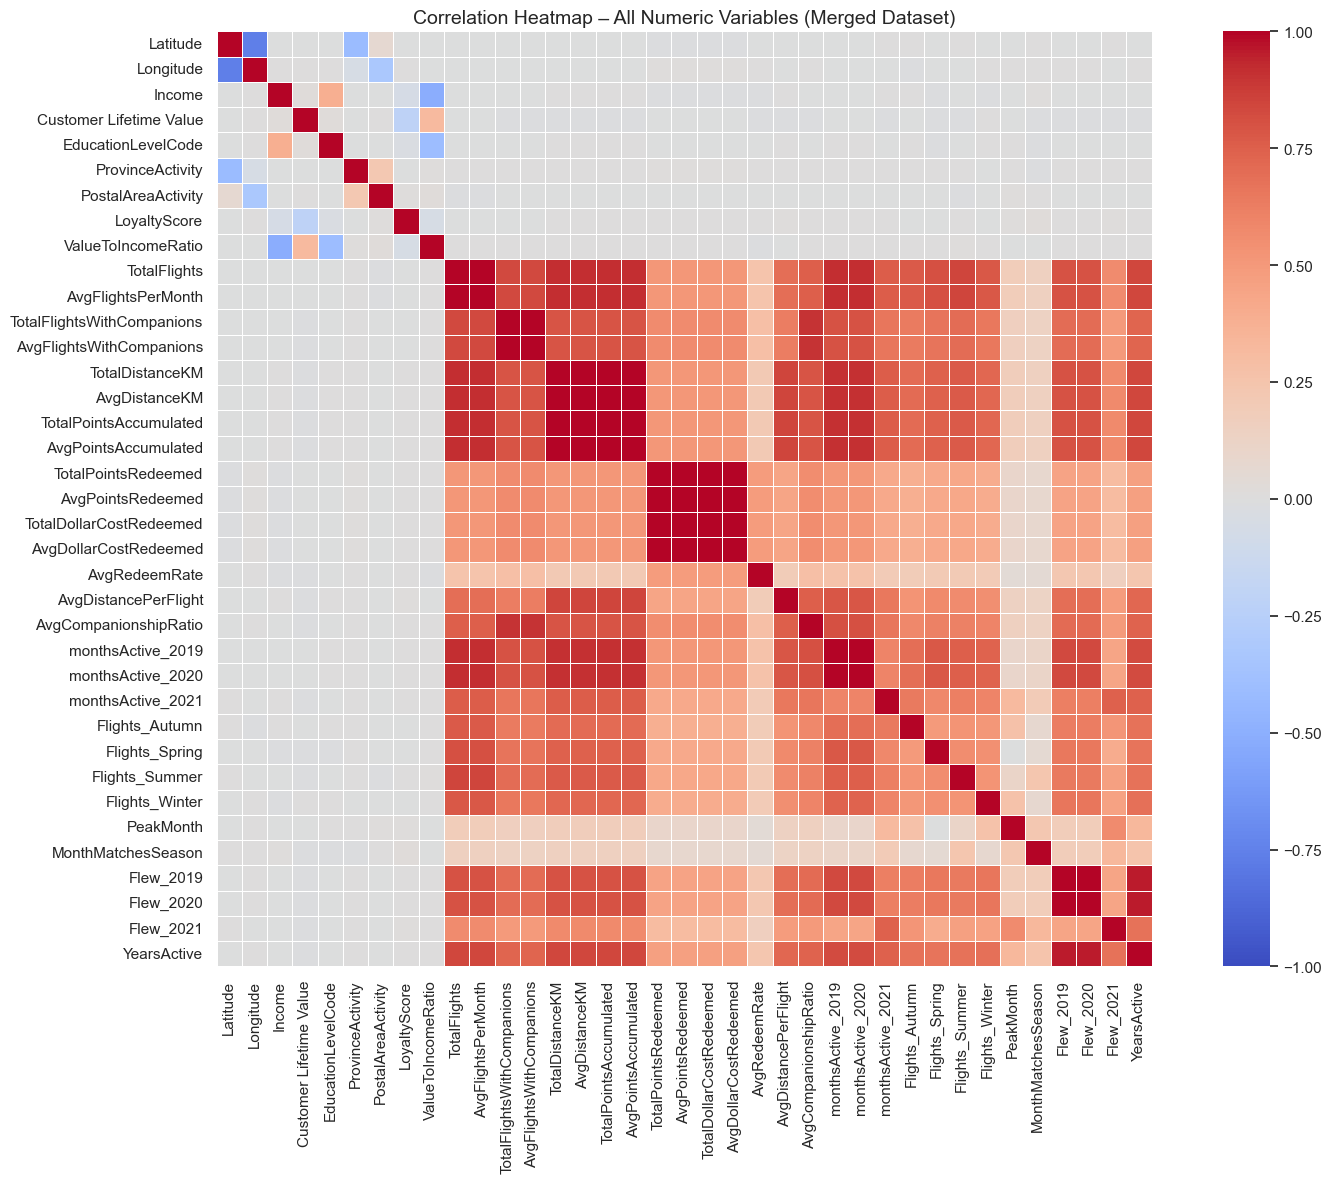

In [478]:
# Select only numeric columns (floats and ints)
num_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove the identifier if it exists
if 'Loyalty#' in num_cols:
    num_cols.remove('Loyalty#')

# Compute correlation matrix
corr_matrix = merged_df[num_cols].corr()

# Display shape and number of variables
print(f"Number of numeric variables: {len(num_cols)}")

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap – All Numeric Variables (Merged Dataset)', fontsize=14)
plt.tight_layout()
plt.show()

<a class="anchor" id="3rd-bullet">

#### Filter Strong Correlations

</a>

<Axes: >

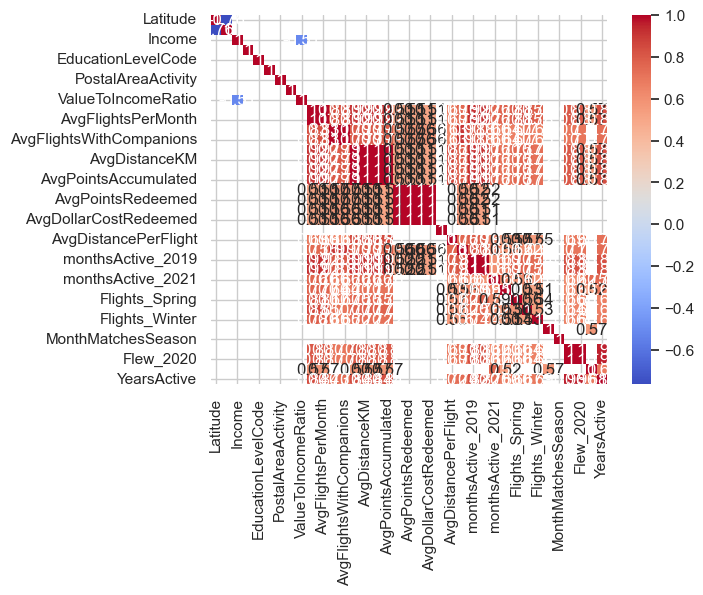

In [479]:
strong_corr = corr_matrix[(corr_matrix >= 0.5) | (corr_matrix <= -0.5)]
sns.heatmap(strong_corr, cmap='coolwarm', annot=True)